# Эксперименты с текстовыми признаками краудфандинговых проектов

Ноутбук извлекает текстовые и численные признаки из описаний проектов Planeta.ru и прогоняет эконометрические + ML-модели с целевыми переменными `is_successful` (бинарная), `funding_bucket` (3 класса), `log_funding_ratio` (непрерывная) и two-part моделью.


## 1. Импорты

In [1]:
import os
import re
import html
import warnings
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.regression.quantile_regression import QuantReg
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split as tts,
    StratifiedKFold,
    LeaveOneOut,
    cross_val_predict,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
)

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

try:
    import pymorphy3 as _pymorphy
except ImportError:
    import pymorphy2 as _pymorphy

morph = _pymorphy.MorphAnalyzer()

import nltk

for pkg in ("punkt", "punkt_tab"):
    try:
        nltk.data.find(f"tokenizers/{pkg}")
    except LookupError:
        nltk.download(pkg, quiet=True)



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Конфигурация

Все параметры, которые обычно правят — в одном месте.
- `INPUT_FILE` — уже очищенный файл со всеми исходными колонками.
- `TEXT_COL` — основная текстовая колонка с описанием проекта.

In [2]:
# ───── пути и входные данные ─────
INPUT_FILE = "projects_planeta_cleaned.xlsx"
TEXT_COL = "description.text"
TARGET_COL = "is_successful"
RANDOM_STATE = 42

# ───── RuBERT sentiment ─────
RUBERT_MODEL = "blanchefort/rubert-base-cased-sentiment"
RUBERT_MAX_SENTS = 200
RUBERT_BATCH = 16
RUBERT_MAX_LEN = 512

# ───── визуализации ─────
FIG_DIR = "figures_texts_experiments"
os.makedirs(FIG_DIR, exist_ok=True)

# ───── ML ─────
CV_FOLDS = 5
TEST_THRESHOLD = 0.5

## 3. Словари для лексических признаков

Все списки — в нормальной форме (лемматизатор приведёт текст к этому виду). Исключение — местоимения `WE_WORDS` / `I_WORDS`: ищем все словоформы напрямую.


In [3]:
SOCIAL_WORDS = {
    "команда", "сообщество", "группа", "коллектив", "союз", "объединение",
    "ассоциация", "организация", "клуб", "движение",
    "друг", "подруга", "товарищ", "коллега", "партнёр",
    "единомышленник", "соратник", "сторонник", "участник", "волонтёр",
    "помощник", "помощница", "поддержка", "спонсор", "меценат", "инвестор",
    "семья", "семейный", "родитель", "ребёнок", "родственник",
    "общество", "народ", "гражданин", "население",
    "общественный", "социальный", "публичный", "совместный", "коллективный",
    "вместе", "совместно", "сообща",
    "совместить", "объединить", "объединять", "объединиться", "объединяться",
    "присоединиться", "присоединяться",
    "поддержать", "поддерживать", "помочь", "помогать", "участвовать",
    "сотрудничать", "сотрудничество", "взаимодействие", "взаимопомощь",
    "краудфандинг", "донор", "донация", "пожертвование",
    "взнос", "финансирование", "содействие",
}

GRATITUDE_ROOTS = [
    r"спасиб\w*",
    r"благодар\w*",
    r"признат(?:елен|ельн\w*)",
    r"от всего сердца",
    r"низкий поклон",
    r"цени[мт]\w*",
]

WE_WORDS = {
    "мы", "нас", "нам", "нами",
    "наш", "наша", "наше", "наши",
    "нашего", "нашей", "нашему", "нашим", "нашими", "нашем",
    "наших", "нашу",
}
I_WORDS = {
    "я", "меня", "мне", "мной", "мною",
    "мой", "моя", "моё", "мои",
    "моего", "моей", "моему", "моим", "моими", "моём",
    "моих", "мою",
}

CERTAINTY_WORDS = {
    "точно", "конечно", "обязательно", "гарантированно",
    "безусловно", "несомненно", "определённо", "достоверно",
    "однозначно", "непременно", "неизбежно", "известно", "ясно",
    "бесспорно", "очевидно",
    "бесспорный", "непреложный", "очевидный", "уверенный",
    "убеждённый", "выполнимый",
    "безусловный", "несомненный", "достоверный",
    "гарантировать", "доказать", "проверить", "подтвердить",
    "реализовать", "выполнить", "уверить",
    "факт", "гарантия", "уверенность",
}
UNCERTAINTY_WORDS = {
    "возможно", "наверное", "наверно", "вероятно",
    "пожалуй", "предположительно",
    "казаться", "надеяться",
    "стараться", "постараться", "попробовать",
    "рассчитывать", "ожидать", "предполагать",
    "вероятность", "шанс", "риск", "неопределённость",
}

# Базовый список стопов (≈ nltk russian) + добавки под наш домен.
# Без обращения к nltk.download → работает офлайн.
RU_STOPWORDS = {
    # местоимения
    "я", "ты", "он", "она", "оно", "мы", "вы", "они",
    "меня", "мне", "мной", "мною", "мной",
    "тебя", "тебе", "тобой", "тобою",
    "его", "ему", "им", "нём", "нем",
    "её", "ее", "ей", "ею",
    "нас", "нам", "нами",
    "вас", "вам", "вами",
    "их", "ими", "них",
    "себя", "себе", "собой", "собою",
    "мой", "моя", "моё", "мое", "мои",
    "наш", "наша", "наше", "наши",
    "твой", "твоя", "твоё", "твое", "твои",
    "ваш", "ваша", "ваше", "ваши",
    "свой", "своя", "своё", "свое", "свои",
    "этот", "эта", "это", "эти",
    "тот", "та", "то", "те",
    "такой", "такая", "такое", "такие",
    "сам", "сама", "само", "сами",
    "весь", "вся", "всё", "все",
    "кто", "что", "кого", "чего", "кому", "чему", "кем", "чем",
    "который", "которая", "которое", "которые",
    "какой", "какая", "какое", "какие",
    "чей", "чья", "чьё", "чьи",
    # предлоги
    "в", "во", "на", "по", "за", "из", "к", "ко", "у", "о", "об", "обо",
    "от", "до", "для", "над", "под", "при", "про", "через", "без",
    "около", "между", "перед", "после", "среди",
    # союзы и частицы
    "и", "а", "но", "или", "либо", "ни", "да", "же", "ведь", "хоть",
    "что", "чтобы", "если", "когда", "пока", "так", "как", "будто",
    "ли", "бы", "ну", "то", "уж", "вот", "вон", "разве",
    # частотные наречия и связки
    "не", "нет", "уже", "ещё", "еще", "только", "очень", "тоже", "также",
    "иногда", "всегда", "никогда", "сегодня", "вчера", "завтра",
    "здесь", "там", "тут", "туда", "сюда", "оттуда", "теперь",
    "можно", "нужно", "надо", "пусть",
    # связки/глагол быть
    "быть", "был", "была", "было", "были", "есть", "будет",
    "будут", "буду", "будешь", "будем", "будете",
    # домашние добавки
    "год", "году", "годов", "лет",
    "раз", "разы",
    "это", "этого", "этому", "этим", "этом",
}

GRATITUDE_PATTERN = re.compile("|".join(GRATITUDE_ROOTS),
                               flags=re.IGNORECASE | re.UNICODE)

print("словари загружены:")
print(f"  SOCIAL_WORDS        : {len(SOCIAL_WORDS)}")
print(f"  GRATITUDE_ROOTS     : {len(GRATITUDE_ROOTS)}")
print(f"  WE_WORDS / I_WORDS  : {len(WE_WORDS)} / {len(I_WORDS)}")
print(f"  CERTAINTY_WORDS     : {len(CERTAINTY_WORDS)}")
print(f"  UNCERTAINTY_WORDS   : {len(UNCERTAINTY_WORDS)}")
print(f"  RU_STOPWORDS        : {len(RU_STOPWORDS)}")


словари загружены:
  SOCIAL_WORDS        : 66
  GRATITUDE_ROOTS     : 6
  WE_WORDS / I_WORDS  : 16 / 17
  CERTAINTY_WORDS     : 34
  UNCERTAINTY_WORDS   : 18
  RU_STOPWORDS        : 199


## 4. Загрузка данных

Берём сэмпл `SAMPLE_SIZE` строк (стратифицированный по целевой переменной, если возможно).


In [4]:
df = pd.read_excel(INPUT_FILE).reset_index(drop=True)
print(f"рабочий сэмпл   : {df.shape}")
print(f"is_successful   : {df[TARGET_COL].value_counts(dropna=False).to_dict()}")
df.head(3)


рабочий сэмпл   : (3192, 40)
is_successful   : {0: 1622, 1: 1570}


,project_key,sourceUrl,card.title,card.subtitle,card.collectedAmount.value,card.targetAmount.value,card.daysToFinish,card.startAt,card.finishAt,card.region,card.mainCategory.tagName,card.author.id,card.author.campaignsAmount,card.links.vk_url,card.links.telegram_url,card.links.author_site_url,description.text,counts.newsCount,counts.commentsCount,counts.participantsCount,counts.purchasesCount,meta.description,rewards.totalRewards,image_count,video_count,reward_count,external_link_count,funding_ratio,is_successful,campaign_duration_days,title_len_chars,subtitle_len_chars,description_len_chars,meta_description_len_chars,title_word_count,subtitle_word_count,description_word_count,meta_description_word_count,description_has_link_word,category_grouped
0,100062,https://planeta.ru/campaigns/100062,Выездная служба паллиативной помощи,Помогите Насте жить максимально полноценной жи...,227022,222236,0,2018-12-03 11:02:23,2018-12-24 20:59:59,Москва и Московская обл.,Благотворительность,648045,13,https://vk.com/children_hospice,https://t.me/mayak_help,https://mayak.help,Насте почти 15 лет. Она играет на гавайской ги...,2,1,145,150,Помогите Насте жить максимально полноценной жи...,9,17,0,9,69,1.021536,1,21,35,74,2625,74,4,11,396,11,0,Благотворительность
1,100105,https://planeta.ru/campaigns/100105,Жизнь бездомных кошек в подвалах домов,Планируется отловить из подвалов многоквартрны...,26350,357120,0,2021-02-04 10:44:51,2021-12-01 20:59:59,Томская обл.,Благотворительность,893287,1,NaN,NaN,NaN,Проблема существования бездомных животных в го...,0,0,43,82,Планируется отловить из подвалов многоквартрны...,3,20,1,3,40,0.073785,0,300,38,116,3809,116,6,15,494,15,0,Благотворительность
2,100205,https://planeta.ru/campaigns/100205,Издание тиража фотоальбома «Рок 80-90-гг.»,"Уникальные фотографии, сделанные на рок концер...",170631,230000,0,2019-02-07 08:00:00,2019-05-12 20:59:59,Москва и Московская обл.,Дизайн и фотография,893758,1,NaN,NaN,NaN,"Меня зовут Алексей Кузнецов, всю свою сознател...",11,26,71,111,"Уникальные фотографии, сделанные на рок концер...",16,49,1,16,110,0.741874,0,94,42,172,5410,172,5,21,749,21,0,"Творческие (кино, театр, дизайн)"


## 5. Чистка текста

Для каждой задачи — своя чистка. Не используем одну универсальную функцию, чтобы не терять знаки, нужные для читаемости, и не вносить мусор в словарный матчинг.

| Цель                     | Что оставить              |
|--------------------------|---------------------------|
| LIWC-подобные признаки   | только буквы              |
| Читаемость               | пунктуация + цифры        |
| RuBERT                   | всё (кроме HTML)          |
| LDA                      | только буквы              |


In [5]:
def clean_text_for_liwc(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_text_for_readability(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = text.replace("\u00a0", " ")
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_text_for_rubert(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# def clean_text_for_lda(text: str) -> str:
#     if not isinstance(text, str):
#         return ""
#     text = html.unescape(text)
#     text = re.sub(r"<[^>]+>", " ", text)
#     text = re.sub(r"[^а-яёА-ЯЁa-zA-Z\s]", " ", text)
#     text = re.sub(r"\s+", " ", text).strip()
#     return text


df["clean_text"] = df[TEXT_COL].apply(clean_text_for_rubert)
df["clean_text"].str.len().describe().round(1)


count     3192.0
mean      3341.5
std       2056.9
min        506.0
25%       1964.8
50%       2826.0
75%       4094.5
max      21452.0
Name: clean_text, dtype: float64

## 6. Токенизация, лемматизация, разбивка на предложения

In [6]:
def tokenize(text: str) -> list[str]:
    if not isinstance(text, str) or not text.strip():
        return []
    return re.findall(r"[а-яёА-ЯЁa-zA-Z]+", text)


def lemmatize_tokens(tokens: list[str]) -> list[str]:
    return [morph.parse(t)[0].normal_form for t in tokens]


def split_sentences(text: str) -> list[str]:
    if not isinstance(text, str) or not text.strip():
        return []
    try:
        return nltk.sent_tokenize(text, language="russian")
    except Exception:
        return re.split(r"[.!?]+", text)


def count_syllables_ru(word: str) -> int:
    vowels = "аеёиоуыэюяАЕЁИОУЫЭЮЯ"
    return sum(1 for ch in word if ch in vowels)


## 7. Лексические признаки: социальность, благодарность, коллективизм, уверенность

Все доли нормируются либо к числу лемм, либо к числу токенов — это единый знаменатель, чтобы коэффициенты регрессий были сопоставимы.


In [7]:
def compute_social_score(text: str) -> float:
    tokens = tokenize(text)
    if not tokens:
        return 0.0
    lemmas = lemmatize_tokens(tokens)
    return sum(1 for l in lemmas if l in SOCIAL_WORDS) / len(lemmas)


def compute_gratitude(text: str) -> dict:
    if not isinstance(text, str):
        return {"gratitude_score": 0.0, "has_gratitude": 0}
    matches = GRATITUDE_PATTERN.findall(text)
    tokens = tokenize(text)
    n = len(tokens) if tokens else 1
    return {
        "gratitude_score": len(matches) / n,
        "has_gratitude": int(len(matches) > 0),
    }


def compute_collectivism(text: str) -> dict:
    tokens = tokenize(text)
    if not tokens:
        return {"we_count": 0, "i_count": 0,
                "we_ratio": 0.0, "i_ratio": 0.0, "we_vs_i": 0.0}
    lowered = [t.lower().replace("ё", "е") for t in tokens]
    we_set = {w.replace("ё", "е") for w in WE_WORDS}
    i_set = {w.replace("ё", "е") for w in I_WORDS}
    we = sum(1 for t in lowered if t in we_set)
    i_ = sum(1 for t in lowered if t in i_set)
    n = len(tokens)
    return {
        "we_count": we, "i_count": i_,
        "we_ratio": we / n, "i_ratio": i_ / n,
        "we_vs_i": we / (i_ + 1),
    }


def compute_certainty(text: str) -> dict:
    tokens = tokenize(text)
    if not tokens:
        return {"certainty_score": 0.0, "uncertainty_score": 0.0}
    lemmas = lemmatize_tokens(tokens)
    n = len(lemmas)
    return {
        "certainty_score":   sum(1 for l in lemmas if l in CERTAINTY_WORDS) / n,
        "uncertainty_score": sum(1 for l in lemmas if l in UNCERTAINTY_WORDS) / n,
    }


## 8. Численные признаки + читаемость

- **Денежные упоминания / плотность чисел** — маркер конкретности: проект, обещающий «500 книг за ₽50 000», конкретнее абстрактного «сделать много добра».
- **Читаемость** — Gunning Fog (больше - текст сложнее)

In [8]:
MONEY_PATTERN = re.compile(
    r"\d[\d\s,.]*\s*(?:руб|рублей|р\.|₽|тыс|тысяч|млн|миллион|копейк)",
    re.IGNORECASE,
)
NUMBERS_PATTERN = re.compile(r"\b\d+(?:[.,]\d+)?\b")

def compute_numeric_features(text: str) -> dict:
    if not isinstance(text, str):
        return {"money_mentions": 0, "number_density": 0.0, "has_specific_sum": 0}
    tokens = tokenize(text)
    n_tok = max(len(tokens), 1)
    money = len(MONEY_PATTERN.findall(text))
    nums = len(NUMBERS_PATTERN.findall(text))
    return {
        "money_mentions": money,
        "number_density": nums / n_tok,
        "has_specific_sum": int(bool(MONEY_PATTERN.search(text))),
    }

def compute_readability(text: str) -> dict:
    if not isinstance(text, str) or not text.strip():
        return {"readability_flesch": np.nan,
                "readability_fog": np.nan,
                "readability_lix": np.nan}
    sents = [s for s in split_sentences(text) if s.strip()]
    n_sent = max(len(sents), 1)
    toks = re.findall(r"[а-яёА-ЯЁa-zA-Z]+", text)
    n_w = len(toks)
    if n_w == 0:
        return {"readability_flesch": np.nan,
                "readability_fog": np.nan,
                "readability_lix": np.nan}
    n_syl = sum(count_syllables_ru(w) for w in toks)
    n_cx = sum(1 for w in toks if count_syllables_ru(w) >= 3)
    n_long = sum(1 for w in toks if len(w) > 6)
    asl = n_w / n_sent
    asw = n_syl / n_w
    return {
        "readability_flesch": round(206.835 - 1.015 * asl - 84.6 * asw, 4),
        "readability_fog":    round(0.4 * (asl + 100 * n_cx / n_w), 4),
        "readability_lix":    round(asl + 100 * n_long / n_w, 4),
    }

## 9. Извлекаем все «быстрые» признаки

In [9]:
def extract_fast_features(df: pd.DataFrame) -> pd.DataFrame:
    from tqdm import tqdm

    df = df.copy()
    rows = []
    for orig in tqdm(df[TEXT_COL],
                     total=len(df),
                     desc="[Features] извлечение признаков",
                     unit="текст",
                     ncols=80,
                     colour="cyan"):
        row = {}
        t_liwc = clean_text_for_liwc(orig)
        row["social_score"] = compute_social_score(t_liwc)
        row.update(compute_gratitude(t_liwc))
        row.update(compute_collectivism(t_liwc))
        row.update(compute_certainty(t_liwc))
        row.update(compute_numeric_features(orig))
        row.update(compute_readability(clean_text_for_readability(orig)))
        rows.append(row)

    feats = pd.DataFrame(rows, index=df.index)
    out = pd.concat([df, feats], axis=1)

    # readability_cols = ["readability_flesch", "readability_fog", "readability_lix"]
    # normed = out[readability_cols].copy()
    # for col in tqdm(readability_cols, ...):
    #     mu, sigma = normed[col].mean(), normed[col].std()
    #     normed[col] = (normed[col] - mu) / max(sigma, 1e-9)
    # out["readability_avg"] = (
    #     normed["readability_flesch"]
    #     - normed["readability_fog"]
    #     - normed["readability_lix"]
    # ) / 3.0

    out = out.drop(columns=["readability_flesch", "readability_lix"], errors="ignore")

    return out

READABILITY_COLS = [
    # "readability_flesch",
    "readability_fog",
    # "readability_lix",
    # "readability_avg",
]

FAST_FEATURE_COLS = [
    "social_score",
    "gratitude_score", "has_gratitude",
    "we_count", "i_count", "we_ratio", "i_ratio", "we_vs_i",
    "certainty_score", "uncertainty_score",
    "money_mentions", "number_density", "has_specific_sum",
    *READABILITY_COLS,
]
df = df.drop(columns=[c for c in FAST_FEATURE_COLS if c in df.columns])
df = extract_fast_features(df)

print(f"Все столбцы присутствуют: "
      f"{all(c in df.columns for c in FAST_FEATURE_COLS)}")
print(f"Столбцы читаемости: {READABILITY_COLS}")

df[FAST_FEATURE_COLS].describe().T[["mean", "std", "min", "max"]].round(4)

[Features] извлечение признаков:  21%|▊   | 655/3192 [00:57<03:43, 11.34текст/s]


KeyboardInterrupt: 

## 10. RuBERT sentiment

Предобученная модель `blanchefort/rubert-base-cased-sentiment` даёт `positive / negative / neutral` по каждому предложению; агрегируем средним по документу. Убираем `rubert_neutral` для избежания мультиколлинеарности.


In [ ]:
# def add_rubert_sentiment(df: pd.DataFrame, text_col: str = "clean_text") -> pd.DataFrame:
#     from transformers import AutoTokenizer, AutoModelForSequenceClassification
#     import torch
#     from tqdm import tqdm

#     print(f"[RuBERT] загружаю {RUBERT_MODEL}...")
#     tok = AutoTokenizer.from_pretrained(RUBERT_MODEL)
#     model = AutoModelForSequenceClassification.from_pretrained(RUBERT_MODEL)
#     model.eval()

#     id2label = model.config.id2label
#     label_map = {v.upper(): k for k, v in id2label.items()}

#     def score_text(text: str) -> dict:
#         if not isinstance(text, str) or not text.strip():
#             return {"rubert_positive": np.nan,
#                     "rubert_negative": np.nan,
#                     "rubert_neutral":  np.nan}
#         try:
#             sents = nltk.sent_tokenize(text, language="russian")
#         except Exception:
#             sents = [text]
#         sents = [s[:RUBERT_MAX_LEN] for s in sents if s.strip()][:RUBERT_MAX_SENTS]
#         if not sents:
#             return {"rubert_positive": np.nan,
#                     "rubert_negative": np.nan,
#                     "rubert_neutral":  np.nan}
#         probs_acc = []
#         with torch.no_grad():
#             for i in range(0, len(sents), RUBERT_BATCH):
#                 batch = sents[i:i + RUBERT_BATCH]
#                 enc = tok(batch, padding=True, truncation=True,
#                           max_length=RUBERT_MAX_LEN, return_tensors="pt")
#                 logits = model(**enc).logits
#                 probs = torch.softmax(logits, dim=-1).cpu().numpy()
#                 probs_acc.append(probs)
#         probs = np.vstack(probs_acc).mean(axis=0)
#         return {
#             "rubert_positive": float(probs[label_map["POSITIVE"]]),
#             "rubert_negative": float(probs[label_map["NEGATIVE"]]),
#             "rubert_neutral":  float(probs[label_map["NEUTRAL"]]),
#         }

#     texts = df[text_col].tolist()
#     scores = []

#     for t in tqdm(texts,
#                   total=len(texts),
#                   desc="[RuBERT] обработка текстов",
#                   unit="текст",
#                   ncols=80,
#                   colour="green"):
#         scores.append(score_text(t))

#     return pd.concat([df, pd.DataFrame(scores, index=df.index)], axis=1)


# df = df.drop(columns=[c for c in ("rubert_positive", "rubert_negative", "rubert_neutral")
#                       if c in df.columns])
# df = add_rubert_sentiment(df)
# df = df.drop(columns=["rubert_neutral"], errors="ignore")
# df[["rubert_positive", "rubert_negative"]].describe().round(4)


In [ ]:
# df.to_excel('planeta_projects_with_features.xlsx', index=False)

## 11. Производные фичи: логарифмы, бинарные, категориальные дамми


In [3]:
df = pd.read_excel('planeta_projects_with_features.xlsx')


## Анализ

In [4]:
RAW_FEATURES = {
    "card.targetAmount.value":        "Целевая сумма (руб.)",
    "description_len_chars":          "Длина описания (символы)",
    "video_count":                    "Кол-во видео",
    "counts.commentsCount":           "Кол-во комментариев",
    "counts.newsCount":               "Кол-во новостей",
    "campaign_duration_days":         "Длительность кампании (дни)",
    "description_word_count":         "Кол-во слов в описании",
    "card.author.campaignsAmount":    "Кол-во кампаний автора",
    "we_ratio":                       "Доля местоимений 'мы'",
    "i_ratio":                        "Доля местоимений 'я'",
    "we_vs_i":                        "Отношение мы/я (сглаж.)",
    "gratitude_score":                "Индекс благодарности",
    "certainty_score":                "Индекс уверенности",
    "uncertainty_score":              "Индекс неуверенности",
    "number_density":                 "Плотность чисел",
}

rows = []
for col, label in RAW_FEATURES.items():
    if col not in df.columns:
        continue
    s = df[col].fillna(0)
    q = s.quantile([0.25, 0.5, 0.75])
    zero_pct = (s == 0).mean() * 100
    rows.append({
        "Признак":         label,
        "N":               int(s.notna().sum()),
        "Среднее":         s.mean(),
        "Std":             s.std(),
        "Min":             s.min(),
        "Q25":             q[0.25],
        "Медиана":         q[0.50],
        "Q75":             q[0.75],
        "Max":             s.max(),
        "% нулей":         zero_pct,
        "Трансформация":   "",  # заполним ниже
    })

TRANSFORMS = {
    "Целевая сумма (руб.)":            "log",
    "Длина описания (символы)":        "log",
    "Кол-во видео":                    "has_video",
    "Кол-во комментариев":             "",
    "Кол-во новостей":                 "",
    "Кол-во изображений":              "",
    "Длительность кампании (дни)":     "log",
    "Кол-во слов в описании":          "log",
    "Кол-во кампаний автора":          "log",
    "Доля местоимений 'мы'":           "",
    "Доля местоимений 'я'":            "",
    "Отношение мы/я (сглаж.)":         "",
    "Индекс благодарности":            "has_gratitude + log1p",
    "Индекс уверенности":              "",
    "Индекс неуверенности":            "",
    "Плотность чисел":                 "",
}

stats_df = pd.DataFrame(rows)
stats_df["Трансформация"] = stats_df["Признак"].map(TRANSFORMS)

# Форматирование
fmt_cols = ["Среднее", "Std", "Min", "Q25", "Медиана", "Q75", "Max"]
stats_df[fmt_cols] = stats_df[fmt_cols].applymap(
    lambda x: f"{x:.4f}" if abs(x) < 1000 else f"{x:,.0f}"
)
stats_df["% нулей"] = stats_df["% нулей"].map(lambda x: f"{x:.1f}%")

def highlight_zeros(row):
    pct = float(row["% нулей"].replace("%", ""))
    color = "background-color: #fff3cd" if pct >= 25 else ""
    return [color] * len(row)

styled = (
    stats_df.style
    .set_caption("Таблица 1. Описательная статистика признаков до преобразований")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]},
        {"selector": "th",      "props": [("text-align", "center"), ("font-size", "11px")]},
        {"selector": "td",      "props": [("text-align", "right"),  ("font-size", "11px")]},
    ])
)

styled

,Признак,N,Среднее,Std,Min,Q25,Медиана,Q75,Max,% нулей,Трансформация
0,Целевая сумма (руб.),3192,"220,443","301,133","7,000","60,000","130,000","296,131","6,000,000",0.0%,log
1,Длина описания (символы),3192,"3,414","2,112",506.0000,"1,995","2,884","4,174","21,867",0.0%,log
2,Кол-во видео,3192,0.8296,1.2444,0.0000,0.0000,1.0000,1.0000,21.0000,41.3%,has_video
3,Кол-во комментариев,3192,4.7199,14.7425,0.0000,0.0000,1.0000,3.0000,310.0000,49.1%,
4,Кол-во новостей,3192,5.5971,7.8962,0.0000,1.0000,3.0000,7.0000,138.0000,16.8%,
5,Длительность кампании (дни),3192,78.1147,51.7100,1.0000,42.0000,65.0000,98.0000,364.0000,0.0%,log
6,Кол-во слов в описании,3192,478.0702,296.9612,83.0000,281.0000,404.0000,583.0000,"3,400",0.0%,log
7,Кол-во кампаний автора,3192,4.5695,7.9564,1.0000,1.0000,2.0000,5.0000,77.0000,0.0%,log
8,Доля местоимений 'мы',3192,0.0246,0.0194,0.0000,0.0083,0.0206,0.0371,0.1060,7.1%,
9,Доля местоимений 'я',3192,0.0077,0.0143,0.0000,0.0000,0.0000,0.0088,0.0863,58.0%,


## Преобразование

In [5]:
df["log_goal"] = np.log(df["card.targetAmount.value"].clip(lower=1))
df["has_video"] = (df["video_count"].fillna(0) > 0).astype(int)

df["log_campaignsAmount"] = np.log(df["card.author.campaignsAmount"].fillna(0))

# df["log_reward_count"]    = np.log1p(df["reward_count"].fillna(0))
df["log_duration_days"]   = np.log(df["campaign_duration_days"].fillna(0))
df["log_description_word_count"]   = np.log(df["description_word_count"].fillna(0))

df["gratitude_has"] = (df["gratitude_score"] > 0).astype(int)

# # Год старта кампании — временной fixed effect
# df["card.startAt"] = pd.to_datetime(df["card.startAt"], errors="coerce")
# df["card.finishAt"] = pd.to_datetime(df["card.finishAt"], errors="coerce")
# df["start_year"] = df["card.startAt"].dt.year.astype("Int64")
# df["finish_year"] = df["card.finishAt"].dt.year.astype("Int64")

df = df.drop(columns=[c for c in df.columns if c.startswith("year_") or c.startswith("cat_")],
             errors="ignore")

# YEAR_DUMMIES = []
# if df["start_year"].notna().any():
#     _base_year = df["start_year"].mode().iloc[0]
#     year_d = pd.get_dummies(df["start_year"].astype("Int64"), prefix="year")
#     year_d = year_d.drop(columns=[f"year_{_base_year}"], errors="ignore")
#     df = pd.concat([df, year_d], axis=1)
#     YEAR_DUMMIES = year_d.columns.tolist()
#     print(f"базовый год: {_base_year}; дамми: {YEAR_DUMMIES}")


CATEGORY_DUMMIES = []
if "category_grouped" in df.columns:
    _base_cat = df["category_grouped"].mode().iloc[0]
    cat_d = pd.get_dummies(df["category_grouped"], prefix="cat", drop_first=False)
    cat_d = cat_d.drop(columns=[f"cat_{_base_cat}"], errors="ignore")
    df = pd.concat([df, cat_d], axis=1)
    CATEGORY_DUMMIES = cat_d.columns.tolist()
    print(f"базовая категория: {_base_cat}; дамми: {CATEGORY_DUMMIES}")

print(f"итоговый shape: {df.shape}")
# Дамми "Благотворительность": = 1 если проект в базовой категории
df["is_charity"] = (df["category_grouped"] == _base_cat).astype(int)
print(f"is_charity: {df['is_charity'].sum()} из {len(df)} проектов")

базовая категория: Благотворительность; дамми: ['cat_Бизнес', 'cat_Досуг и события', 'cat_Литература', 'cat_Музыка', 'cat_Образование и просвещение', 'cat_Социальные', 'cat_Творческие (кино, театр, дизайн)', 'cat_Технологии']
итоговый shape: (3192, 71)
is_charity: 992 из 3192 проектов


In [13]:
# df.to_excel('planeta_projects_with_features.xlsx', index=False)

## 12. Корреляции признаков с таргетом и между собой

После того как все текстовые, численные и производные признаки посчитаны,
смотрим на корреляционную структуру ДО построения моделей:

1. `corr(feature, target)` — ранжирование признаков по силе связи с `is_successful`.
   Pearson для численных, point-biserial эквивалент для бинарных.
2. `corr(feature_i, feature_j)` — полная матрица, чтобы поймать мультиколлинеарность
   (|r| > 0.8) до того, как она развалит регрессии.
3. Кластеризованная тепловая карта даёт интуицию, какие группы признаков
   двигаются вместе (например, все RuBERT-вероятности vs LIWC-доли).

Эти выводы дальше используются для выбора/отсева признаков в моделях.


In [14]:
# df = pd.read_excel('planeta_projects_with_features.xlsx')

CONTROL_B:    7 из 7
TEXT_B:       11 из 11
CATEGORIES:   8
ALL_MODEL_B:  26 признаков

=== Корреляции — Контрольные B ===
                                        feature  r (т-бис)  p (Pearson)  t-статистика  p (t-тест) Значим (p<0.05)
Признак                                                                                                          
Кол-во вознаграждений              reward_count     0.1281       0.0000       -7.2730      0.0000              да
Кол-во новостей                counts.newsCount     0.1112       0.0000       -6.2978      0.0000              да
Кол-во комментариев        counts.commentsCount     0.0973       0.0000       -5.4970      0.0000              да
log Кампаний автора         log_campaignsAmount     0.0888       0.0000       -5.0298      0.0000              да
Есть видео                            has_video     0.0328       0.0638       -1.8542      0.0638             нет
log Длительность кампании     log_duration_days    -0.2050       0.0000       1

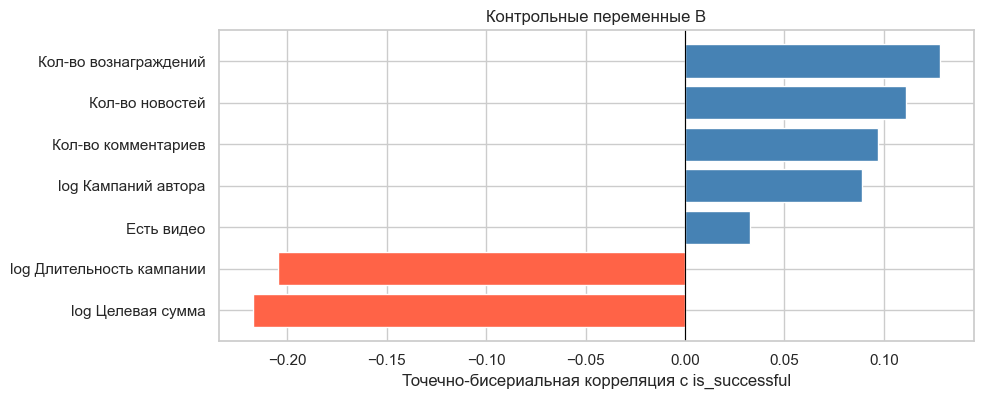

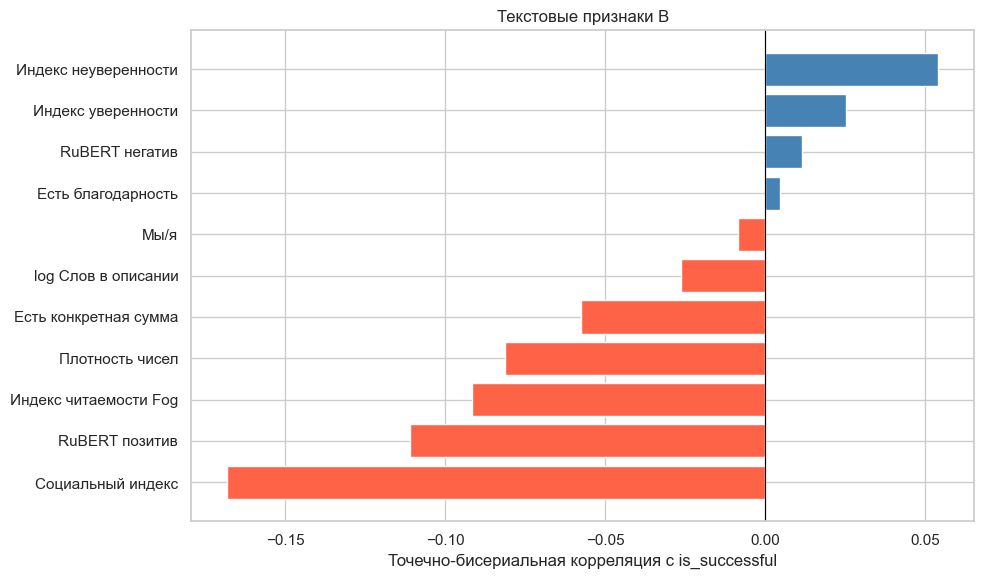

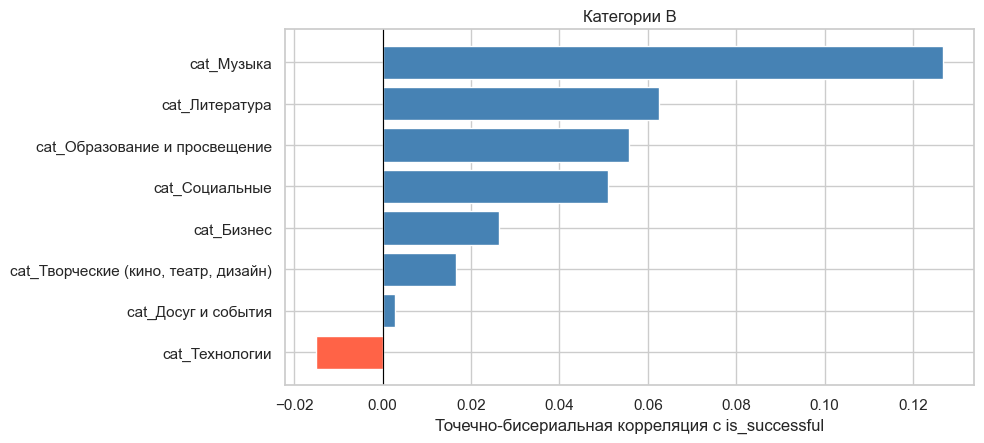

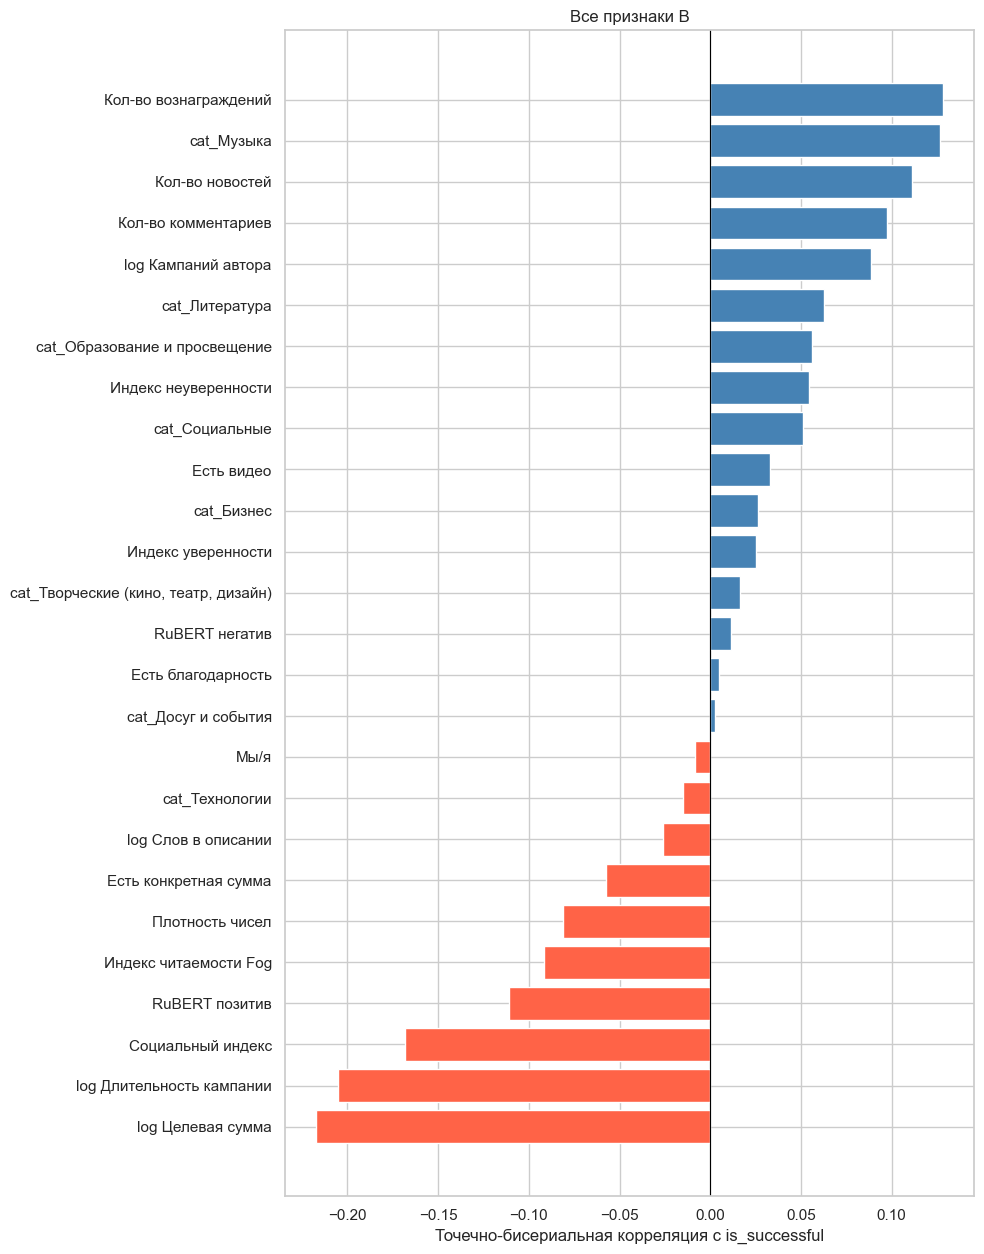

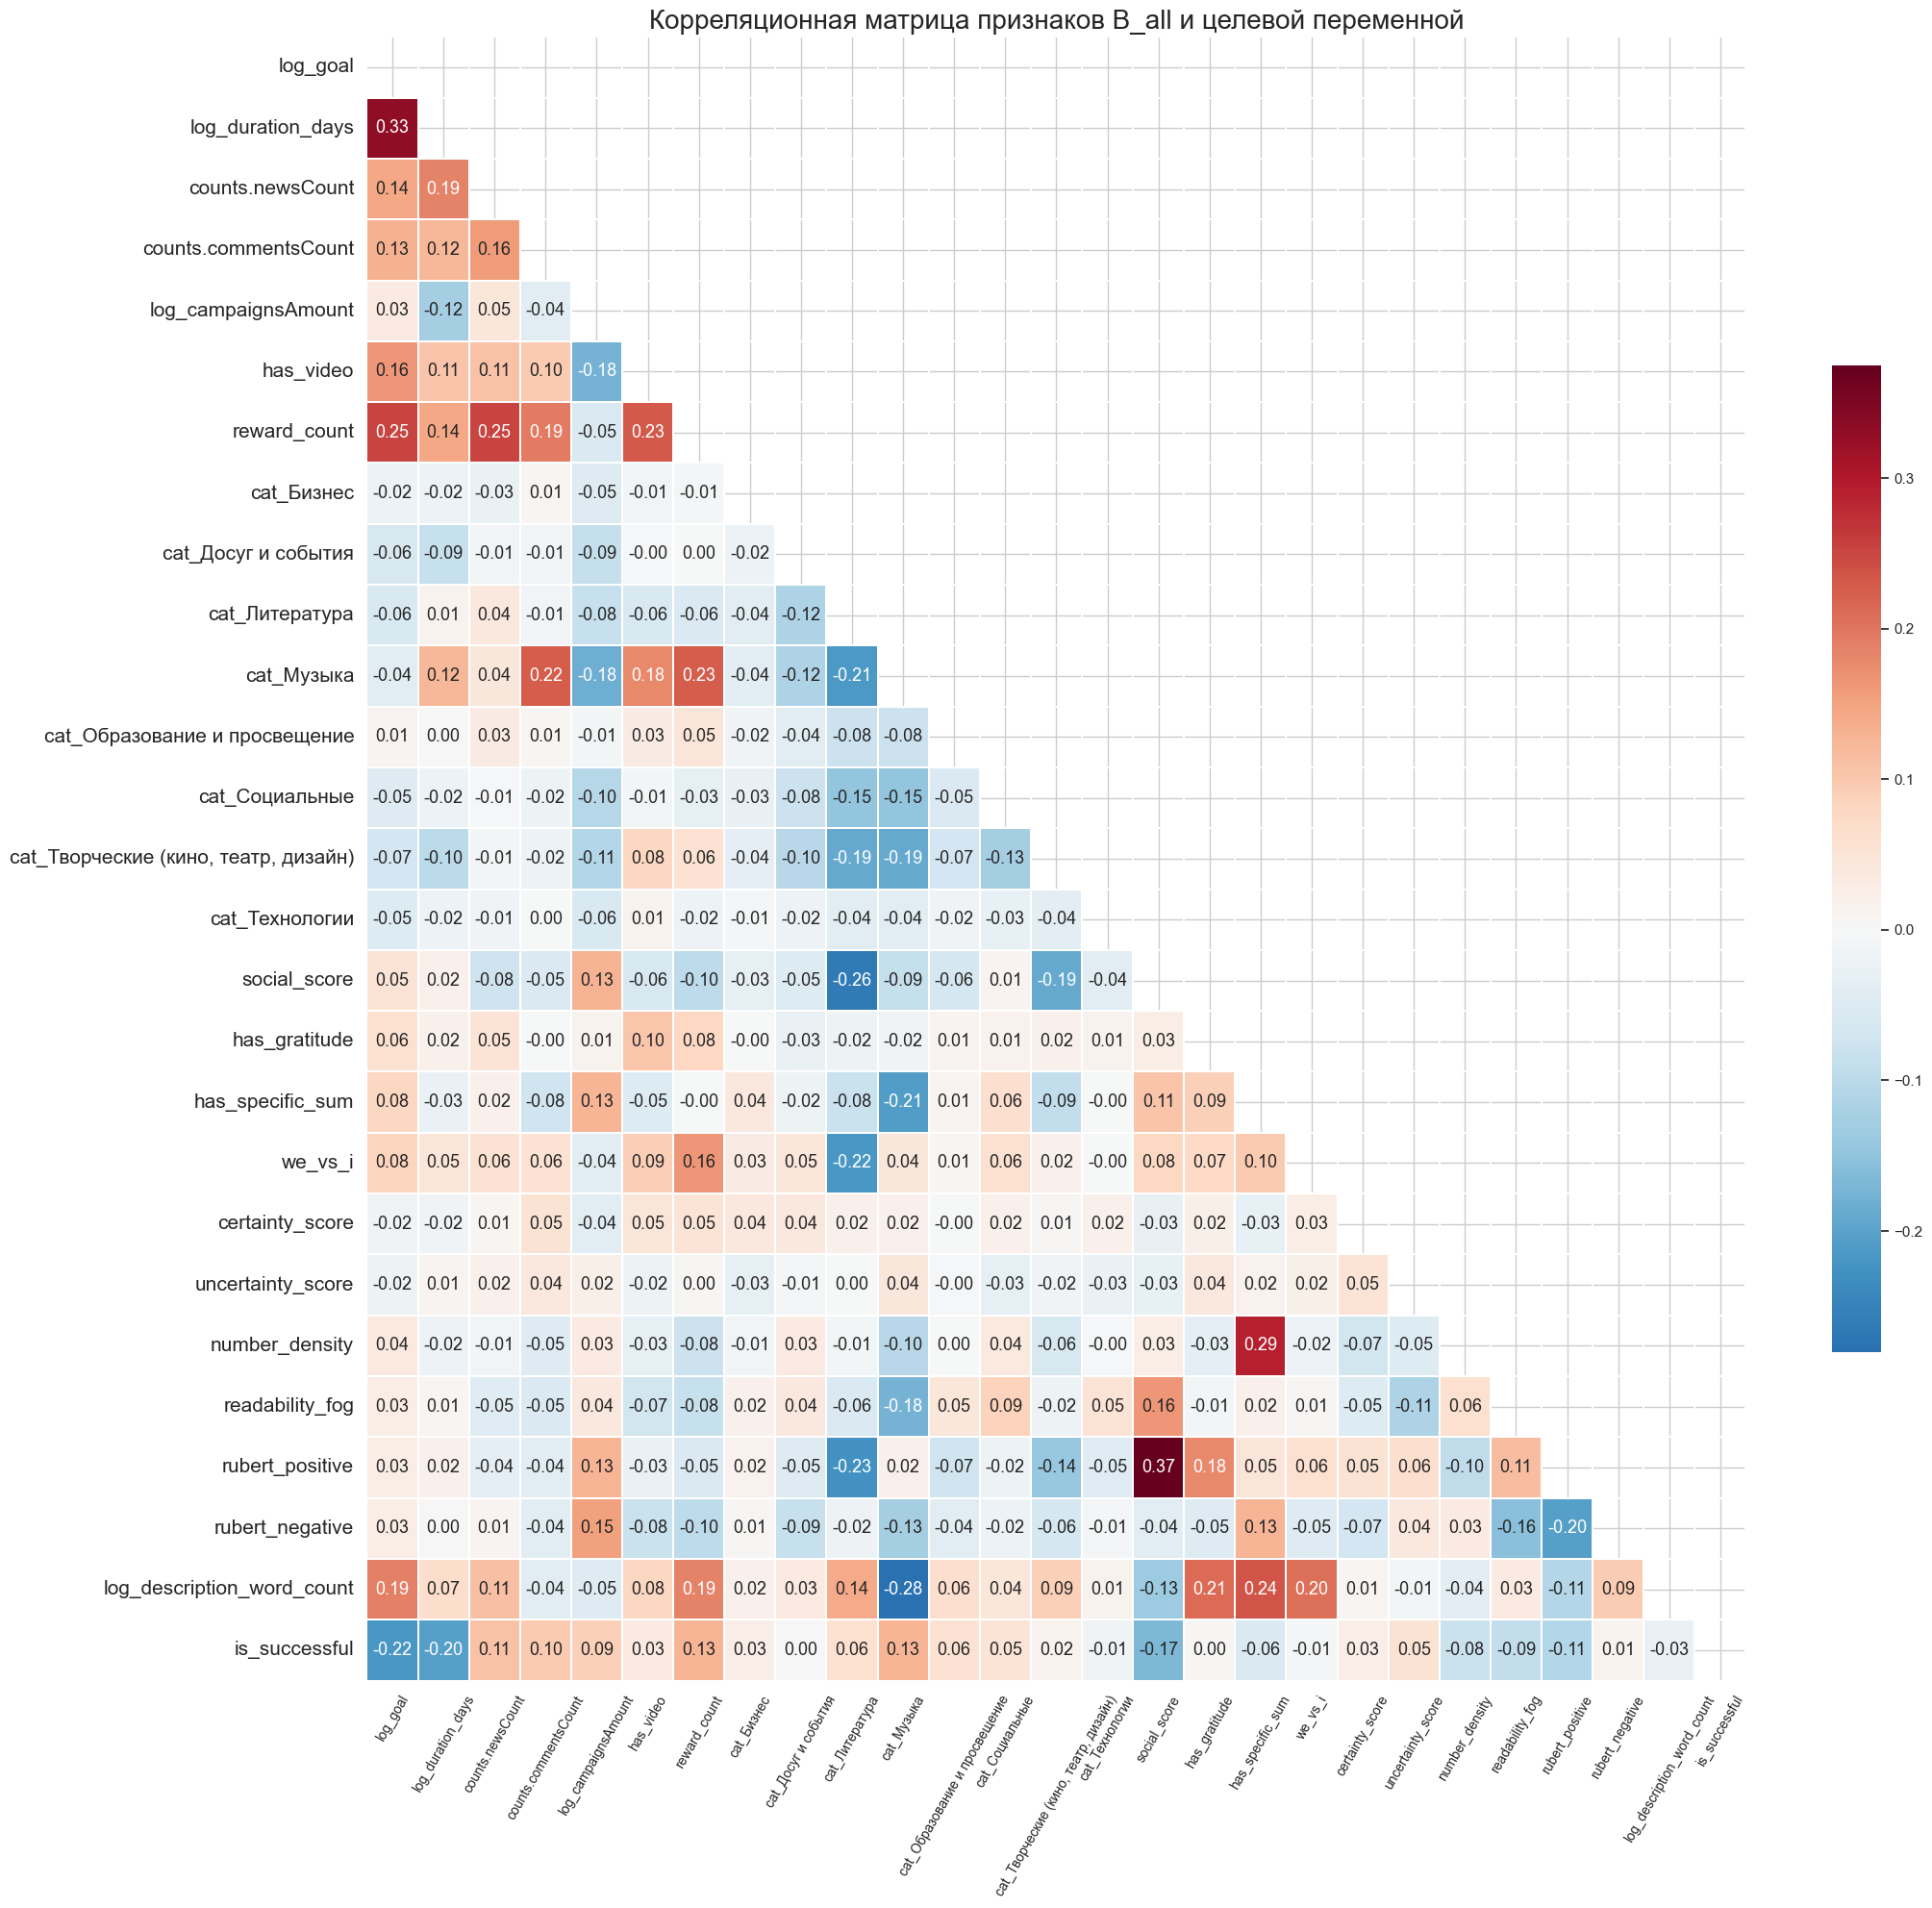

In [43]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns


TARGET = "is_successful"


# ── Текущие признаки модели B ─────────────────────────────────────────────
CONTROL_B = [
    "log_goal",
    "log_duration_days",
    "counts.newsCount",
    "counts.commentsCount",
    "log_campaignsAmount",
    "has_video",
    "reward_count",
]

TEXT_B = [
    "social_score",
    "has_gratitude",
    "has_specific_sum",
    "we_vs_i",
    "certainty_score",
    "uncertainty_score",
    "number_density",
    "readability_fog",
    "rubert_positive",
    "rubert_negative",
    "log_description_word_count",
]

CATEGORY_DUMMIES = [c for c in df.columns if c.startswith("cat_")]

ALL_MODEL_B = CONTROL_B + CATEGORY_DUMMIES + TEXT_B


# Оставляем только реально существующие колонки
CONTROL_B_AVAIL = [c for c in CONTROL_B if c in df.columns]
TEXT_B_AVAIL = [c for c in TEXT_B if c in df.columns]
CATEGORY_DUMMIES_AVAIL = [c for c in CATEGORY_DUMMIES if c in df.columns]
ALL_MODEL_B_AVAIL = [c for c in ALL_MODEL_B if c in df.columns]


print(f"CONTROL_B:    {len(CONTROL_B_AVAIL)} из {len(CONTROL_B)}")
print(f"TEXT_B:       {len(TEXT_B_AVAIL)} из {len(TEXT_B)}")
print(f"CATEGORIES:   {len(CATEGORY_DUMMIES_AVAIL)}")
print(f"ALL_MODEL_B:  {len(ALL_MODEL_B_AVAIL)} признаков")


# ── Подписи признаков ─────────────────────────────────────────────────────
FEATURE_LABELS_B = {
    "log_goal":                   "log Целевая сумма",
    "log_duration_days":          "log Длительность кампании",
    "counts.newsCount":           "Кол-во новостей",
    "counts.commentsCount":       "Кол-во комментариев",
    "log_campaignsAmount":        "log Кампаний автора",
    "has_video":                  "Есть видео",
    "reward_count":               "Кол-во вознаграждений",

    "social_score":               "Социальный индекс",
    "has_gratitude":              "Есть благодарность",
    "has_specific_sum":           "Есть конкретная сумма",
    "we_vs_i":                    "Мы/я",
    "certainty_score":            "Индекс уверенности",
    "uncertainty_score":          "Индекс неуверенности",
    "number_density":             "Плотность чисел",
    "readability_fog":            "Индекс читаемости Fog",
    "rubert_positive":            "RuBERT позитив",
    "rubert_negative":            "RuBERT негатив",
    "log_description_word_count": "log Слов в описании",
}


def _label(col):
    return FEATURE_LABELS_B.get(col, col)


# ── Корреляции с target ───────────────────────────────────────────────────
def correlation_with_target(df, features, target=TARGET, labels=FEATURE_LABELS_B):
    rows = []

    for col in features:
        if col not in df.columns:
            continue

        tmp = df[[target, col]].dropna()

        if tmp.empty:
            continue

        y = tmp[target]
        x = tmp[col]

        # Если признак константный, корреляция не считается
        if x.nunique(dropna=True) < 2 or y.nunique(dropna=True) < 2:
            continue

        r, p_pearson = stats.pointbiserialr(y, x)

        g0 = tmp.loc[tmp[target] == 0, col]
        g1 = tmp.loc[tmp[target] == 1, col]

        if len(g0) >= 2 and len(g1) >= 2:
            t_stat, p_ttest = stats.ttest_ind(g0, g1, equal_var=False)
        else:
            t_stat, p_ttest = np.nan, np.nan

        rows.append(
            {
                "Признак": labels.get(col, col),
                "feature": col,
                "r (т-бис)": round(float(r), 4),
                "p (Pearson)": round(float(p_pearson), 4),
                "t-статистика": round(float(t_stat), 4) if pd.notna(t_stat) else np.nan,
                "p (t-тест)": round(float(p_ttest), 4) if pd.notna(p_ttest) else np.nan,
                "Значим (p<0.05)": "да" if pd.notna(p_ttest) and p_ttest < 0.05 else "нет",
            }
        )

    if not rows:
        return pd.DataFrame()

    return (
        pd.DataFrame(rows)
        .set_index("Признак")
        .sort_values("r (т-бис)", ascending=False)
    )


corr_control = correlation_with_target(df, CONTROL_B_AVAIL)
corr_text = correlation_with_target(df, TEXT_B_AVAIL)
corr_categories = correlation_with_target(df, CATEGORY_DUMMIES_AVAIL)
corr_all = correlation_with_target(df, ALL_MODEL_B_AVAIL)


for name, tbl in [
    ("Контрольные B", corr_control),
    ("Текстовые B", corr_text),
    ("Категории", corr_categories),
    ("Все признаки B", corr_all),
]:
    print(f"\n=== Корреляции — {name} ===")
    if tbl.empty:
        print("Нет доступных признаков.")
    else:
        print(tbl.to_string())


# ── График корреляций ─────────────────────────────────────────────────────
def plot_correlations(corr_df, title):
    if corr_df.empty:
        print(f"{title}: таблица пустая, график не построен.")
        return

    fig, ax = plt.subplots(figsize=(10, len(corr_df) * 0.45 + 1))

    colors = [
        "steelblue" if r >= 0 else "tomato"
        for r in corr_df["r (т-бис)"]
    ]

    ax.barh(corr_df.index, corr_df["r (т-бис)"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Точечно-бисериальная корреляция с is_successful")
    ax.set_title(title)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


plot_correlations(corr_control, "Контрольные переменные B")
plot_correlations(corr_text, "Текстовые признаки B")
plot_correlations(corr_categories, "Категории B")
plot_correlations(corr_all, "Все признаки B")


# ── Корреляционная матрица для B_all ───────────────────────────────────────
heatmap_features = ALL_MODEL_B_AVAIL + [TARGET]
heatmap_features = [f for f in heatmap_features if f in df.columns]

corr_matrix = df[heatmap_features].corr()

fig, ax = plt.subplots(figsize=(22, 20))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 13},
    cmap="RdBu_r",
    center=0,
    linewidths=0.3,
    ax=ax,
    cbar_kws={"shrink": 0.6},
)

ax.set_title(
    "Корреляционная матрица признаков B_all и целевой переменной",
    fontsize=20,
)

ax.tick_params(axis="x", labelsize=10, rotation=60)
ax.tick_params(axis="y", labelsize=15)

plt.tight_layout()
plt.show()


In [83]:
corr_matrix = df[heatmap_features].corr()
corr_matrix

,log_goal,log_duration_days,counts.newsCount,counts.commentsCount,log_campaignsAmount,has_video,reward_count,cat_Бизнес,cat_Досуг и события,cat_Литература,cat_Музыка,cat_Образование и просвещение,cat_Социальные,"cat_Творческие (кино, театр, дизайн)",cat_Технологии,social_score,has_gratitude,has_specific_sum,we_vs_i,certainty_score,uncertainty_score,number_density,readability_fog,rubert_positive,rubert_negative,log_description_word_count,is_successful
log_goal,1.000000,0.330887,0.143756,0.132971,0.034132,0.164944,0.253612,-0.023037,-0.062529,-0.060177,-0.043044,0.010386,-0.048063,-0.069722,-0.050514,0.051209,0.060464,0.082716,0.084046,-0.016357,-0.016847,0.036190,0.028478,0.027051,0.027442,0.190471,-0.217224
log_duration_days,0.330887,1.000000,0.187800,0.123448,-0.124393,0.107789,0.143731,-0.021468,-0.086310,0.014009,0.122648,0.002312,-0.020512,-0.100795,-0.023482,0.017940,0.018034,-0.025753,0.047444,-0.015135,0.009880,-0.023879,0.007106,0.018602,0.002971,0.069930,-0.204995
counts.newsCount,0.143756,0.187800,1.000000,0.159285,0.046033,0.110137,0.252470,-0.025176,-0.011939,0.040508,0.042251,0.031466,-0.006228,-0.010290,-0.014352,-0.077634,0.050715,0.017367,0.056976,0.006461,0.018237,-0.014000,-0.046830,-0.035306,0.011356,0.113223,0.111164
counts.commentsCount,0.132971,0.123448,0.159285,1.000000,-0.042756,0.096323,0.194517,0.008198,-0.011731,-0.012349,0.223927,0.007088,-0.017755,-0.023578,0.000251,-0.053080,-0.000187,-0.075138,0.055472,0.054420,0.037686,-0.049574,-0.054359,-0.043027,-0.044635,-0.043467,0.097258
log_campaignsAmount,0.034132,-0.124393,0.046033,-0.042756,1.000000,-0.175954,-0.053116,-0.047619,-0.089835,-0.084023,-0.181744,-0.011334,-0.104169,-0.110595,-0.059564,0.129317,0.013260,0.126640,-0.044608,-0.044562,0.022716,0.034359,0.037685,0.129031,0.154213,-0.048262,0.088811
has_video,0.164944,0.107789,0.110137,0.096323,-0.175954,1.000000,0.229040,-0.012165,-0.004999,-0.059830,0.179135,0.031268,-0.009269,0.078241,0.013181,-0.062319,0.103265,-0.052190,0.091627,0.049094,-0.019113,-0.032872,-0.072213,-0.025471,-0.083218,0.081847,0.032806
reward_count,0.253612,0.143731,0.252470,0.194517,-0.053116,0.229040,1.000000,-0.007652,0.000656,-0.057010,0.225812,0.048049,-0.033682,0.055111,-0.022061,-0.097425,0.076621,-0.002525,0.162893,0.050297,0.003923,-0.078724,-0.083661,-0.054282,-0.097120,0.185925,0.128090
cat_Бизнес,-0.023037,-0.021468,-0.025176,0.008198,-0.047619,-0.012165,-0.007652,1.000000,-0.022164,-0.041204,-0.041115,-0.015134,-0.027980,-0.036133,-0.008507,-0.033232,-0.001884,0.039875,0.030664,0.037390,-0.033811,-0.014021,0.021475,0.015626,0.005903,0.019488,0.026328
cat_Досуг и события,-0.062529,-0.086310,-0.011939,-0.011731,-0.089835,-0.004999,0.000656,-0.022164,1.000000,-0.115689,-0.115440,-0.042491,-0.078559,-0.101450,-0.023886,-0.051396,-0.025998,-0.017025,0.045750,0.039137,-0.008857,0.033837,0.038969,-0.048656,-0.085201,0.033861,0.002730
cat_Литература,-0.060177,0.014009,0.040508,-0.012349,-0.084023,-0.059830,-0.057010,-0.041204,-0.115689,1.000000,-0.214612,-0.078994,-0.146047,-0.188602,-0.044406,-0.264110,-0.016731,-0.082224,-0.217203,0.021542,0.000045,-0.011146,-0.055309,-0.225205,-0.019202,0.139942,0.062558


## 13. Наборы признаков


In [6]:
CONTROLS = [
    "log_goal", 
    "log_duration_days",
    "counts.newsCount", 
    "counts.commentsCount",
    "log_campaignsAmount",
    "has_video",
    "reward_count",
]

TEXT = [
    "social_score",
    "has_gratitude",
    "has_specific_sum",
    "we_vs_i",
    "certainty_score",
    "uncertainty_score",
    "number_density",
    "readability_fog",
    "rubert_positive",
    "rubert_negative",
    "log_description_word_count",
]

def _avail(cols):
    return [c for c in cols if c in df.columns]


FEATURE_SETS = {
    "A_controls_and_categories": _avail(CONTROLS + CATEGORY_DUMMIES),
    "B_all":                     _avail(CONTROLS + CATEGORY_DUMMIES + TEXT),
    "C_no_cat":                  _avail(CONTROLS + TEXT),
    "D_charity":                 _avail(CONTROLS + TEXT + ["is_charity"]),
}
for name, feats in FEATURE_SETS.items():
    print(f"{name:20s} → {len(feats)} признаков")

A_controls_and_categories → 15 признаков
B_all                → 26 признаков
C_no_cat             → 18 признаков
D_charity            → 19 признаков


In [7]:
# Создание переменной funding_bucket
def make_funding_bucket(series: pd.Series) -> pd.Series:
    bins = [-np.inf, 0.5, 1.0, np.inf]
    labels = [0, 1, 2]  # 0: <0.5, 1: 0.5-1, 2: >=1
    return pd.cut(series, bins=bins, labels=labels, right=False).astype(int)

df["funding_bucket"] = make_funding_bucket(df["funding_ratio"].fillna(0))

# Сохранение DataFrame в Excel
df.to_excel("df_with_funding_bucket.xlsx", index=False)

In [77]:
# Сохранить DataFrame в Excel
df.to_excel("for_stata.xlsx", index=False)

## 14. Визуализации

1. Распределение таргета.
2. Бокс-плоты: ключевые текстовые признаки в разрезе `is_successful`.
3. Корреляционная матрица текстовых признаков + готовых числовых.
4. Корреляции с таргетом (Point-biserial через Pearson).


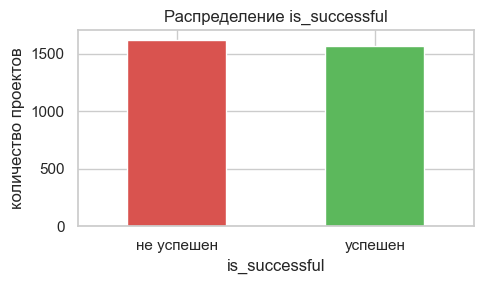

In [54]:
fig, ax = plt.subplots(figsize=(5, 3))
df[TARGET_COL].value_counts().sort_index().plot.bar(ax=ax, color=["#d9534f", "#5cb85c"])
ax.set_xticklabels(["не успешен", "успешен"], rotation=0)
ax.set_title("Распределение is_successful")
ax.set_ylabel("количество проектов")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/target_distribution.png", dpi=120)
plt.show()


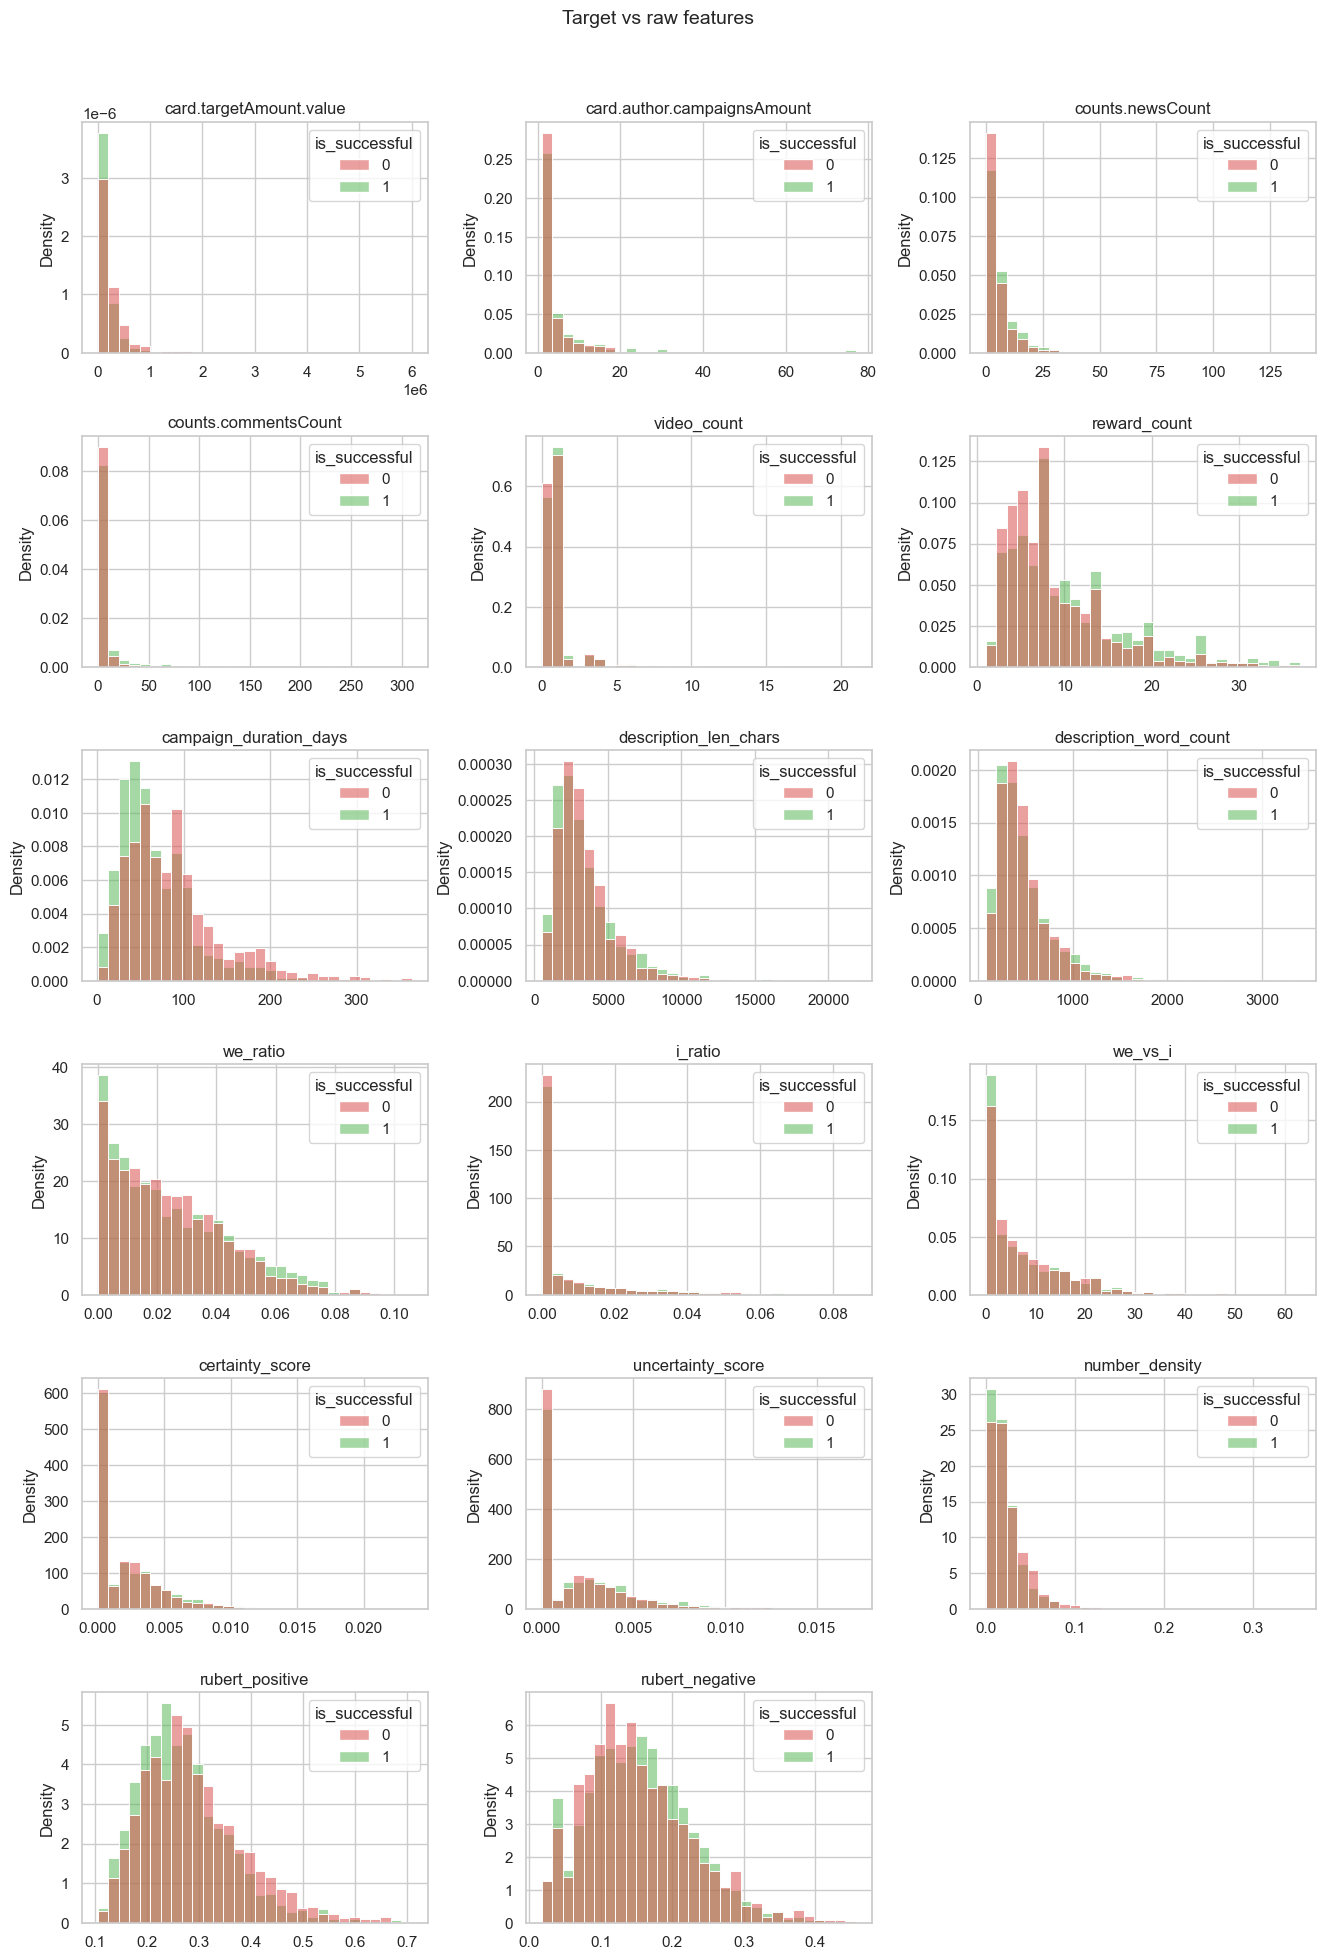

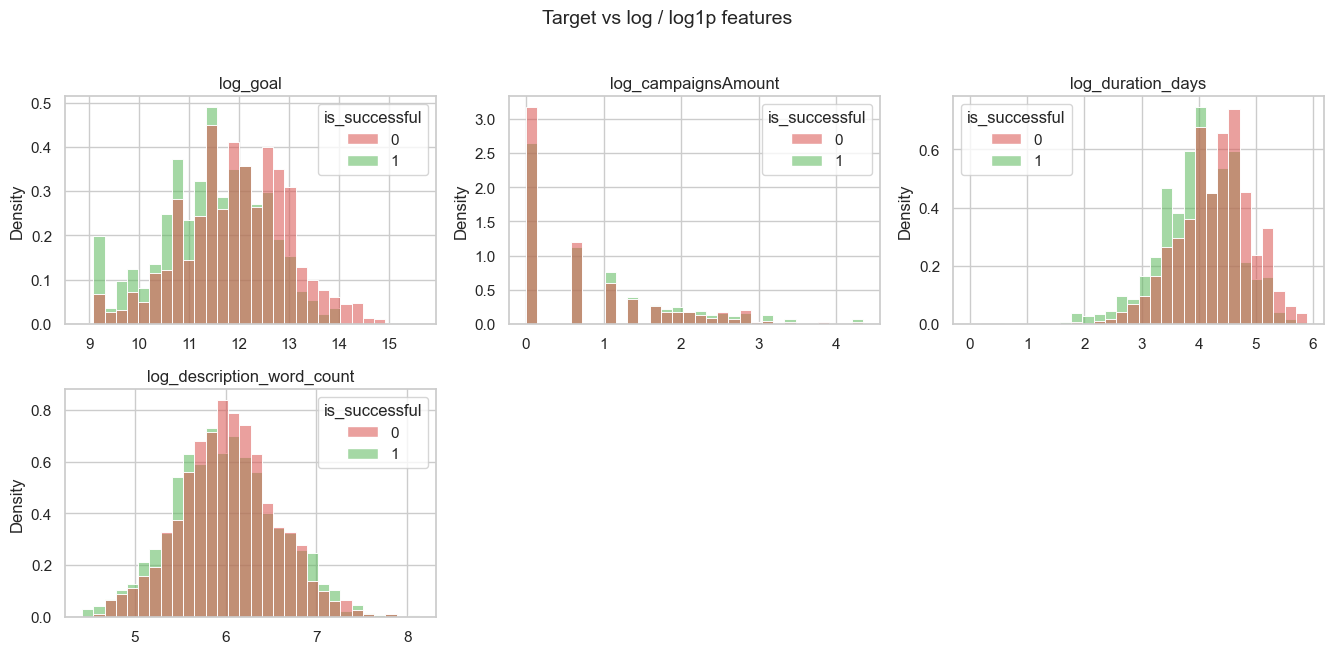

In [55]:
hist_feats_raw = [
    "card.targetAmount.value",
    "card.author.campaignsAmount",
    "counts.newsCount",
    "counts.commentsCount",
    "video_count",
    "reward_count",
    "campaign_duration_days",
    "description_len_chars",
    "description_word_count",
    "we_ratio",
    "i_ratio",
    "we_vs_i",
    "certainty_score",
    "uncertainty_score",
    "number_density",
    "rubert_positive",
    "rubert_negative",
]

hist_feats_log = [
    "log_goal",
    "log_campaignsAmount",
    "log1p_newsCount",
    "log1p_commentsCount",
    "log1p_video_count",
    "log_duration_days",
    "log_description_len_chars",
    "log_description_word_count",
    "log1p_we_ratio",
    "log1p_i_ratio",
    "log1p_we_vs_i",
    "log1p_certainty_score",
    "log1p_uncertainty_score",
    "log1p_number_density",
]

def plot_histograms_by_target(df, features, title, filename):
    features = [c for c in features if c in df.columns]

    if len(features) == 0:
        print(f"Нет доступных колонок для графика: {title}")
        return

    ncol = 3
    nrow = int(np.ceil(len(features) / ncol))

    fig, axes = plt.subplots(nrow, ncol, figsize=(4.5 * ncol, 3.2 * nrow))

    if nrow == 1 and ncol == 1:
        axes = np.array([axes])
    elif nrow == 1:
        axes = np.array([axes])

    for ax, f in zip(axes.flat, features):
        sns.histplot(
            data=df,
            x=f,
            hue=TARGET_COL,
            ax=ax,
            bins=30,
            stat="density",
            common_norm=False,
            palette=["#d9534f", "#5cb85c"],
            alpha=0.55
        )
        ax.set_title(f)
        ax.set_xlabel("")
        ax.set_ylabel("Density")

    for ax in axes.flat[len(features):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{filename}", dpi=120, bbox_inches="tight")
    plt.show()


plot_histograms_by_target(
    df=df,
    features=hist_feats_raw,
    title="Target vs raw features",
    filename="target_vs_raw_features_hist.png"
)

plot_histograms_by_target(
    df=df,
    features=hist_feats_log,
    title="Target vs log / log1p features",
    filename="target_vs_log_features_hist.png"
)


## 14. Проверка на мультиколлинеарность

In [9]:
df_fit = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)

── VIF ──
                             feature      VIF
                          cat_Музыка 2.414100
                      cat_Литература 2.290260
cat_Творческие (кино, театр, дизайн) 2.063967
                        social_score 1.526854
                      cat_Социальные 1.477189
          log_description_word_count 1.454833
                     rubert_positive 1.454453
                 cat_Досуг и события 1.439711
                            log_goal 1.353378
                 log_campaignsAmount 1.341612
                        reward_count 1.340300
                    has_specific_sum 1.297723
                     rubert_negative 1.273423
                   log_duration_days 1.218538
       cat_Образование и просвещение 1.216764
                           has_video 1.156336
                      number_density 1.154434
                             we_vs_i 1.153920
                    counts.newsCount 1.134862
                     readability_fog 1.133453
                counts.c

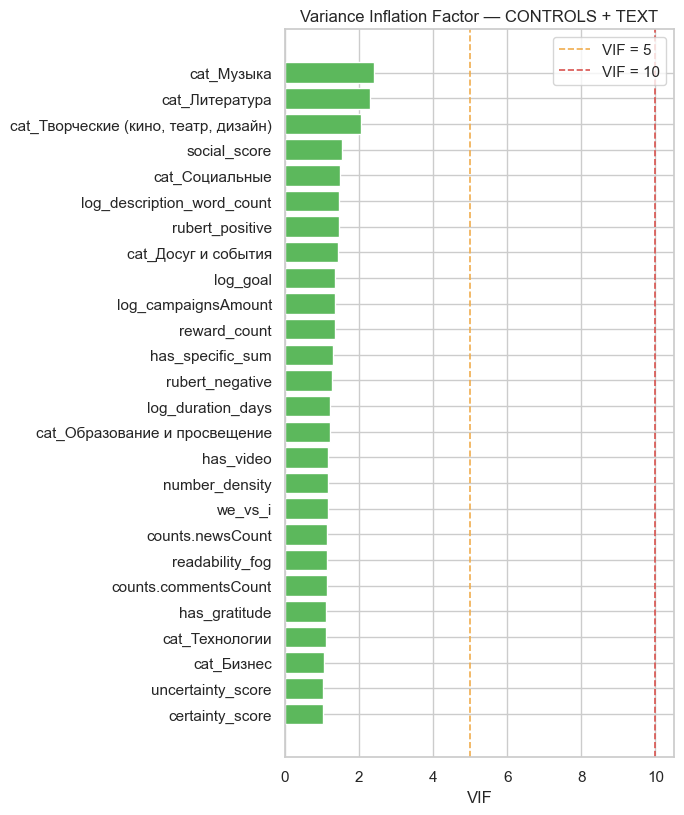

In [18]:
def compute_vif(df_src: pd.DataFrame, features: list) -> pd.DataFrame:
    feats = [f for f in features if f in df_src.columns]
    X = (
        df_src[feats]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .astype(float)
    )
    X = X.loc[:, X.nunique() > 1]
    Xc = sm.add_constant(X, has_constant="add")
    vif_vals = [
        variance_inflation_factor(Xc.values, i)
        for i in range(Xc.shape[1])
    ]
    return (
        pd.DataFrame({"feature": Xc.columns, "VIF": vif_vals})
        .query("feature != 'const'")
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )

continuous_feats = [f for f in CONTROLS + TEXT + CATEGORY_DUMMIES if f in df_fit.columns]
vif_df = compute_vif(df_fit, continuous_feats)

print("── VIF ──")
print(vif_df.to_string(index=False))

high_vif = vif_df[vif_df["VIF"] > 10]
if not high_vif.empty:
    print(f"\nVIF > 10: {high_vif['feature'].tolist()}")
else:
    print("\n✓  нет признаков с VIF > 10 — мультиколлинеарность в норме")

fig, ax = plt.subplots(figsize=(7, max(4, 0.32 * len(vif_df))))
colors = [
    "#d9534f" if v > 10 else "#f0ad4e" if v > 5 else "#5cb85c"
    for v in vif_df["VIF"]
]
ax.barh(
    vif_df["feature"].iloc[::-1],
    vif_df["VIF"].iloc[::-1],
    color=list(reversed(colors))
)
ax.axvline(5,  color="#f0ad4e", lw=1.2, ls="--", label="VIF = 5")
ax.axvline(10, color="#d9534f", lw=1.2, ls="--", label="VIF = 10")
ax.set_xlabel("VIF")
ax.set_title("Variance Inflation Factor — CONTROLS + TEXT")
ax.legend()
plt.tight_layout()
plt.show()

## 14.1 Статистические тесты: Mann–Whitney U, χ² Пирсона, Краскел–Уоллис

Три непараметрических теста для проверки статистической значимости различий между группами **до** регрессионных моделей:

1. **Mann–Whitney U** — сравниваем распределения непрерывных признаков между успешными (`is_successful=1`) и неуспешными (`is_successful=0`) проектами.
2. **χ² Пирсона** — проверяем независимость бинарных и категориальных признаков от `is_successful`.
3. **Краскел–Уоллис** — обобщение Mann–Whitney на три класса (`funding_bucket`: провал / частичный / полный сбор).

Уровни значимости: `***` p<0.001  `**` p<0.01  `*` p<0.05  `†` p<0.10

In [80]:
# ── 4. Подготовка таблиц для вставки в диплом / приложение ───────────────

def _format_p(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "<0,001"
    return str(round(float(p), 3)).replace(".", ",")


def _format_num(x, digits=3):
    if pd.isna(x):
        return ""
    return str(round(float(x), digits)).replace(".", ",")


# Mann–Whitney: таблица для приложения
mw_table = mw_df.copy()

if not mw_table.empty:
    mw_table = mw_table.rename(columns={
        "Мед (неусп.)": "Медиана: неуспешные проекты",
        "Мед (усп.)": "Медиана: успешные проекты",
        "p": "p-value",
        "Знач.": "Стат. значимость"
    })

    mw_table["p-value"] = mw_table["p-value"].apply(_format_p)
    mw_table["U"] = mw_table["U"].apply(lambda x: _format_num(x, 1))
    mw_table["Медиана: неуспешные проекты"] = mw_table["Медиана: неуспешные проекты"].apply(lambda x: _format_num(x, 4))
    mw_table["Медиана: успешные проекты"] = mw_table["Медиана: успешные проекты"].apply(lambda x: _format_num(x, 4))

    mw_table = mw_table[
        [
            "Признак",
            "Медиана: неуспешные проекты",
            "Медиана: успешные проекты",
            "U",
            "p-value",
            "Стат. значимость"
        ]
    ]


# χ²: таблица для приложения
chi2_table = chi2_df.copy()

if not chi2_table.empty:
    chi2_table = chi2_table.rename(columns={
        "p": "p-value",
        "Знач.": "Стат. значимость"
    })

    chi2_table["χ²"] = chi2_table["χ²"].apply(lambda x: _format_num(x, 3))
    chi2_table["p-value"] = chi2_table["p-value"].apply(_format_p)

    chi2_table = chi2_table[
        [
            "Признак",
            "χ²",
            "df",
            "p-value",
            "Стат. значимость"
        ]
    ]


# Kruskal–Wallis: таблица для приложения
kw_table = kw_df.copy()

if not kw_table.empty:
    kw_table = kw_table.rename(columns={
        "p": "p-value",
        "Знач.": "Стат. значимость"
    })

    kw_table["H"] = kw_table["H"].apply(lambda x: _format_num(x, 3))
    kw_table["p-value"] = kw_table["p-value"].apply(_format_p)

    kw_table = kw_table[
        [
            "Признак",
            "H",
            "p-value",
            "Стат. значимость"
        ]
    ]


# ── 5. Сводная таблица значимых признаков ────────────────────────────────

summary_rows = []

if not mw_df.empty:
    for _, r in mw_df[mw_df["p"] < 0.05].iterrows():
        summary_rows.append({
            "Тест": "Манна–Уитни",
            "Признак": r["Признак"],
            "p-value": _format_p(r["p"]),
            "Интерпретация": "Различия между успешными и неуспешными проектами статистически значимы"
        })

if not chi2_df.empty:
    for _, r in chi2_df[chi2_df["p"] < 0.05].iterrows():
        summary_rows.append({
            "Тест": "χ² Пирсона",
            "Признак": r["Признак"],
            "p-value": _format_p(r["p"]),
            "Интерпретация": "Признак статистически связан с успешностью проекта"
        })

if not kw_df.empty:
    for _, r in kw_df[kw_df["p"] < 0.05].iterrows():
        summary_rows.append({
            "Тест": "Краскела–Уоллиса",
            "Признак": r["Признак"],
            "p-value": _format_p(r["p"]),
            "Интерпретация": "Есть статистически значимые различия между уровнями успешности"
        })

significant_summary = pd.DataFrame(summary_rows)


# ── 6. Короткая таблица для основного текста диплома ─────────────────────

main_text_table = pd.DataFrame({
    "Группа признаков": [
        "Финансовые характеристики",
        "Длительность кампании",
        "Вовлечённость аудитории",
        "Опыт автора",
        "Вознаграждения",
        "Объём текста",
        "Содержательные текстовые признаки",
        "Мультимедийные признаки",
        "Категория проекта"
    ],
    "Основной результат": [
        "Целевая сумма статистически значимо различается между группами",
        "При сравнении двух групп различия незначимы, но значимы для трёх уровней успешности",
        "Количество новостей и комментариев значимо выше/ниже в зависимости от группы",
        "Количество прошлых кампаний автора статистически значимо связано с успешностью",
        "Количество уровней вознаграждений статистически значимо различается между группами",
        "Количество слов в описании не имеет статистически значимых различий",
        "Социальность, «мы/я», плотность чисел, Fog-индекс и RuBERT-показатели значимы",
        "Наличие видео статистически связано с успешностью",
        "Категория проекта статистически связана с успешностью"
    ],
    "Тест": [
        "Манна–Уитни; Краскела–Уоллиса",
        "Манна–Уитни; Краскела–Уоллиса",
        "Манна–Уитни; Краскела–Уоллиса",
        "Манна–Уитни; Краскела–Уоллиса",
        "Манна–Уитни; Краскела–Уоллиса",
        "Манна–Уитни; Краскела–Уоллиса",
        "Манна–Уитни; Краскела–Уоллиса",
        "χ² Пирсона",
        "χ² Пирсона"
    ],
    "Вывод для исследования": [
        "Высокая финансовая цель снижает вероятность успешного завершения кампании",
        "Связь с успешностью может быть нелинейной",
        "Коммуникационная активность автора и аудитории связана с успехом",
        "Опыт автора необходимо учитывать в моделях",
        "Проработанная система вознаграждений связана с успехом",
        "Важен не объём текста, а его содержание",
        "Текстовые признаки целесообразно включать в модели",
        "Видео следует учитывать как бинарный объясняющий признак",
        "Категорию проекта необходимо использовать как контрольную переменную"
    ]
})


# ── 7. Вывод таблиц в ноутбуке ───────────────────────────────────────────

print("\n\nТаблица для основного текста:")
display(main_text_table)

print("\n\nMann–Whitney U для приложения:")
display(mw_table)

print("\n\nχ² Пирсона для приложения:")
display(chi2_table)

print("\n\nКраскел–Уоллис для приложения:")
display(kw_table)

print("\n\nСводка значимых признаков:")
display(significant_summary)



Таблица для основного текста:


,Группа признаков,Основной результат,Тест,Вывод для исследования
0,Финансовые характеристики,Целевая сумма статистически значимо различаетс...,Манна–Уитни; Краскела–Уоллиса,Высокая финансовая цель снижает вероятность ус...
1,Длительность кампании,"При сравнении двух групп различия незначимы, н...",Манна–Уитни; Краскела–Уоллиса,Связь с успешностью может быть нелинейной
2,Вовлечённость аудитории,Количество новостей и комментариев значимо выш...,Манна–Уитни; Краскела–Уоллиса,Коммуникационная активность автора и аудитории...
3,Опыт автора,Количество прошлых кампаний автора статистичес...,Манна–Уитни; Краскела–Уоллиса,Опыт автора необходимо учитывать в моделях
4,Вознаграждения,Количество уровней вознаграждений статистическ...,Манна–Уитни; Краскела–Уоллиса,Проработанная система вознаграждений связана с...
5,Объём текста,Количество слов в описании не имеет статистиче...,Манна–Уитни; Краскела–Уоллиса,"Важен не объём текста, а его содержание"
6,Содержательные текстовые признаки,"Социальность, «мы/я», плотность чисел, Fog-инд...",Манна–Уитни; Краскела–Уоллиса,Текстовые признаки целесообразно включать в мо...
7,Мультимедийные признаки,Наличие видео статистически связано с успешностью,χ² Пирсона,Видео следует учитывать как бинарный объясняющ...
8,Категория проекта,Категория проекта статистически связана с успе...,χ² Пирсона,Категорию проекта необходимо использовать как ...




Mann–Whitney U для приложения:


,Признак,Медиана: неуспешные проекты,Медиана: успешные проекты,U,p-value,Стат. значимость
0,Целевая сумма,"229500,0","150000,0","377324,0","<0,001",***
1,Новостей,"1,0","3,0","227809,0","<0,001",***
2,Комментариев,"0,0","1,0","214968,5","<0,001",***
3,Кампаний автора,"3,0","1,0","412820,0","<0,001",***
4,Вознаграждений,"6,0","8,0","236477,0","<0,001",***
5,Социальность,"0,0442","0,0206","466555,5","<0,001",***
6,Мы/я,"6,0","4,0","344114,0","<0,001",***
7,Плотность чисел,"0,0213","0,0168","344069,0","<0,001",***
8,Fog-индекс,"24,6186","23,7949","343839,5","<0,001",***
9,RuBERT позитив,"0,3136","0,2573","405899,5","<0,001",***




χ² Пирсона для приложения:


,Признак,χ²,df,p-value,Стат. значимость
0,Категория проекта,"1514,135",16,"<0,001",***
1,Конкр. сумма,"75,372",2,"<0,001",***
2,Наличие видео,"25,746",2,"<0,001",***
3,Благодарность,"0,299",2,"0,861",




Краскел–Уоллис для приложения:


,Признак,H,p-value,Стат. значимость
0,Целевая сумма,"225,424","<0,001",***
1,"Длит. кампании, дни","137,13","<0,001",***
2,Новостей,"129,986","<0,001",***
3,Комментариев,"158,761","<0,001",***
4,Кампаний автора,"216,08","<0,001",***
5,Вознаграждений,"85,559","<0,001",***
6,Социальность,"452,161","<0,001",***
7,Мы/я,"34,559","<0,001",***
8,Плотность чисел,"54,194","<0,001",***
9,Fog-индекс,"60,032","<0,001",***




Сводка значимых признаков:


,Тест,Признак,p-value,Интерпретация
0,Манна–Уитни,Целевая сумма,"<0,001",Различия между успешными и неуспешными проекта...
1,Манна–Уитни,Новостей,"<0,001",Различия между успешными и неуспешными проекта...
2,Манна–Уитни,Комментариев,"<0,001",Различия между успешными и неуспешными проекта...
3,Манна–Уитни,Кампаний автора,"<0,001",Различия между успешными и неуспешными проекта...
4,Манна–Уитни,Вознаграждений,"<0,001",Различия между успешными и неуспешными проекта...
5,Манна–Уитни,Социальность,"<0,001",Различия между успешными и неуспешными проекта...
6,Манна–Уитни,Мы/я,"<0,001",Различия между успешными и неуспешными проекта...
7,Манна–Уитни,Плотность чисел,"<0,001",Различия между успешными и неуспешными проекта...
8,Манна–Уитни,Fog-индекс,"<0,001",Различия между успешными и неуспешными проекта...
9,Манна–Уитни,RuBERT позитив,"<0,001",Различия между успешными и неуспешными проекта...


In [81]:
df_fit["experience_group"] = pd.cut(
    df_fit["card.author.campaignsAmount"],
    bins=[0, 1, 3, 10, np.inf],
    labels=[
        "1 кампания",
        "2–3 кампании",
        "4–10 кампаний",
        "11+ кампаний"
    ]
)

experience_success = (
    df_fit
    .groupby("experience_group")["is_successful"]
    .mean()
    .mul(100)
    .round(1)
)

print(experience_success)

experience_group
1 кампания       44.7
2–3 кампании     50.4
4–10 кампаний    53.4
11+ кампаний     55.8
Name: is_successful, dtype: float64


## 15. Logit-регрессия

Таргет бинарный
Используем Logit с HC1-ошибками по нескольким спецификациям.


In [28]:
bool_cols = df_fit.select_dtypes(include="bool").columns.tolist()
df_fit[bool_cols] = df_fit[bool_cols].astype(int)
print(f"Сконвертировано bool→int: {len(bool_cols)} колонок")

y = df_fit[TARGET_COL].astype(int)

logit_results = {}

for name, feats in FEATURE_SETS.items():
    feats = [f for f in feats if f in df_fit.columns]

    print(f"\n{'─'*60}")
    print(f"[{name}] признаки ({len(feats)} шт.): {feats}")
    print(f"{'─'*60}")

    X = (
        df_fit[feats]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .astype(float)
    )
    X = X.loc[:, X.nunique() > 1]
    X = sm.add_constant(X, has_constant="add")

    model = sm.Logit(y, X).fit(disp=0, maxiter=200, cov_type="HC1")

    print(model.summary())
    logit_results[name] = model

Сконвертировано bool→int: 8 колонок

────────────────────────────────────────────────────────────
[A_controls_and_categories] признаки (15 шт.): ['log_goal', 'log_duration_days', 'counts.newsCount', 'counts.commentsCount', 'log_campaignsAmount', 'has_video', 'reward_count', 'cat_Бизнес', 'cat_Досуг и события', 'cat_Литература', 'cat_Музыка', 'cat_Образование и просвещение', 'cat_Социальные', 'cat_Творческие (кино, театр, дизайн)', 'cat_Технологии']
────────────────────────────────────────────────────────────
                           Logit Regression Results                           
Dep. Variable:          is_successful   No. Observations:                 3192
Model:                          Logit   Df Residuals:                     3176
Method:                           MLE   Df Model:                           15
Date:                Sun, 10 May 2026   Pseudo R-squ.:                  0.1467
Time:                        14:21:09   Log-Likelihood:                -1887.7
converged:  

## 15.1 Средние предельные эффекты: Logit (AME)


In [78]:
import numpy as np

# ── Словарь типов преобразований ──────────────────────────────────────────
# ВАЖНО:
# здесь должны быть только те переменные, которые реально входят в модель
# уже в преобразованном виде.
#
# Переменные counts.newsCount, counts.commentsCount, we_vs_i,
# certainty_score, uncertainty_score, number_density теперь НЕ log1p,
# поэтому они удалены из FEATURE_TRANSFORMS.
FEATURE_TRANSFORMS = {
    "log_goal":                   ("log", "Целевая сумма"),
    "log_duration_days":          ("log", "Длит. кампании, дни"),
    "log_campaignsAmount":        ("log", "Кампаний автора"),
    "log_description_word_count": ("log", "Слов в описании"),
}


# ── Названия для красивого вывода обычных признаков ───────────────────────
FEATURE_LABELS = {
    # controls
    "log_goal":                   "Целевая сумма",
    "log_duration_days":          "Длит. кампании, дни",
    "counts.newsCount":           "Новостей",
    "counts.commentsCount":       "Комментариев",
    "log_campaignsAmount":        "Кампаний автора",
    "has_video":                  "Есть видео",
    "reward_count":               "Кол-во вознаграждений",

    # text
    "social_score":               "Социальность",
    "has_gratitude":              "Благодарность",
    "has_specific_sum":           "Конкретная сумма",
    "we_vs_i":                    "Мы/я",
    "certainty_score":            "Уверенность",
    "uncertainty_score":          "Неуверенность",
    "number_density":             "Плотность чисел",
    "readability_fog":            "Readability Fog",
    "rubert_positive":            "RuBERT positive",
    "rubert_negative":            "RuBERT negative",
    "log_description_word_count": "Слов в описании",
}


def _pretty_name(feat):
    """Красивое название переменной для вывода."""
    return FEATURE_LABELS.get(feat, feat)


def _stata_fmt(x, dec=7):
    """Stata-style: drop leading 0 for |x|<1."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return " " + "." * (dec + 1)

    if abs(x) < 1:
        sign = "-" if x < 0 else " "
        return sign + f"{abs(x):.{dec}f}"[1:]

    return f"{x:.{dec}f}"


def _is_binary_col(col, df):
    """
    Определяет, является ли переменная бинарной.
    Используется только для красивой печати и для dummy=True в margeff.
    """
    if col not in df.columns:
        return (
            col.startswith("cat_")
            or col.startswith("has_")
            or col.startswith("is_")
        )

    vals = set(df[col].dropna().unique())
    return vals <= {0, 1, 0.0, 1.0, False, True}


def _cov_type(model):
    """Возвращает тип ковариационной матрицы модели, если доступен."""
    return getattr(model, "cov_type", "nonrobust")


def _warn_if_not_hc1(model, label):
    """Предупреждает, если модель не оценена с HC1."""
    cov = _cov_type(model)
    if str(cov).upper() != "HC1":
        print(
            f"\n[WARNING · {label}] model.cov_type = {cov}. "
            f"AME будут посчитаны, но SE/z/p/CI могут быть НЕ HC1. "
            f"Оцени модель как fit(cov_type='HC1')."
        )


def _make_rows_from_margeff(model, me, df_fit, alpha=0.05):
    """Собирает строки таблицы AME."""
    feat_names = [n for n in model.model.exog_names if n != "const"]
    ci = me.conf_int(alpha=alpha)

    rows = []
    for i, feat in enumerate(feat_names):
        is_bin = _is_binary_col(feat, df_fit)

        if is_bin:
            display = f"1.{feat}"
        else:
            display = feat

        rows.append(
            dict(
                feat=feat,
                display=display,
                pretty=_pretty_name(feat),
                dydx=float(me.margeff[i]),
                se=float(me.margeff_se[i]),
                z=float(me.tvalues[i]),
                p=float(me.pvalues[i]),
                ci_low=float(ci[i, 0]),
                ci_high=float(ci[i, 1]),
                is_bin=is_bin,
            )
        )

    return rows


def print_ame_stata(model, label, df_fit, alpha=0.05, pp_table=True):
    """
    Печатает AME в стиле Stata.

    Важно:
    - get_margeff(at='overall', method='dydx', dummy=True) считает AME.
    - Для бинарных 0/1 переменных dummy=True считает дискретный эффект 0 -> 1.
    - SE считаются delta-method и используют ковариационную матрицу,
      сохранённую в объекте model. Поэтому для HC1 модель должна быть
      оценена как fit(cov_type='HC1').

    pp_table=True:
    - основная таблица AME остаётся в долях вероятности, как в Stata;
    - мини-таблица для log-признаков дополнительно выводится в процентных пунктах.
    """
    _warn_if_not_hc1(model, label)

    try:
        me = model.get_margeff(at="overall", method="dydx", dummy=True)
    except Exception as e:
        print(f"[{label}] get_margeff error: {e}")
        return None

    rows = _make_rows_from_margeff(model, me, df_fit, alpha=alpha)

    # ── Основная таблица AME ───────────────────────────────────────────────
    W = 34
    SEP = "─" * 100

    print(f"\n{'═' * 100}")
    print(f"  AME · Logit · {label}")
    print(f"{'═' * 100}")
    print(f"{'':>{W}}  {'Delta-method':^58}")
    print(
        f"{'':>{W}}  "
        f"{'dy/dx':>11}  "
        f"{'Std. Err.':>11}  "
        f"{'z':>6}  "
        f"{'P>|z|':>6}  "
        f"{'[95% Conf. Interval]':>22}"
    )
    print(SEP)

    for r in rows:
        n_disp = r["display"]
        if len(n_disp) > W:
            n_disp = n_disp[: W - 1] + "…"

        print(
            f"{n_disp:>{W}}  "
            f"{_stata_fmt(r['dydx']):>11}  "
            f"{_stata_fmt(r['se']):>11}  "
            f"{r['z']:>6.2f}  "
            f"{r['p']:>6.3f}  "
            f"{_stata_fmt(r['ci_low']):>12}  "
            f"{_stata_fmt(r['ci_high']):>11}"
        )

    cov = _cov_type(model)
    print(SEP)
    print(
        f"  n={int(model.nobs)}   "
        f"at=overall (AME)   "
        f"SE: Delta-method   "
        f"cov_type={cov}"
    )

    # ── Мини-таблица: перевод log-признаков на сырую шкалу ────────────────
    log_rows = [r for r in rows if r["feat"] in FEATURE_TRANSFORMS]

    if log_rows:
        print(f"\n  Перевод log-признаков на сырую шкалу")
        print(f"  Локальная аппроксимация: ΔP ≈ AME × ΔZ, где Z — переменная в модели.")
        print(f"  Для log(X): при росте X на k раз ΔZ = ln(k).")

        if pp_table:
            print(
                f"\n  {'Признак':<30} "
                f"{'тип':>6} "
                f"{'AME':>10} "
                f"{'AME, п.п.':>10} "
                f"{'+1%, п.п.':>11} "
                f"{'+10%, п.п.':>12} "
                f"{'×2, п.п.':>10}"
            )
            print(f"  {'─' * 100}")

            for r in log_rows:
                kind, pretty = FEATURE_TRANSFORMS[r["feat"]]
                ame = r["dydx"]

                effect_1_pp = ame * np.log(1.01) * 100
                effect_10_pp = ame * np.log(1.10) * 100
                effect_2_pp = ame * np.log(2) * 100

                print(
                    f"  {pretty:<30} "
                    f"{kind:>6} "
                    f"{ame:>10.5f} "
                    f"{ame * 100:>10.2f} "
                    f"{effect_1_pp:>11.3f} "
                    f"{effect_10_pp:>12.2f} "
                    f"{effect_2_pp:>10.2f}"
                )
        else:
            print(
                f"\n  {'Признак':<30} "
                f"{'тип':>6} "
                f"{'AME':>10} "
                f"{'+1%, ΔP':>11} "
                f"{'+10%, ΔP':>12} "
                f"{'×2, ΔP':>10}"
            )
            print(f"  {'─' * 90}")

            for r in log_rows:
                kind, pretty = FEATURE_TRANSFORMS[r["feat"]]
                ame = r["dydx"]

                effect_1 = ame * np.log(1.01)
                effect_10 = ame * np.log(1.10)
                effect_2 = ame * np.log(2)

                print(
                    f"  {pretty:<30} "
                    f"{kind:>6} "
                    f"{ame:>10.5f} "
                    f"{effect_1:>11.5f} "
                    f"{effect_10:>12.5f} "
                    f"{effect_2:>10.5f}"
                )

        print()

    return me


# ── Опционально: точный средний дискретный эффект для изменения raw X ──────
def average_discrete_change_log_feature(
    model,
    df_model,
    feature,
    transform,
    factor=None,
    raw_old=None,
    raw_new=None,
):
    """
    Считает точный средний дискретный эффект изменения raw-переменной
    через повторное прогнозирование, а не через линейную аппроксимацию AME × ΔZ.

    Сейчас актуально прежде всего для признаков:
    - log_goal
    - log_duration_days
    - log_campaignsAmount
    - log_description_word_count

    Параметры
    ---------
    model : fitted statsmodels Logit result
        Оценённая логит-модель.

    df_model : DataFrame
        DataFrame с теми же exog-переменными, которые использовались в модели.
        Должен содержать const, если модель оценивалась с const.

    feature : str
        Название transformed-переменной в модели, например 'log_goal'.

    transform : {'log', 'log1p'}
        Тип преобразования.

    factor : float, optional
        Во сколько раз увеличить исходный raw X.
        Например, factor=1.01, factor=1.10 или factor=2.

    raw_old : array-like или scalar, optional
        Старые значения raw X.

    raw_new : array-like или scalar, optional
        Новые значения raw X. Если задано, используется вместо factor.

    Возвращает
    ----------
    float
        Средняя разница прогнозных вероятностей, в долях вероятности.
        Для процентных пунктов умножить на 100.
    """
    if feature not in df_model.columns:
        raise ValueError(f"{feature} нет в df_model.columns")

    if transform not in {"log", "log1p"}:
        raise ValueError("transform должен быть 'log' или 'log1p'.")

    X_old = df_model.copy()
    X_new = df_model.copy()

    p_old = model.predict(X_old)

    if raw_new is not None:
        if raw_old is None:
            raise ValueError("Если задан raw_new, нужно также задать raw_old.")

        raw_old_arr = np.asarray(raw_old)
        raw_new_arr = np.asarray(raw_new)

        if transform == "log":
            if np.any(raw_old_arr <= 0) or np.any(raw_new_arr <= 0):
                raise ValueError("Для log(X) raw_old и raw_new должны быть > 0.")
            X_new[feature] = np.log(raw_new_arr)

        elif transform == "log1p":
            if np.any(raw_old_arr < 0) or np.any(raw_new_arr < 0):
                raise ValueError("Для log1p(X) raw_old и raw_new должны быть >= 0.")
            X_new[feature] = np.log1p(raw_new_arr)

    elif factor is not None:
        if factor <= 0:
            raise ValueError("factor должен быть > 0.")

        if transform == "log":
            # log(kX) = log(X) + log(k), если X > 0
            X_new[feature] = X_old[feature] + np.log(factor)

        elif transform == "log1p":
            if raw_old is None:
                raise ValueError(
                    "Для точного factor-изменения log1p нужно передать raw_old."
                )

            raw_old_arr = np.asarray(raw_old)

            if np.any(raw_old_arr < 0):
                raise ValueError("Для log1p(X) raw_old должен быть >= 0.")

            raw_new_arr = factor * raw_old_arr
            X_new[feature] = np.log1p(raw_new_arr)

    else:
        raise ValueError("Нужно задать либо factor, либо raw_new.")

    p_new = model.predict(X_new)

    return float(np.mean(p_new - p_old))


# ── Актуальные наборы признаков ───────────────────────────────────────────
CONTROLS = [
    "log_goal",
    "log_duration_days",
    "counts.newsCount",
    "counts.commentsCount",
    "log_campaignsAmount",
    "has_video",
    "reward_count",
]

TEXT = [
    "social_score",
    "has_gratitude",
    "has_specific_sum",
    "we_vs_i",
    "certainty_score",
    "uncertainty_score",
    "number_density",
    "readability_fog",
    "rubert_positive",
    "rubert_negative",
    "log_description_word_count",
]


def _avail(cols):
    return [c for c in cols if c in df.columns]


FEATURE_SETS = {
    "A_controls_and_categories": _avail(CONTROLS + CATEGORY_DUMMIES),
    "B_all": _avail(CONTROLS + CATEGORY_DUMMIES + TEXT),
}


for name, feats in FEATURE_SETS.items():
    print(f"{name:28s} → {len(feats)} признаков")


# ── Запуск для всех оценённых logit-моделей ───────────────────────────────
logit_ame = {}

for name, model in logit_results.items():
    me = print_ame_stata(
        model=model,
        label=name,
        df_fit=df_fit,
        alpha=0.05,
        pp_table=True,
    )
    logit_ame[name] = me


A_controls_and_categories    → 15 признаков
B_all                        → 26 признаков

════════════════════════════════════════════════════════════════════════════════════════════════════
  AME · Logit · A_controls_and_categories
════════════════════════════════════════════════════════════════════════════════════════════════════
                                                           Delta-method                       
                                          dy/dx    Std. Err.       z   P>|z|    [95% Conf. Interval]
────────────────────────────────────────────────────────────────────────────────────────────────────
                          log_goal    -.0835826     .0084390   -9.90   0.000     -.1001227    -.0670425
                 log_duration_days    -.1303546     .0134311   -9.71   0.000     -.1566790    -.1040302
                  counts.newsCount     .0073842     .0016144    4.57   0.000      .0042200     .0105485
              counts.commentsCount     .0025812     .00114

## 16. Probit-регрессия

Альтернатива логиту: та же бинарная целевая `is_successful`, но ошибки задаются через нормальное CDF. Коэффициенты уже не интерпретируются как `log-odds`; сравниваем с логитом через AIC / pseudo R² и знак коэффициентов (должны совпадать).


In [30]:
probit_results = {}

for name, feats in FEATURE_SETS.items():
    feats = [f for f in feats if f in df_fit.columns]

    print(f"\n{'─'*60}")
    print(f"[{name}] признаки ({len(feats)} шт.): {feats}")
    print(f"{'─'*60}")

    X = (
        df_fit[feats]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .astype(float)
    )
    X = X.loc[:, X.nunique() > 1]
    X = sm.add_constant(X, has_constant="add")

    model = sm.Probit(y, X).fit(disp=0, maxiter=200, cov_type="HC1")

    print(model.summary())
    probit_results[name] = model


print("\n── Logit vs Probit ──")
rows = []
for name in FEATURE_SETS:
    if name in logit_results and name in probit_results:
        L = logit_results[name]
        P = probit_results[name]
        rows.append({
            "набор":          name,
            "logit_R2":       round(L.prsquared, 3),
            "probit_R2":      round(P.prsquared, 3),
            "logit_AIC":      round(L.aic, 1),
            "probit_AIC":     round(P.aic, 1),
        })

print(pd.DataFrame(rows).to_string(index=False))


────────────────────────────────────────────────────────────
[A_controls_and_categories] признаки (15 шт.): ['log_goal', 'log_duration_days', 'counts.newsCount', 'counts.commentsCount', 'log_campaignsAmount', 'has_video', 'reward_count', 'cat_Бизнес', 'cat_Досуг и события', 'cat_Литература', 'cat_Музыка', 'cat_Образование и просвещение', 'cat_Социальные', 'cat_Творческие (кино, театр, дизайн)', 'cat_Технологии']
────────────────────────────────────────────────────────────
                          Probit Regression Results                           
Dep. Variable:          is_successful   No. Observations:                 3192
Model:                         Probit   Df Residuals:                     3176
Method:                           MLE   Df Model:                           15
Date:                Sun, 10 May 2026   Pseudo R-squ.:                  0.1455
Time:                        14:21:13   Log-Likelihood:                -1890.1
converged:                       True   LL-Null:

In [31]:
import numpy as np


# ── Словарь типов преобразований под текущие признаки ─────────────────────
FEATURE_TRANSFORMS = {
    "log_goal":                   ("log", "Целевая сумма"),
    "log_duration_days":          ("log", "Длит. кампании, дни"),
    "log_campaignsAmount":        ("log", "Кампаний автора"),
    "log_description_word_count": ("log", "Слов в описании"),
}


# ── Красивые подписи признаков ────────────────────────────────────────────
FEATURE_LABELS = {
    # controls
    "log_goal":                   "Целевая сумма",
    "log_duration_days":          "Длит. кампании, дни",
    "counts.newsCount":           "Новостей",
    "counts.commentsCount":       "Комментариев",
    "log_campaignsAmount":        "Кампаний автора",
    "has_video":                  "Есть видео",
    "reward_count":               "Вознаграждений",

    # text
    "social_score":               "Социальность",
    "has_gratitude":              "Благодарность",
    "has_specific_sum":           "Конкретная сумма",
    "we_vs_i":                    "Мы/я",
    "certainty_score":            "Уверенность",
    "uncertainty_score":          "Неуверенность",
    "number_density":             "Плотность чисел",
    "readability_fog":            "Fog-индекс",
    "rubert_positive":            "RuBERT позитив",
    "rubert_negative":            "RuBERT негатив",
    "log_description_word_count": "Слов в описании",
}


def _pretty_name(feat):
    """Возвращает красивое название признака, если оно задано."""
    return FEATURE_LABELS.get(feat, feat)


def _stata_fmt(x, dec=7):
    """Stata-style: drop leading 0 for |x|<1."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return " " + "." * (dec + 1)

    if abs(x) < 1:
        sign = "-" if x < 0 else " "
        return sign + f"{abs(x):.{dec}f}"[1:]

    return f"{x:.{dec}f}"


def _is_binary_col(col, df):
    """
    Определяет, является ли переменная бинарной.
    Используется для красивой печати и для dummy=True в get_margeff.
    """
    if col not in df.columns:
        return (
            col.startswith("cat_")
            or col.startswith("has_")
            or col.startswith("is_")
        )

    vals = set(df[col].dropna().unique())

    return vals <= {0, 1, 0.0, 1.0, False, True}


def _cov_type(model):
    """Возвращает тип ковариационной матрицы модели, если доступен."""
    return getattr(model, "cov_type", "nonrobust")


def _warn_if_not_hc1(model, label):
    """Предупреждает, если модель не оценена с HC1."""
    cov = _cov_type(model)

    if str(cov).upper() != "HC1":
        print(
            f"\n[WARNING · {label}] model.cov_type = {cov}. "
            f"AME будут посчитаны, но SE/z/p/CI могут быть НЕ HC1. "
            f"Оцени probit-модель как fit(cov_type='HC1')."
        )


def _make_rows_from_margeff(model, me, df_fit, alpha=0.05):
    """Собирает строки таблицы AME."""
    feat_names = [n for n in model.model.exog_names if n != "const"]
    ci = me.conf_int(alpha=alpha)

    rows = []

    for i, feat in enumerate(feat_names):
        is_bin = _is_binary_col(feat, df_fit)

        rows.append(
            dict(
                feat=feat,
                display=f"1.{feat}" if is_bin else feat,
                pretty=_pretty_name(feat),
                dydx=float(me.margeff[i]),
                se=float(me.margeff_se[i]),
                z=float(me.tvalues[i]),
                p=float(me.pvalues[i]),
                ci_low=float(ci[i, 0]),
                ci_high=float(ci[i, 1]),
                is_bin=is_bin,
            )
        )

    return rows


def print_probit_ame_stata(model, label, df_fit, alpha=0.05, pp_table=True):
    """
    Печатает AME для probit-модели в стиле Stata.

    Важно:
    - model должен быть fitted result от sm.Probit(...).fit(...).
    - get_margeff(at='overall', method='dydx', dummy=True) считает AME.
    - Для бинарных 0/1 переменных dummy=True считает дискретный эффект 0 -> 1.
    - SE считаются delta-method и используют ковариационную матрицу,
      сохранённую в объекте model. Поэтому для HC1 probit-модель должна быть
      оценена как fit(cov_type='HC1').

    pp_table=True:
    - основная таблица AME остаётся в долях вероятности;
    - мини-таблица для log-признаков дополнительно выводится в процентных пунктах.
    """
    _warn_if_not_hc1(model, label)

    try:
        me = model.get_margeff(
            at="overall",
            method="dydx",
            dummy=True,
        )
    except Exception as e:
        print(f"[{label}] get_margeff error: {e}")
        return None

    rows = _make_rows_from_margeff(
        model=model,
        me=me,
        df_fit=df_fit,
        alpha=alpha,
    )

    # ── Основная таблица AME ───────────────────────────────────────────────
    W = 34
    SEP = "─" * 100

    print(f"\n{'═' * 100}")
    print(f"  AME · Probit · {label}")
    print(f"{'═' * 100}")
    print(f"{'':>{W}}  {'Delta-method':^58}")
    print(
        f"{'':>{W}}  "
        f"{'dy/dx':>11}  "
        f"{'Std. Err.':>11}  "
        f"{'z':>6}  "
        f"{'P>|z|':>6}  "
        f"{'[95% Conf. Interval]':>22}"
    )
    print(SEP)

    for r in rows:
        n_disp = r["display"]

        if len(n_disp) > W:
            n_disp = n_disp[: W - 1] + "…"

        print(
            f"{n_disp:>{W}}  "
            f"{_stata_fmt(r['dydx']):>11}  "
            f"{_stata_fmt(r['se']):>11}  "
            f"{r['z']:>6.2f}  "
            f"{r['p']:>6.3f}  "
            f"{_stata_fmt(r['ci_low']):>12}  "
            f"{_stata_fmt(r['ci_high']):>11}"
        )

    cov = _cov_type(model)

    print(SEP)
    print(
        f"  n={int(model.nobs)}   "
        f"at=overall (AME)   "
        f"SE: Delta-method   "
        f"cov_type={cov}"
    )

    # ── Мини-таблица: перевод log-признаков на сырую шкалу ────────────────
    log_rows = [
        r for r in rows
        if r["feat"] in FEATURE_TRANSFORMS
    ]

    if log_rows:
        print(f"\n  Перевод log-признаков на сырую шкалу")
        print(
            f"  Локальная аппроксимация: "
            f"ΔP ≈ AME × ΔZ, где Z — переменная в модели."
        )
        print(
            f"  Для log(X): при росте X на k раз "
            f"ΔZ = ln(k)."
        )

        if pp_table:
            print(
                f"\n  {'Признак':<30} "
                f"{'тип':>6} "
                f"{'AME':>10} "
                f"{'AME, п.п.':>10} "
                f"{'+1%, п.п.':>11} "
                f"{'+10%, п.п.':>12} "
                f"{'×2, п.п.':>10}"
            )
            print(f"  {'─' * 100}")

            for r in log_rows:
                kind, pretty = FEATURE_TRANSFORMS[r["feat"]]
                ame = r["dydx"]

                effect_1_pp = ame * np.log(1.01) * 100
                effect_10_pp = ame * np.log(1.10) * 100
                effect_2_pp = ame * np.log(2) * 100

                print(
                    f"  {pretty:<30} "
                    f"{kind:>6} "
                    f"{ame:>10.5f} "
                    f"{ame * 100:>10.2f} "
                    f"{effect_1_pp:>11.3f} "
                    f"{effect_10_pp:>12.2f} "
                    f"{effect_2_pp:>10.2f}"
                )

        else:
            print(
                f"\n  {'Признак':<30} "
                f"{'тип':>6} "
                f"{'AME':>10} "
                f"{'+1%, ΔP':>11} "
                f"{'+10%, ΔP':>12} "
                f"{'×2, ΔP':>10}"
            )
            print(f"  {'─' * 90}")

            for r in log_rows:
                kind, pretty = FEATURE_TRANSFORMS[r["feat"]]
                ame = r["dydx"]

                effect_1 = ame * np.log(1.01)
                effect_10 = ame * np.log(1.10)
                effect_2 = ame * np.log(2)

                print(
                    f"  {pretty:<30} "
                    f"{kind:>6} "
                    f"{ame:>10.5f} "
                    f"{effect_1:>11.5f} "
                    f"{effect_10:>12.5f} "
                    f"{effect_2:>10.5f}"
                )

        print()

    return me


# ── Опционально: точный средний дискретный эффект для изменения raw X ──────
def average_discrete_change_probit_log_feature(
    model,
    df_model,
    feature,
    transform,
    factor=None,
    raw_old=None,
    raw_new=None,
):
    """
    Считает точный средний дискретный эффект изменения raw-переменной
    для probit-модели через повторное прогнозирование.

    Это не линейная аппроксимация AME × ΔZ, а средняя разница прогнозов:

        mean[P_new - P_old].

    Актуально для текущих log-признаков:
    - log_goal
    - log_duration_days
    - log_campaignsAmount
    - log_description_word_count

    Параметры
    ---------
    model : fitted statsmodels Probit result
        Оценённая probit-модель.

    df_model : DataFrame
        DataFrame с теми же exog-переменными, которые использовались в модели.
        Должен содержать const, если модель оценивалась с const.

    feature : str
        Название transformed-переменной в модели, например 'log_goal'.

    transform : {'log', 'log1p'}
        Тип преобразования.

    factor : float, optional
        Во сколько раз увеличить исходный raw X.
        Например, factor=1.01, factor=1.10 или factor=2.

    raw_old : array-like или scalar, optional
        Старые значения raw X.

    raw_new : array-like или scalar, optional
        Новые значения raw X. Если задано, используется вместо factor.

    Возвращает
    ----------
    float
        Средняя разница прогнозных вероятностей, в долях вероятности.
        Для процентных пунктов умножить на 100.
    """
    if feature not in df_model.columns:
        raise ValueError(f"{feature} нет в df_model.columns")

    if transform not in {"log", "log1p"}:
        raise ValueError("transform должен быть 'log' или 'log1p'.")

    X_old = df_model.copy()
    X_new = df_model.copy()

    p_old = model.predict(X_old)

    if raw_new is not None:
        if raw_old is None:
            raise ValueError("Если задан raw_new, нужно также задать raw_old.")

        raw_old_arr = np.asarray(raw_old)
        raw_new_arr = np.asarray(raw_new)

        if transform == "log":
            if np.any(raw_old_arr <= 0) or np.any(raw_new_arr <= 0):
                raise ValueError("Для log(X) raw_old и raw_new должны быть > 0.")

            X_new[feature] = np.log(raw_new_arr)

        elif transform == "log1p":
            if np.any(raw_old_arr < 0) or np.any(raw_new_arr < 0):
                raise ValueError("Для log1p(X) raw_old и raw_new должны быть >= 0.")

            X_new[feature] = np.log1p(raw_new_arr)

    elif factor is not None:
        if factor <= 0:
            raise ValueError("factor должен быть > 0.")

        if transform == "log":
            # log(kX) = log(X) + log(k), если X > 0
            X_new[feature] = X_old[feature] + np.log(factor)

        elif transform == "log1p":
            if raw_old is None:
                raise ValueError(
                    "Для точного factor-изменения log1p нужно передать raw_old."
                )

            raw_old_arr = np.asarray(raw_old)

            if np.any(raw_old_arr < 0):
                raise ValueError("Для log1p(X) raw_old должен быть >= 0.")

            raw_new_arr = factor * raw_old_arr
            X_new[feature] = np.log1p(raw_new_arr)

    else:
        raise ValueError("Нужно задать либо factor, либо raw_new.")

    p_new = model.predict(X_new)

    return float(np.mean(p_new - p_old))


# ── Запуск для всех наборов признаков ─────────────────────────────────────
probit_ame = {}

for name, model in probit_results.items():
    me = print_probit_ame_stata(
        model=model,
        label=name,
        df_fit=df_fit,
        alpha=0.05,
        pp_table=True,
    )
    probit_ame[name] = me



════════════════════════════════════════════════════════════════════════════════════════════════════
  AME · Probit · A_controls_and_categories
════════════════════════════════════════════════════════════════════════════════════════════════════
                                                           Delta-method                       
                                          dy/dx    Std. Err.       z   P>|z|    [95% Conf. Interval]
────────────────────────────────────────────────────────────────────────────────────────────────────
                          log_goal    -.0837179     .0083420  -10.04   0.000     -.1000678    -.0673679
                 log_duration_days    -.1269898     .0132875   -9.56   0.000     -.1530329    -.1009467
                  counts.newsCount     .0066414     .0017862    3.72   0.000      .0031406     .0101423
              counts.commentsCount     .0022248     .0009464    2.35   0.019      .0003699     .0040797
               log_campaignsAmount     .0

## 17. ML-модели

Одна и та же бинарная цель `is_successful`, пять моделей, четыре набора признаков. Валидация: Stratified K-Fold (или LOOCV при малом классе).


In [23]:
def make_models():
    models = {
        "LogReg_L1": Pipeline([
            ("sc",  StandardScaler()),
            ("clf", LogisticRegression(
                penalty="l1", solver="saga",
                max_iter=5000, class_weight="balanced",
                random_state=RANDOM_STATE)),
        ]),
        "RandomForest": RandomForestClassifier(
            n_estimators=300, random_state=RANDOM_STATE,
            class_weight="balanced", n_jobs=-1),
        "GradBoost": GradientBoostingClassifier(
            n_estimators=200, max_depth=3,
            random_state=RANDOM_STATE),
    }

    try:
        from xgboost import XGBClassifier
        models["XGBoost"] = XGBClassifier(
            n_estimators=200, max_depth=4,
            use_label_encoder=False,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1)
    except ImportError:
        print("XGBoost не установлен — пропускаем.")

    return models

def cv_splitter(y):
    min_class = y.value_counts().min()
    if len(y) < 30 or min_class < 5:
        return LeaveOneOut(), "LOOCV"
    n_splits = min(CV_FOLDS, min_class)
    return (StratifiedKFold(n_splits=n_splits, shuffle=True,
                            random_state=RANDOM_STATE),
            f"Stratified {n_splits}-Fold")


def eval_model(model, X, y, splitter):
    try:
        proba = cross_val_predict(
            model, X, y, cv=splitter, method="predict_proba"
        )[:, 1]
    except Exception as e:
        return {"ROC_AUC": np.nan, "PR_AUC": np.nan,
                "F1": np.nan, "Precision": np.nan,
                "Recall": np.nan, "error": str(e)}

    pred = (proba >= TEST_THRESHOLD).astype(int)

    return {
        "ROC_AUC":   roc_auc_score(y, proba)            if y.nunique() > 1 else np.nan,
        "PR_AUC":    average_precision_score(y, proba)  if y.nunique() > 1 else np.nan,
        "F1":        f1_score(y, pred, zero_division=0),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall":    recall_score(y, pred, zero_division=0),
        "error":     None,
    }

In [24]:
splitter, split_name = cv_splitter(y)
print(f"CV: {split_name}  "
      f"(n={len(y)}, min_class={y.value_counts().min()})\n")

valid_sets  = {k: v for k, v in FEATURE_SETS.items() if v}
model_names = list(make_models().keys())
total_iters = len(valid_sets) * len(model_names)

rows = []

with tqdm(total=total_iters, desc="ML grid", unit="run") as pbar:
    for set_name, feats in valid_sets.items():

        X = (df_fit[feats]
             .apply(pd.to_numeric, errors="coerce")
             .fillna(0)
             .astype(float))

        for m_name, model in make_models().items():
            pbar.set_postfix({"set": set_name, "model": m_name})

            metrics = eval_model(model, X, y, splitter)

            if metrics.get("error"):
                tqdm.write(f"  [!] {set_name} / {m_name}: {metrics['error']}")

            rows.append({
                "set":   set_name,
                "model": m_name,
                **{k: v for k, v in metrics.items() if k != "error"},
            })

            pbar.update(1)

results_table = (
    pd.DataFrame(rows)
    .sort_values(["set", "ROC_AUC"], ascending=[True, False])
    .reset_index(drop=True)
    .round(4)
)

best_per_set = (
    results_table
    .dropna(subset=["ROC_AUC"])
    .loc[results_table.groupby("set")["ROC_AUC"].idxmax()]
    .reset_index(drop=True)
)

print("\n Метрики")
print(results_table.to_string(index=False))

print("\n Лучшая модель по каждому набору признаков")
print(best_per_set.to_string(index=False))

CV: Stratified 5-Fold  (n=3192, min_class=1570)



ML grid: 100%|██████████| 16/16 [00:40<00:00,  2.56s/run, set=D_only_controls, model=XGBoost]              


 Метрики
                      set        model  ROC_AUC  PR_AUC     F1  Precision  Recall
A_controls_and_categories    LogReg_L1   0.7490  0.7176 0.6773     0.6671  0.6879
A_controls_and_categories    GradBoost   0.7360  0.7173 0.6652     0.6635  0.6669
A_controls_and_categories RandomForest   0.7229  0.6947 0.6457     0.6437  0.6478
A_controls_and_categories      XGBoost   0.7103  0.6930 0.6509     0.6516  0.6503
                    B_all    LogReg_L1   0.7537  0.7216 0.6829     0.6677  0.6987
                    B_all RandomForest   0.7501  0.7289 0.6825     0.6625  0.7038
                    B_all    GradBoost   0.7412  0.7273 0.6707     0.6644  0.6771
                    B_all      XGBoost   0.7331  0.7172 0.6652     0.6641  0.6662
              C_only_text RandomForest   0.6266  0.6081 0.5890     0.5708  0.6083
              C_only_text    LogReg_L1   0.6123  0.5769 0.6018     0.5659  0.6427
              C_only_text    GradBoost   0.6046  0.5781 0.5673     0.5627  0.5720
      

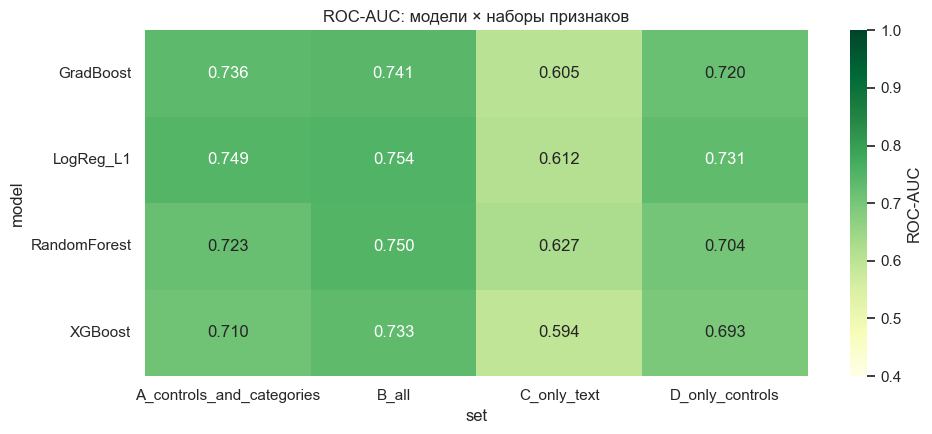

In [25]:
if "ROC_AUC" in results_table.columns:
    pivot = results_table.pivot(index="model", columns="set", values="ROC_AUC")
    plt.figure(figsize=(10, 4.5))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGn", vmin=0.4, vmax=1.0,
                cbar_kws={"label": "ROC-AUC"})
    plt.title("ROC-AUC: модели × наборы признаков")
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/ml_comparison.png", dpi=120)
    plt.show()

## 18. SHAP

Берём RandomForest на полном наборе признаков B.


In [26]:
# import shap

# best_feats = FEATURE_SETS["B_all"]
# X_shap = df_fit[best_feats].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)

# rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE,
#                             class_weight="balanced")
# rf.fit(X_shap, y)

# explainer = shap.TreeExplainer(rf)
# sv = explainer.shap_values(X_shap)

# if isinstance(sv, list):
#     sv = sv[1]
# sv = np.asarray(sv)
# if sv.ndim == 3:
#     sv = sv[:, :, 1]

# plt.figure()
# shap.summary_plot(sv, X_shap, show=False)
# plt.tight_layout()
# plt.savefig(f"{FIG_DIR}/shap_beeswarm.png", dpi=120, bbox_inches="tight")
# plt.show()

# plt.figure()
# shap.summary_plot(sv, X_shap, plot_type="bar", show=False)
# plt.tight_layout()
# plt.savefig(f"{FIG_DIR}/shap_bar.png", dpi=120, bbox_inches="tight")
# plt.show()

# mean_abs = (pd.Series(np.abs(sv).mean(axis=0), index=X_shap.columns)
#               .sort_values(ascending=False))
# mean_abs.round(4).to_frame("mean_|SHAP|")

## 19. Категориальный таргет: `funding_bucket`

Дробим `funding_ratio` на три класса:

- `0` — провал (<0.5 от цели)
- `1` — частичный успех (0.5 — 1.0)
- `2` — полный сбор / оверфандинг (≥1.0)

Эти классы естественно упорядочены, поэтому прогоняем две модели:
1. **Multinomial logit** (`sm.MNLogit`) — не использует порядок.
2. **Ordered logit / ordered probit** (`OrderedModel`) — учитывает порядок.


funding_bucket распределение:
  0 · <0.5 (провал)         : 550 (17.2%)
  1 · 0.5–1 (частичный)     : 1072 (33.6%)
  2 · >=1 (успех)           : 1570 (49.2%)


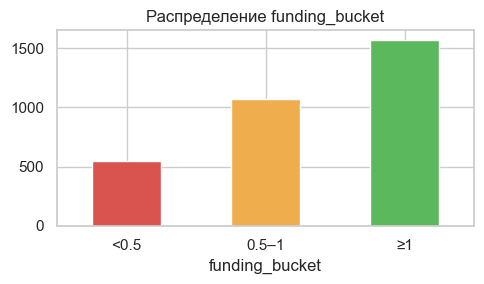

In [32]:
def make_funding_bucket(series: pd.Series) -> pd.Series:
    bins = [-np.inf, 0.5, 1.0, np.inf]
    labels = [0, 1, 2]  # 0: <0.5, 1: 0.5-1, 2: >=1
    return pd.cut(series, bins=bins, labels=labels, right=False).astype(int)


df_fit["funding_bucket"] = make_funding_bucket(df_fit["funding_ratio"].fillna(0))

bucket_counts = df_fit["funding_bucket"].value_counts().sort_index()
print("funding_bucket распределение:")
for k, v in bucket_counts.items():
    name = {0: "<0.5 (провал)", 1: "0.5–1 (частичный)", 2: ">=1 (успех)"}[k]
    print(f"  {k} · {name:22s}: {v:3d} ({v/len(df_fit)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 3))
bucket_counts.plot.bar(ax=ax, color=["#d9534f", "#f0ad4e", "#5cb85c"])
ax.set_xticklabels(["<0.5", "0.5–1", "≥1"], rotation=0)
ax.set_title("Распределение funding_bucket")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/funding_bucket_distribution.png", dpi=120)
plt.show()


In [71]:
def fit_mnlogit(X: pd.DataFrame, y: pd.Series, label: str):
    X = X.apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
    X = X.loc[:, X.nunique() > 1]
    X = sm.add_constant(X, has_constant="add")
    if X.shape[1] >= len(y):
        print(f"[{label}] пропуск: предикторов ({X.shape[1]}) >= наблюдений ({len(y)})")
        return None
    try:
        model = sm.MNLogit(y, X).fit(method="bfgs", disp=0, maxiter=500, cov_type="HC1")
    except Exception as e:
        print(f"[{label}] ошибка: {e}")
        return None
    print(f"══ MNLogit · {label} ══")
    print(f"  n={int(model.nobs)}  pseudo R²={model.prsquared:.3f}  "
          f"LLR p={model.llr_pvalue:.4g}  AIC={model.aic:.1f}")
    print(model.summary().as_text())
    return model


# Базовая категория = 0 (провал <0.5) — statsmodels берёт min(y) как базу.
# Блоки в summary: funding_bucket=1 (частичный vs провал),
#                  funding_bucket=2 (успех vs провал).
y_bucket = df_fit["funding_bucket"].astype(int)
feats_ball = [f for f in FEATURE_SETS["B_all"] if f in df_fit.columns]
mnlogit_model = fit_mnlogit(df_fit[feats_ball], y_bucket, "B_all")

══ MNLogit · B_all ══
  n=3192  pseudo R²=0.344  LLR p=0  AIC=4371.5
                          MNLogit Regression Results                          
Dep. Variable:         funding_bucket   No. Observations:                 3192
Model:                        MNLogit   Df Residuals:                     3138
Method:                           MLE   Df Model:                           52
Date:                Sun, 10 May 2026   Pseudo R-squ.:                  0.3443
Time:                        17:06:37   Log-Likelihood:                -2131.7
converged:                       True   LL-Null:                       -3250.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    funding_bucket=1       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                    7.3181      1.743      4.198      0.000       3.

In [87]:
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats

CAT_NAMES = {
    0: "Провал <0.5\n(базовая)",
    1: "Частичный\n0.5–1",
    2: "Успех\n≥1",
}

def _stars(p):
    if p <= 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.1:
        return "*"
    return ""


def _safe_predict_proba(model, X):
    pred = model.predict(X)

    if isinstance(pred, pd.DataFrame):
        proba = pred.copy()
    else:
        proba = pd.DataFrame(pred, index=X.index)

    y_vals = sorted(np.unique(model.model.endog.astype(int)))

    if proba.shape[1] == len(y_vals):
        proba.columns = y_vals
    else:
        proba.columns = list(range(proba.shape[1]))

    return proba


def _is_binary_series(s):
    vals = pd.Series(s).dropna().unique()
    vals = set(vals)
    return vals.issubset({0, 1}) or vals.issubset({0.0, 1.0, False, True})


def manual_ame_mnlogit(model, eps_scale=1e-5):
    if model is None:
        return None

    exog_names = list(model.model.exog_names)
    feat_names = [c for c in exog_names if c != "const"]

    X = pd.DataFrame(model.model.exog, columns=exog_names)

    base_proba = _safe_predict_proba(model, X)
    classes = list(base_proba.columns)

    ame = pd.DataFrame(index=feat_names, columns=classes, dtype=float)

    for feat in feat_names:
        x = X[feat]

        if _is_binary_series(x):
            X1 = X.copy()
            X0 = X.copy()
            X1[feat] = 1.0
            X0[feat] = 0.0
            p1 = _safe_predict_proba(model, X1)
            p0 = _safe_predict_proba(model, X0)
            diff = p1 - p0
            ame.loc[feat, :] = diff.mean(axis=0).values
        else:
            sd = x.std()
            if not np.isfinite(sd) or sd == 0:
                eps = eps_scale
            else:
                eps = eps_scale * sd

            X_plus = X.copy()
            X_minus = X.copy()
            X_plus[feat] = X_plus[feat] + eps
            X_minus[feat] = X_minus[feat] - eps
            p_plus = _safe_predict_proba(model, X_plus)
            p_minus = _safe_predict_proba(model, X_minus)
            deriv = (p_plus - p_minus) / (2 * eps)
            ame.loc[feat, :] = deriv.mean(axis=0).values

    return ame


def delta_method_se_mnlogit(model, eps_scale=1e-5, param_delta=1e-5, verbose=False):
    """
    AME + SE via delta method: Var(AME) = J @ Cov(beta) @ J'.
    Cov(beta) = model.cov_params() — HC1-robust if model fit with cov_type='HC1'.
    Jacobian J = d(AME)/d(beta) computed by central finite differences.
    """
    exog_names = list(model.model.exog_names)
    feat_names = [c for c in exog_names if c != "const"]
    X_np = model.model.exog  # (n, n_exog)
    feat_col = {name: i for i, name in enumerate(exog_names)}

    params_0 = model.params.values  # (n_exog, k_extra)
    n_exog, k_extra = params_0.shape
    J_cats = k_extra + 1

    def _predict_np(params_mat, exog_np):
        return model.model.predict(params_mat, exog=exog_np)  # (n, J_cats)

    def _ame_flat(params_mat):
        ame = np.zeros((len(feat_names), J_cats))
        for fi, feat in enumerate(feat_names):
            ci = feat_col[feat]
            x = X_np[:, ci]
            is_bin = set(np.unique(x)).issubset({0, 1, 0.0, 1.0})
            if is_bin:
                X1, X0 = X_np.copy(), X_np.copy()
                X1[:, ci] = 1.0
                X0[:, ci] = 0.0
                ame[fi] = (_predict_np(params_mat, X1) - _predict_np(params_mat, X0)).mean(0)
            else:
                sd = x.std()
                eps = eps_scale * sd if (np.isfinite(sd) and sd > 0) else eps_scale
                Xp, Xm = X_np.copy(), X_np.copy()
                Xp[:, ci] += eps
                Xm[:, ci] -= eps
                ame[fi] = ((_predict_np(params_mat, Xp) - _predict_np(params_mat, Xm)) / (2 * eps)).mean(0)
        return ame.flatten()

    ame_flat_0 = _ame_flat(params_0)
    n_ame = len(ame_flat_0)

    # Cov(beta): robust (HC1) if model was fit with cov_type='HC1'
    cov_beta = model.cov_params().values  # (n_exog*k_extra, n_exog*k_extra)
    n_beta = cov_beta.shape[0]

    # Jacobian in Fortran order: statsmodels MNLogit flattens params column-major
    # (all exog for category 1, then all exog for category 2, ...)
    Jac = np.zeros((n_ame, n_beta))
    col = 0
    for cat_j in range(k_extra):
        for exog_i in range(n_exog):
            p_plus = params_0.copy()
            p_minus = params_0.copy()
            p_plus[exog_i, cat_j] += param_delta
            p_minus[exog_i, cat_j] -= param_delta
            Jac[:, col] = (_ame_flat(p_plus) - _ame_flat(p_minus)) / (2 * param_delta)
            col += 1
            if verbose:
                print(f"  delta method: {col}/{n_beta}", end="\r")
    if verbose:
        print()

    var_ame = Jac @ cov_beta @ Jac.T
    se_flat = np.sqrt(np.maximum(np.diag(var_ame), 0))

    ame_mat = ame_flat_0.reshape(len(feat_names), J_cats)
    se_mat  = se_flat.reshape(len(feat_names), J_cats)

    with np.errstate(divide="ignore", invalid="ignore"):
        z = np.where(se_mat > 0, ame_mat / se_mat, 0.0)
    pval_mat = 2 * scipy_stats.norm.sf(np.abs(z))

    cats = list(range(J_cats))
    return (
        pd.DataFrame(ame_mat,  index=feat_names, columns=cats),
        pd.DataFrame(se_mat,   index=feat_names, columns=cats),
        pd.DataFrame(pval_mat, index=feat_names, columns=cats),
    )


def bootstrap_ame_mnlogit(model, B=200, seed=42, eps_scale=1e-5, verbose=True):
    if model is None:
        return None, None, None

    rng = np.random.default_rng(seed)

    exog_names = list(model.model.exog_names)
    feat_names = [c for c in exog_names if c != "const"]

    X_full = pd.DataFrame(model.model.exog, columns=exog_names)
    n = len(X_full)

    base_proba = _safe_predict_proba(model, X_full)
    classes = list(base_proba.columns)

    indiv_effects = {}

    for feat in feat_names:
        x = X_full[feat]

        if _is_binary_series(x):
            X1 = X_full.copy()
            X0 = X_full.copy()
            X1[feat] = 1.0
            X0[feat] = 0.0
            p1 = _safe_predict_proba(model, X1)
            p0 = _safe_predict_proba(model, X0)
            effects = p1 - p0
        else:
            sd = x.std()
            if not np.isfinite(sd) or sd == 0:
                eps = eps_scale
            else:
                eps = eps_scale * sd

            X_plus = X_full.copy()
            X_minus = X_full.copy()
            X_plus[feat] = X_plus[feat] + eps
            X_minus[feat] = X_minus[feat] - eps
            p_plus = _safe_predict_proba(model, X_plus)
            p_minus = _safe_predict_proba(model, X_minus)
            effects = (p_plus - p_minus) / (2 * eps)

        indiv_effects[feat] = effects.reset_index(drop=True)

    boot = {feat: np.zeros((B, len(classes))) for feat in feat_names}

    for b in range(B):
        idx = rng.integers(0, n, size=n)
        for feat in feat_names:
            eff = indiv_effects[feat].iloc[idx]
            boot[feat][b, :] = eff.mean(axis=0).values
        if verbose and (b + 1) % 50 == 0:
            print(f"Bootstrap {b + 1}/{B}")

    ame = pd.DataFrame(index=feat_names, columns=classes, dtype=float)
    se = pd.DataFrame(index=feat_names, columns=classes, dtype=float)
    pval = pd.DataFrame(index=feat_names, columns=classes, dtype=float)

    for feat in feat_names:
        arr = boot[feat]
        m = arr.mean(axis=0)
        s = arr.std(axis=0, ddof=1)
        ame.loc[feat, :] = m
        se.loc[feat, :] = s
        with np.errstate(divide="ignore", invalid="ignore"):
            z = np.where(s > 0, m / s, 0.0)
        p = 2 * scipy_stats.norm.sf(np.abs(z))
        pval.loc[feat, :] = p

    return ame, se, pval


def print_manual_mnlogit_ame_table(
    model,
    label="MNLogit",
    feature_labels=None,
    cat_names=None,
    B=200,
    seed=42,
    use_bootstrap=False,
    eps_scale=1e-5,
    feature_scales=None,
):
    """
    feature_scales : dict {feature_name: scale_factor}
        Множитель для отображения AME и SE при выводе.
        p-значения не меняются (тест остаётся на единичном сдвиге).
        Пример: {"rubert_positive": 0.01} — AME пересчитан на +1 п.п. вероятности.
    """
    if model is None:
        print(f"[{label}] модель не оценена.")
        return None

    cat_names = cat_names or CAT_NAMES
    feature_scales = feature_scales or {}

    if use_bootstrap:
        ame, se, pval = bootstrap_ame_mnlogit(
            model, B=B, seed=seed, eps_scale=eps_scale, verbose=False
        )
    else:
        # Delta method: Var(AME) = J @ Cov(beta) @ J'
        # Uses HC1-robust Cov(beta) from model (fit with cov_type='HC1')
        ame, se, pval = delta_method_se_mnlogit(model, eps_scale=eps_scale)

    if ame is None:
        print(f"[{label}] AME не посчитаны.")
        return None

    classes = list(ame.columns)
    feat_names = list(ame.index)

    NW = 36
    CW = 18
    ncols = len(classes)
    BAR = "─" * (NW + ncols * CW)
    EQ = "═" * (NW + ncols * CW)

    print(f"\n{EQ}")
    print(f"  AME · Мультиномиальный логит · {label}")
    print(f"{EQ}")

    h1 = f"  {''  :>{NW}}"
    for k in range(ncols):
        h1 += f"  ({k + 1}){' ' * (CW - 4)}"
    print(h1)

    h2 = f"  {''  :>{NW}}"
    for cat in classes:
        name = cat_names.get(cat, str(cat)).split("\n")[0]
        h2 += f"{name:^{CW}}"
    print(h2)

    h3 = f"  {'Переменные':<{NW}}"
    for cat in classes:
        parts = cat_names.get(cat, "").split("\n")
        name2 = parts[1] if len(parts) > 1 else ""
        h3 += f"{name2:^{CW}}"
    print(h3)

    h4 = f"  {''  :>{NW}}" + "".join(f"{'AME':^{CW}}" for _ in classes)
    print(h4)
    print("  " + BAR)

    scaled_feats = []

    for feat in feat_names:
        disp = (feature_labels or {}).get(feat, feat)
        if len(disp) > NW - 1:
            disp = disp[:NW - 2] + "…"

        scale = feature_scales.get(feat, 1.0)
        if scale != 1.0:
            scaled_feats.append((feat, scale))

        ame_row = f"  {disp:<{NW}}"
        se_row  = f"  {''  :>{NW}}"

        for cat in classes:
            val = ame.loc[feat, cat] * scale
            p   = pval.loc[feat, cat]
            s   = se.loc[feat, cat] * scale
            ame_row += f"{val:+.4f}{_stars(p):^{CW - 7}}"
            se_row  += f"{'(' + f'{s:.4f}' + ')':^{CW}}"

        print(ame_row)
        print(se_row)

    print("  " + BAR)
    print(f"  n = {int(model.nobs)}")
    if use_bootstrap:
        print(f"  В скобках — bootstrap SE, B={B}")
        print("  Примечание: bootstrap при фиксированных коэффициентах;")
        print("  SE отражают вариативность усреднения AME по наблюдениям.")
    else:
        print("  В скобках — SE по методу дельта (J @ HC1-Cov(β) @ J')")
    print("  *** p≤0.01, ** p<0.05, * p<0.1")
    if scaled_feats:
        print("  Масштабирование AME (p-значения — для единичного сдвига):")
        for feat, scale in scaled_feats:
            disp = (feature_labels or {}).get(feat, feat)
            print(f"    · {disp}: ×{scale} → интерпретация на Δ={scale} ед. шкалы")
    print(f"{EQ}\n")

    return {"ame": ame, "se": se, "pval": pval}


# ─────────────────────────────────────────────────────────────
# Множители масштабирования для признаков-вероятностей (0–1)
# 0.01 → AME интерпретируется как эффект на +1 п.п. вероятности
# ─────────────────────────────────────────────────────────────
FEATURE_SCALES = {

    # логарифмы → эффект на +1%
    "log_goal": np.log(1.01),
    "log_duration_days": np.log(1.01),
    "log_campaignsAmount": np.log(1.01),
    "log_description_word_count": np.log(1.01),

    # тональности → эффект на +10 п.п.
    "rubert_positive": 0.10,
    "rubert_negative": 0.10,
}

# ─────────────────────────────────────────────────────────────
# Запуск
# ─────────────────────────────────────────────────────────────

ame_ball = print_manual_mnlogit_ame_table(
    mnlogit_model,
    label="B_all",
    feature_labels=FEATURE_LABELS,
    cat_names=CAT_NAMES,
    B=200,
    seed=42,
    use_bootstrap=False,
    feature_scales=FEATURE_SCALES,
)



══════════════════════════════════════════════════════════════════════════════════════════
  AME · Мультиномиальный логит · B_all
══════════════════════════════════════════════════════════════════════════════════════════
                                        (1)                (2)                (3)              
                                         Провал <0.5        Частичный           Успех       
  Переменные                              (базовая)           0.5–1               ≥1        
                                             AME               AME               AME        
  ──────────────────────────────────────────────────────────────────────────────────────────
  Целевая сумма                       +0.0004    ***    +0.0004    ***    -0.0008    ***    
                                           (0.0000)          (0.0001)          (0.0001)     
  Длит. кампании, дни                 +0.0002    ***    +0.0011    ***    -0.0013    ***    
                               

In [88]:
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats

CAT_NAMES = {
    0: "Провал <0.5\n(базовая)",
    1: "Частичный\n0.5–1",
    2: "Успех\n≥1",
}

LN_1PCT = np.log(1.01) * 100  # ≈ 0.99503

FEATURE_INTERPRETATIONS = {
    # log-преобразованные (интерпретация: +1% исходного показателя)
    "log_goal":                   (LN_1PCT, "+1%"),
    "log_duration_days":          (LN_1PCT, "+1%"),
    "log_campaignsAmount":        (LN_1PCT, "+1%"),
    "log_description_word_count": (LN_1PCT, "+1%"),

    # счётные (raw): +1 единица
    "counts.newsCount":           (100,     "+1"),
    "counts.commentsCount":       (100,     "+1"),
    "reward_count":               (100,     "+1"),
    "readability_fog":            (100,     "+1"),

    # бинарные: 0→1
    "has_video":                  (100,     "0→1"),
    "has_gratitude":              (100,     "0→1"),
    "has_specific_sum":           (100,     "0→1"),

    # доли (fractions): +1 п.п. шкалы
    "social_score":               (1,       "+1 п.п."),
    "certainty_score":            (1,       "+1 п.п."),
    "uncertainty_score":          (1,       "+1 п.п."),
    "number_density":             (1,       "+1 п.п."),

    # отношение мы/я (raw scale): +1 единица
    "we_vs_i":                    (100,     "+1"),

    # тональности RuBERT (вероятности): +10 п.п.
    "rubert_positive":            (10,      "+10 п.п."),
    "rubert_negative":            (10,      "+10 п.п."),
}


def _get_interp(feat):
    """(scale, label) для перевода AME в эффект в п.п. при стандартном сдвиге."""
    if feat in FEATURE_INTERPRETATIONS:
        return FEATURE_INTERPRETATIONS[feat]
    if feat.startswith("cat_"):
        return (100, "0→1")
    # дефолт: считаем как +1 единица
    return (100, "+1")


def _stars(p):
    if p <= 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.1:
        return "*"
    return ""


def _safe_predict_proba(model, X):
    pred = model.predict(X)

    if isinstance(pred, pd.DataFrame):
        proba = pred.copy()
    else:
        proba = pd.DataFrame(pred, index=X.index)

    y_vals = sorted(np.unique(model.model.endog.astype(int)))

    if proba.shape[1] == len(y_vals):
        proba.columns = y_vals
    else:
        proba.columns = list(range(proba.shape[1]))

    return proba


def _is_binary_series(s):
    vals = pd.Series(s).dropna().unique()
    vals = set(vals)
    return vals.issubset({0, 1}) or vals.issubset({0.0, 1.0, False, True})


def manual_ame_mnlogit(model, eps_scale=1e-5):
    if model is None:
        return None

    exog_names = list(model.model.exog_names)
    feat_names = [c for c in exog_names if c != "const"]

    X = pd.DataFrame(model.model.exog, columns=exog_names)

    base_proba = _safe_predict_proba(model, X)
    classes = list(base_proba.columns)

    ame = pd.DataFrame(index=feat_names, columns=classes, dtype=float)

    for feat in feat_names:
        x = X[feat]

        if _is_binary_series(x):
            X1 = X.copy()
            X0 = X.copy()
            X1[feat] = 1.0
            X0[feat] = 0.0
            p1 = _safe_predict_proba(model, X1)
            p0 = _safe_predict_proba(model, X0)
            diff = p1 - p0
            ame.loc[feat, :] = diff.mean(axis=0).values
        else:
            sd = x.std()
            if not np.isfinite(sd) or sd == 0:
                eps = eps_scale
            else:
                eps = eps_scale * sd

            X_plus = X.copy()
            X_minus = X.copy()
            X_plus[feat] = X_plus[feat] + eps
            X_minus[feat] = X_minus[feat] - eps
            p_plus = _safe_predict_proba(model, X_plus)
            p_minus = _safe_predict_proba(model, X_minus)
            deriv = (p_plus - p_minus) / (2 * eps)
            ame.loc[feat, :] = deriv.mean(axis=0).values

    return ame


def delta_method_se_mnlogit(model, eps_scale=1e-5, param_delta=1e-4, verbose=False):
    """
    AME + SE via delta method: Var(AME) = J @ Cov(beta) @ J'.
    Cov(beta) = model.cov_params() — HC1-robust if model fit with cov_type='HC1'.
    Jacobian J = d(AME)/d(beta) computed by central finite differences.
    """
    exog_names = list(model.model.exog_names)
    feat_names = [c for c in exog_names if c != "const"]
    X_np = model.model.exog
    feat_col = {name: i for i, name in enumerate(exog_names)}

    params_0 = model.params.values
    n_exog, k_extra = params_0.shape
    J_cats = k_extra + 1

    def _predict_np(params_mat, exog_np):
        return model.model.predict(params_mat, exog=exog_np)

    def _ame_flat(params_mat):
        ame = np.zeros((len(feat_names), J_cats))
        for fi, feat in enumerate(feat_names):
            ci = feat_col[feat]
            x = X_np[:, ci]
            is_bin = set(np.unique(x)).issubset({0, 1, 0.0, 1.0})
            if is_bin:
                X1, X0 = X_np.copy(), X_np.copy()
                X1[:, ci] = 1.0
                X0[:, ci] = 0.0
                ame[fi] = (_predict_np(params_mat, X1) - _predict_np(params_mat, X0)).mean(0)
            else:
                sd = x.std()
                eps = eps_scale * sd if (np.isfinite(sd) and sd > 0) else eps_scale
                Xp, Xm = X_np.copy(), X_np.copy()
                Xp[:, ci] += eps
                Xm[:, ci] -= eps
                ame[fi] = ((_predict_np(params_mat, Xp) - _predict_np(params_mat, Xm)) / (2 * eps)).mean(0)
        return ame.flatten()

    ame_flat_0 = _ame_flat(params_0)
    n_ame = len(ame_flat_0)

    cov_beta = model.cov_params().values
    n_beta = cov_beta.shape[0]

    # Jacobian: statsmodels MNLogit flattens params в F-order
    Jac = np.zeros((n_ame, n_beta))
    col = 0
    for cat_j in range(k_extra):
        for exog_i in range(n_exog):
            p_plus = params_0.copy()
            p_minus = params_0.copy()
            p_plus[exog_i, cat_j] += param_delta
            p_minus[exog_i, cat_j] -= param_delta
            Jac[:, col] = (_ame_flat(p_plus) - _ame_flat(p_minus)) / (2 * param_delta)
            col += 1
            if verbose:
                print(f"  delta method: {col}/{n_beta}", end="\r")
    if verbose:
        print()

    var_ame = Jac @ cov_beta @ Jac.T
    se_flat = np.sqrt(np.maximum(np.diag(var_ame), 0))

    ame_mat = ame_flat_0.reshape(len(feat_names), J_cats)
    se_mat  = se_flat.reshape(len(feat_names), J_cats)

    with np.errstate(divide="ignore", invalid="ignore"):
        z = np.where(se_mat > 0, ame_mat / se_mat, 0.0)
    pval_mat = 2 * scipy_stats.norm.sf(np.abs(z))

    cats = list(range(J_cats))
    return (
        pd.DataFrame(ame_mat,  index=feat_names, columns=cats),
        pd.DataFrame(se_mat,   index=feat_names, columns=cats),
        pd.DataFrame(pval_mat, index=feat_names, columns=cats),
    )


def bootstrap_ame_mnlogit(model, B=200, seed=42, eps_scale=1e-5, verbose=True):
    """
    Внимание: ресемплирует наблюдения при ФИКСИРОВАННЫХ β.
    Это НЕ полный bootstrap AME (не учитывает сэмплинговую вариативность β).
    Для корректных HC1-SE используй delta_method_se_mnlogit().
    """
    if model is None:
        return None, None, None

    rng = np.random.default_rng(seed)

    exog_names = list(model.model.exog_names)
    feat_names = [c for c in exog_names if c != "const"]

    X_full = pd.DataFrame(model.model.exog, columns=exog_names)
    n = len(X_full)

    base_proba = _safe_predict_proba(model, X_full)
    classes = list(base_proba.columns)

    indiv_effects = {}

    for feat in feat_names:
        x = X_full[feat]

        if _is_binary_series(x):
            X1 = X_full.copy()
            X0 = X_full.copy()
            X1[feat] = 1.0
            X0[feat] = 0.0
            p1 = _safe_predict_proba(model, X1)
            p0 = _safe_predict_proba(model, X0)
            effects = p1 - p0
        else:
            sd = x.std()
            if not np.isfinite(sd) or sd == 0:
                eps = eps_scale
            else:
                eps = eps_scale * sd

            X_plus = X_full.copy()
            X_minus = X_full.copy()
            X_plus[feat] = X_plus[feat] + eps
            X_minus[feat] = X_minus[feat] - eps
            p_plus = _safe_predict_proba(model, X_plus)
            p_minus = _safe_predict_proba(model, X_minus)
            effects = (p_plus - p_minus) / (2 * eps)

        indiv_effects[feat] = effects.reset_index(drop=True)

    boot = {feat: np.zeros((B, len(classes))) for feat in feat_names}

    for b in range(B):
        idx = rng.integers(0, n, size=n)
        for feat in feat_names:
            eff = indiv_effects[feat].iloc[idx]
            boot[feat][b, :] = eff.mean(axis=0).values
        if verbose and (b + 1) % 50 == 0:
            print(f"Bootstrap {b + 1}/{B}")

    ame = pd.DataFrame(index=feat_names, columns=classes, dtype=float)
    se = pd.DataFrame(index=feat_names, columns=classes, dtype=float)
    pval = pd.DataFrame(index=feat_names, columns=classes, dtype=float)

    for feat in feat_names:
        arr = boot[feat]
        m = arr.mean(axis=0)
        s = arr.std(axis=0, ddof=1)
        ame.loc[feat, :] = m
        se.loc[feat, :] = s
        with np.errstate(divide="ignore", invalid="ignore"):
            z = np.where(s > 0, m / s, 0.0)
        p = 2 * scipy_stats.norm.sf(np.abs(z))
        pval.loc[feat, :] = p

    return ame, se, pval


def print_manual_mnlogit_ame_table(
    model,
    label="MNLogit",
    feature_labels=None,
    cat_names=None,
    use_bootstrap=False,
    eps_scale=1e-5,
    B=200,
    seed=42,
):
    """
    AME мультиномиального логита, выраженные сразу в процентных пунктах
    при стандартном сдвиге для каждого типа переменной:
        +1%      — для log-переменных (рост исходной X на 1%)
        +1       — для счётных/индексов
        0→1      — для бинарных
        +1 п.п.  — для долей (0–1)
        +10 п.п. — для тональностей RuBERT
    Значения готовы к копированию в текст работы.

    SE рассчитаны методом дельта с HC1-робастной Cov(β) (если модель
    оценена с cov_type='HC1'). p-значения соответствуют исходному AME
    (масштабирование не меняет z/p).
    """
    if model is None:
        print(f"[{label}] модель не оценена.")
        return None

    cat_names = cat_names or CAT_NAMES

    if use_bootstrap:
        ame, se, pval = bootstrap_ame_mnlogit(
            model, B=B, seed=seed, eps_scale=eps_scale, verbose=False
        )
    else:
        ame, se, pval = delta_method_se_mnlogit(model, eps_scale=eps_scale)

    if ame is None:
        print(f"[{label}] AME не посчитаны.")
        return None

    classes = list(ame.columns)
    feat_names = list(ame.index)

    NW = 42
    CW = 16
    ncols = len(classes)
    BAR = "─" * (NW + ncols * CW)
    EQ = "═" * (NW + ncols * CW)

    print(f"\n{EQ}")
    print(f"  AME · Мультиномиальный логит · {label}  (значения в п.п.)")
    print(f"{EQ}")

    h2 = f"  {''  :>{NW}}"
    for cat in classes:
        name = cat_names.get(cat, str(cat)).split("\n")[0]
        h2 += f"{name:^{CW}}"
    print(h2)

    h3 = f"  {'Переменные':<{NW}}"
    for cat in classes:
        parts = cat_names.get(cat, "").split("\n")
        name2 = parts[1] if len(parts) > 1 else ""
        h3 += f"{name2:^{CW}}"
    print(h3)

    h4 = f"  {''  :>{NW}}" + "".join(f"{'AME, п.п.':^{CW}}" for _ in classes)
    print(h4)
    print("  " + BAR)

    ame_pp = ame.copy() * 0.0
    se_pp  = se.copy()  * 0.0

    for feat in feat_names:
        scale, suffix = _get_interp(feat)
        pretty = (feature_labels or {}).get(feat, feat)
        disp = f"{pretty}, {suffix}" if suffix else pretty
        if len(disp) > NW - 1:
            disp = disp[: NW - 2] + "…"

        ame_row = f"  {disp:<{NW}}"
        se_row  = f"  {''  :>{NW}}"

        for cat in classes:
            val = ame.loc[feat, cat] * scale
            s   = se.loc[feat, cat]  * scale
            p   = pval.loc[feat, cat]

            ame_pp.loc[feat, cat] = val
            se_pp.loc[feat, cat]  = s

            cell    = f"{val:+.3f}{_stars(p)}"
            se_cell = f"({s:.3f})"
            ame_row += f"{cell:^{CW}}"
            se_row  += f"{se_cell:^{CW}}"

        print(ame_row)
        print(se_row)

    print("  " + BAR)
    print(f"  n = {int(model.nobs)}")
    print("  AME выражены в процентных пунктах вероятности при сдвиге, указанном после названия:")
    print("    +1%       — рост исходной переменной на 1% (для log-переменных)")
    print("    +1        — рост на 1 единицу (счётные, индекс читабельности, отношение мы/я)")
    print("    0→1       — наличие признака против отсутствия (бинарные)")
    print("    +1 п.п.   — рост доли на 1 процентный пункт (доли 0–1)")
    print("    +10 п.п.  — рост вероятности тональности на 10 п.п. (RuBERT)")
    if use_bootstrap:
        print(f"  В скобках — bootstrap SE по наблюдениям, B={B} (β фиксированы).")
    else:
        print("  В скобках — SE по методу дельта на HC1-Cov(β).")
    print("  *** p≤0.01, ** p<0.05, * p<0.1")
    print(f"{EQ}\n")

    return {
        "ame_pp":  ame_pp,
        "se_pp":   se_pp,
        "pval":    pval,
        "ame_raw": ame,
        "se_raw":  se,
    }


# ─────────────────────────────────────────────────────────────
# Запуск
# ─────────────────────────────────────────────────────────────

ame_ball = print_manual_mnlogit_ame_table(
    mnlogit_model,
    label="B_all",
    feature_labels=FEATURE_LABELS,
    cat_names=CAT_NAMES,
    use_bootstrap=False,
)


══════════════════════════════════════════════════════════════════════════════════════════
  AME · Мультиномиальный логит · B_all  (значения в п.п.)
══════════════════════════════════════════════════════════════════════════════════════════
                                              Провал <0.5      Частичный         Успех      
  Переменные                                   (базовая)         0.5–1             ≥1       
                                               AME, п.п.       AME, п.п.       AME, п.п.    
  ──────────────────────────────────────────────────────────────────────────────────────────
  Целевая сумма, +1%                           +0.041***       +0.040***       -0.081***    
                                                (0.004)         (0.008)         (0.008)     
  Длит. кампании, дни, +1%                     +0.023***       +0.109***       -0.132***    
                                                (0.006)         (0.012)         (0.013)     
  Новостей, +1 

### 19.2 Ordered Logit / Ordered Probit

Обе модели используют порядок классов (0 < 1 < 2). Отличаются только распределением латентной переменной: logit → логистическое, probit → нормальное. Сравниваем по AIC / log-likelihood.


In [ ]:
def fit_ordered(X: pd.DataFrame, y: pd.Series, distr: str, label: str):
    X = (
        X.apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .astype(float)
    )

    X = X.loc[:, X.nunique() > 1]

    if X.shape[1] >= len(y) - 3:
        print(f"[{label}/{distr}] пропуск: слишком мало наблюдений")
        return None

    try:
        model = OrderedModel(y, X, distr=distr)
        result = model.fit(method="bfgs", disp=False, maxiter=300, cov_type="HC1")
    except Exception as e:
        print(f"[{label}/{distr}] ошибка: {e}")
        return None

    print(f"\n\n{'=' * 80}")
    print(f"Ordered {distr.upper()} · {label}")
    print(f"{'=' * 80}")

    print(result.summary())

    return result


ordered_results = {}

feats = [f for f in FEATURE_SETS["B_all"] if f in df_fit.columns]

for distr in ("logit", "probit"):
    m = fit_ordered(
        df_fit[feats],
        y_bucket,
        distr=distr,
        label="B_all"
    )

    if m is not None:
        ordered_results[distr] = m


if len(ordered_results) == 2:
    print("\n\n" + "─" * 80)
    print("Ordered Logit vs Ordered Probit")
    print("─" * 80)

    comparison = pd.DataFrame({
        "distr": list(ordered_results.keys()),
        "AIC": [m.aic for m in ordered_results.values()],
        "BIC": [m.bic for m in ordered_results.values()],
        "LLF": [m.llf for m in ordered_results.values()],
        "nobs": [int(m.nobs) for m in ordered_results.values()],
    })

    print(comparison.round(3).to_string(index=False))

[B_all/logit] ошибка: zero-size array to reduction operation maximum which has no identity
[B_all/probit] ошибка: zero-size array to reduction operation maximum which has no identity


In [68]:
def fit_ordered(X: pd.DataFrame, y: pd.Series, distr: str, label: str):
    X = (
        X.apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .astype(float)
    )

    X = X.loc[:, X.nunique() > 1]

    if X.shape[1] >= len(y) - 3:
        print(f"[{label}/{distr}] пропуск: слишком мало наблюдений")
        return None

    try:
        model = OrderedModel(y, X, distr=distr)
        result = model.fit(method="bfgs", disp=False, maxiter=300, cov_type="HC1")

        # LL-null вручную: модель только с порогами / без предикторов
        counts = y.value_counts().sort_index()
        probs = counts / counts.sum()

        ll_null = np.sum(counts * np.log(probs))

        pseudo_r2 = 1 - (result.llf / ll_null)

        result.llnull = ll_null
        result.pseudo_r2 = pseudo_r2

    except Exception as e:
        print(f"[{label}/{distr}] ошибка: {e}")
        return None

    print(f"\n\n{'=' * 80}")
    print(f"Ordered {distr.upper()} · {label}")
    print(f"{'=' * 80}")

    print(result.summary())

    print("\nModel fit statistics:")
    print(f"LLF         : {result.llf:.3f}")
    print(f"LL-null     : {result.llnull:.3f}")
    print(f"Pseudo R²   : {result.pseudo_r2:.4f}")
    print(f"AIC         : {result.aic:.3f}")
    print(f"BIC         : {result.bic:.3f}")

    return result


ordered_results = {}

for feature_label, feature_list in FEATURE_SETS.items():

    feats = [f for f in feature_list if f in df_fit.columns]

    if len(feats) == 0:
        print(f"[{feature_label}] пропуск: нет признаков")
        continue

    ordered_results[feature_label] = {}

    for distr in ("logit", "probit"):

        m = fit_ordered(
            df_fit[feats],
            y_bucket,
            distr=distr,
            label=feature_label
        )

        if m is not None:
            ordered_results[feature_label][distr] = m




Ordered LOGIT · A_controls_and_categories
                             OrderedModel Results                             
Dep. Variable:         funding_bucket   Log-Likelihood:                -2618.4
Model:                   OrderedModel   AIC:                             5271.
Method:            Maximum Likelihood   BIC:                             5374.
Date:                Sun, 10 May 2026                                         
Time:                        15:33:25                                         
No. Observations:                3192                                         
Df Residuals:                    3175                                         
Df Model:                          15                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
log_goal                           

## 20. Train/test split - все, что ниже - не идет в основную работу

ML-модели выше оцениваются кросс-валидацией. Для последующих моделей (GAM, квантильная регрессия, интеракции) делаем один сплит 80/20.


In [30]:
TRAIN_SIZE = 0.8
_feats_all = [f for f in FEATURE_SETS["B_all"] if f in df_fit.columns]

train_idx, test_idx = tts(
    np.arange(len(df_fit)),
    train_size=TRAIN_SIZE,
    random_state=RANDOM_STATE,
    stratify=df_fit[TARGET_COL],
)
df_train = df_fit.iloc[train_idx].reset_index(drop=True)
df_test  = df_fit.iloc[test_idx].reset_index(drop=True)

y_train  = df_train[TARGET_COL].astype(int)
y_test   = df_test[TARGET_COL].astype(int)

print(f"train: {len(df_train)}  (успешных: {int(y_train.sum())})")
print(f"test : {len(df_test)}   (успешных: {int(y_test.sum())})")

train: 2553  (успешных: 1256)
test : 639   (успешных: 314)


In [59]:
# ── Ordered Logit / Probit: спецификации A, C, D ───────────────────────
# A: контроли + категории (без текста)
# C: контроли + текст (без категорий)
# D: контроли + текст + is_charity

ordered_specs = {
    "A_controls_and_categories": [f for f in FEATURE_SETS["A_controls_and_categories"] if f in df_fit.columns],
    "C_no_cat":                  [f for f in FEATURE_SETS["C_no_cat"]                  if f in df_fit.columns],
    "D_charity":                 [f for f in FEATURE_SETS["D_charity"]                 if f in df_fit.columns],
}

ordered_results_all = {}   # {(label, distr): result}

for label, feats in ordered_specs.items():
    for distr in ("logit", "probit"):
        m = fit_ordered(df_fit[feats], y_bucket, distr=distr, label=label)
        if m is not None:
            ordered_results_all[(label, distr)] = m

# ── Сводная таблица метрик ───────────────────────────────────────────────
if ordered_results_all:
    rows = []
    for (label, distr), m in ordered_results_all.items():
        rows.append({
            "Спецификация": label,
            "Модель":       distr,
            "AIC":          round(m.aic, 1),
            "BIC":          round(m.bic, 1),
            "LLF":          round(m.llf, 2),
            "Pseudo R²":    round(m.pseudo_r2, 4),
            "n":            int(m.nobs),
        })
    print("\n" + "═" * 80)
    print("Сводная таблица: Ordered Logit / Probit по спецификациям")
    print("═" * 80)
    print(pd.DataFrame(rows).to_string(index=False))



Ordered LOGIT · A_controls_and_categories
                             OrderedModel Results                             
Dep. Variable:         funding_bucket   Log-Likelihood:                -2618.4
Model:                   OrderedModel   AIC:                             5271.
Method:            Maximum Likelihood   BIC:                             5374.
Date:                Sun, 10 May 2026                                         
Time:                        14:52:22                                         
No. Observations:                3192                                         
Df Residuals:                    3175                                         
Df Model:                          15                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
log_goal                           

In [60]:
# ── Сравнение коэффициентов β: Ordered Logit B_all vs D_charity ─────────────

def compare_ordered_coefs(model_b, model_d,
                           label_b="B_all", label_d="D_charity",
                           feature_labels=None, alpha=0.05):
    """
    Таблица сравнения коэффициентов β двух Ordered Logit моделей.
    Пороговые параметры (cut-points) выводятся отдельно внизу.
    """
    def extract(model):
        params = model.params
        bse    = model.bse
        tvals  = model.tvalues
        pvals  = model.pvalues
        return pd.DataFrame({
            "coef": params,
            "se":   bse,
            "z":    tvals,
            "p":    pvals,
        })

    df_b = extract(model_b)
    df_d = extract(model_d)

    def stars(p):
        if p <= 0.01: return "***"
        if p < 0.05:  return "**"
        if p < 0.1:   return "*"
        return ""

    def fmt(coef, p):
        s = f"{coef:+.4f}{stars(p)}"
        return s

    # Разделяем предикторы и пороговые параметры
    thresh_keywords = ("/",)   # OrderedModel называет cut-points как "0/1", "1/2"

    def is_thresh(name):
        return any(k in name for k in thresh_keywords)

    pred_b = df_b[~df_b.index.map(is_thresh)]
    pred_d = df_d[~df_d.index.map(is_thresh)]
    thr_b  = df_b[ df_b.index.map(is_thresh)]
    thr_d  = df_d[ df_d.index.map(is_thresh)]

    # Общие предикторы (есть в обеих)
    common = pred_b.index.intersection(pred_d.index)
    only_b = pred_b.index.difference(pred_d.index)
    only_d = pred_d.index.difference(pred_b.index)

    NW, CW = 34, 22
    SEP = "─" * (NW + 2 * CW)
    EQ  = "═" * (NW + 2 * CW)
    

    print(f"\n{EQ}")
    print(f"  Ordered Logit — сравнение коэффициентов β")
    print(f"  {label_b}  vs  {label_d}")
    print(f"{EQ}")
    print(f"  {'Признак':<{NW}} {label_b:^{CW}} {label_d:^{CW}}")
    print(f"  {'':>{NW}} {'coef (SE)':^{CW}} {'coef (SE)':^{CW}}")
    print("  " + SEP)

    def print_row(name, row_b, row_d):
        lbl = (feature_labels or {}).get(name, name)
        if len(lbl) > NW - 1:
            lbl = lbl[:NW-2] + "…"

        def cell(row):
            if row is None:
                return f"{'—':^{CW}}"
            v = fmt(row["coef"], row["p"])
            s = f"({row['se']:.4f})"
            return f"{v:>{CW//2}}{s:>{CW//2}}"

        print(f"  {lbl:<{NW}} {cell(row_b)} {cell(row_d)}")

    # Общие признаки
    for name in common:
        print_row(name,
                  pred_b.loc[name],
                  pred_d.loc[name])

    # Только в B
    if len(only_b):
        print(f"  {'─ только в ' + label_b + ' ─':<{NW + 2*CW}}")
        for name in only_b:
            print_row(name, pred_b.loc[name], None)

    # Только в D
    if len(only_d):
        print(f"  {'─ только в ' + label_d + ' ─':<{NW + 2*CW}}")
        for name in only_d:
            print_row(name, None, pred_d.loc[name])

    # Пороги
    print("  " + SEP)
    print(f"  {'Пороговые параметры (cut-points)':<{NW}} {label_b:^{CW}} {label_d:^{CW}}")
    print("  " + SEP)
    thr_names = thr_b.index.union(thr_d.index)
    for name in thr_names:
        rb = thr_b.loc[name] if name in thr_b.index else None
        rd = thr_d.loc[name] if name in thr_d.index else None
        print_row(name, rb, rd)

    print("  " + SEP)
    print(f"  n(B) = {int(model_b.nobs)}   n(D) = {int(model_d.nobs)}")
    print(f"  AIC(B) = {model_b.aic:.1f}   AIC(D) = {model_d.aic:.1f}")
    print(f"  Pseudo R²(B) = {model_b.pseudo_r2:.4f}   "
          f"Pseudo R²(D) = {model_d.pseudo_r2:.4f}")
    print(f"  *** p≤0.01, ** p<0.05, * p<0.1")
    print(f"{EQ}\n")


# ── Запуск: Ordered Logit B_all vs D_charity ─────────────────────────────────
_m_b = ordered_results.get("logit")
_m_d = ordered_results_all.get(("D_charity", "logit"))

if _m_b and _m_d:
    compare_ordered_coefs(
        _m_b, _m_d,
        label_b="B_all",
        label_d="D_charity",
        feature_labels=FEATURE_LABELS,
    )
else:
    print("Одна из моделей не оценена. Проверьте ordered_results и ordered_results_all.")



══════════════════════════════════════════════════════════════════════════════
  Ordered Logit — сравнение коэффициентов β
  B_all  vs  D_charity
══════════════════════════════════════════════════════════════════════════════
  Признак                                    B_all                D_charity       
                                           coef (SE)              coef (SE)       
  ──────────────────────────────────────────────────────────────────────────────
  Целевая сумма                       -0.4275***   (0.0407)  -0.4215***   (0.0404)
  Длит. кампании, дни                 -0.6149***   (0.0626)  -0.5761***   (0.0615)
  Новостей                            +0.0442***   (0.0062)  +0.0440***   (0.0062)
  Комментариев                        +0.0122***   (0.0036)  +0.0135***   (0.0037)
  Кампаний автора                     +0.4888***   (0.0470)  +0.4859***   (0.0467)
  Есть видео                            +0.1524*   (0.0805)    +0.1475*   (0.0795)
  Вознаграждений             

## 22. Квантильная регрессия

Квантильная регрессия оценивает условные **квантили** `Q_τ(y | X)`.

Бежим по квантилям τ ∈ {0.1, 0.25, 0.5, 0.75, 0.9} на непрерывном `funding_ratio` и смотрим, как коэффициенты меняются вдоль распределения.


In [32]:
df_fit["log_funding_ratio"] = np.log1p(df_fit["funding_ratio"].clip(lower=0))

QUANT_FEATURES = [c for c in [
    "log_goal", "log_duration_days", "log_text_length", "has_video",
    "social_score", "gratitude_score", "we_ratio", "i_ratio",
    "certainty_score", "uncertainty_score",
    "number_density", "readability_fog",
    "rubert_positive", "rubert_negative",
] if c in df_fit.columns]

X_q = df_fit[QUANT_FEATURES].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
X_q = X_q.loc[:, X_q.nunique() > 1]
X_q = sm.add_constant(X_q, has_constant="add")
y_q = df_fit["log_funding_ratio"]

taus = [0.1, 0.25, 0.5, 0.75, 0.9]
quant_coefs = {}
for tau in taus:
    try:
        m = QuantReg(y_q, X_q).fit(q=tau, max_iter=2000)
        quant_coefs[tau] = m.params
    except Exception as e:
        print(f"tau={tau}: ошибка {e}")

coef_table = pd.DataFrame(quant_coefs).round(3)
print("Коэффициенты по квантилям:")
print(coef_table.to_string())

Коэффициенты по квантилям:
                    0.10   0.25   0.50   0.75   0.90
const              1.437  1.716  1.851  1.233  1.613
log_goal          -0.059 -0.056 -0.055 -0.024 -0.037
log_duration_days -0.009 -0.050 -0.065 -0.025 -0.044
has_video          0.071  0.066  0.044  0.018  0.039
social_score      -4.291 -4.709 -3.719 -1.097 -1.533
gratitude_score    6.783  7.175  4.065  1.326  7.175
we_ratio           0.371  0.791  0.273  0.142  0.370
i_ratio            1.421  0.245 -1.020 -0.341 -0.932
certainty_score    1.649  0.772 -1.023  0.656  3.183
uncertainty_score  2.671  3.100  4.940  2.234  4.869
number_density    -1.324 -1.317 -1.175 -0.365 -0.508
readability_fog   -0.005 -0.005 -0.006 -0.002 -0.003
rubert_positive   -0.609 -0.621 -0.310 -0.128 -0.250
rubert_negative   -0.726 -0.513 -0.216 -0.098 -0.208


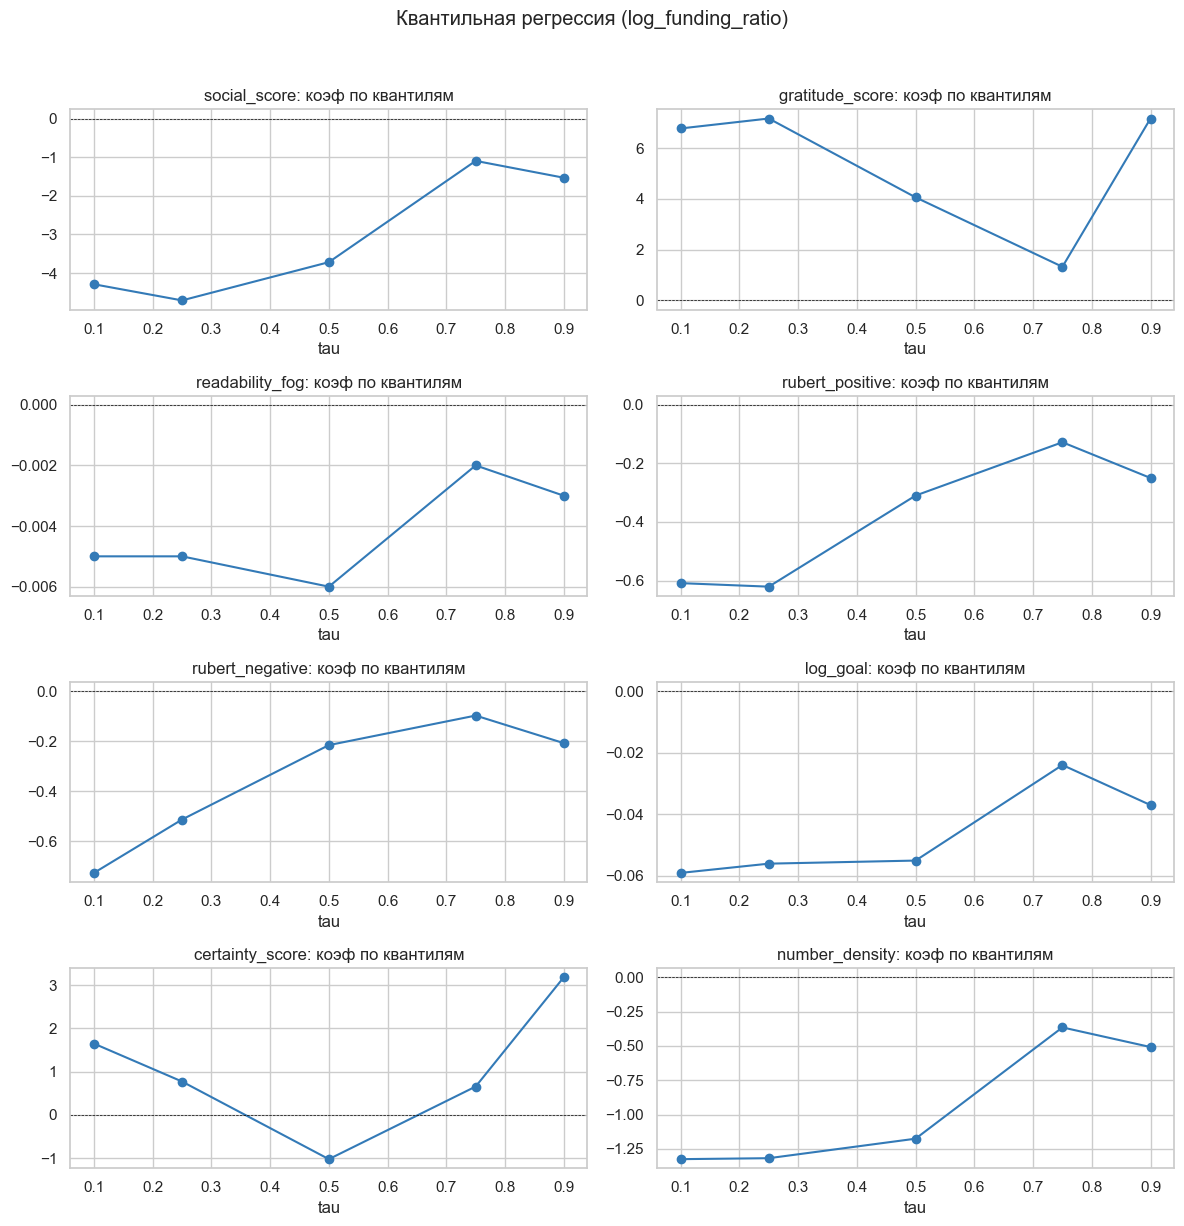

In [33]:
plot_feats = [c for c in ["social_score", "gratitude_score", "readability_fog",
                          "rubert_positive", "rubert_negative", "log_goal",
                          "certainty_score", "number_density"]
              if c in coef_table.index]

ncol = 2
nrow = int(np.ceil(len(plot_feats) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(6 * ncol, 3 * nrow))
for ax, f in zip(axes.flat, plot_feats):
    vals = coef_table.loc[f]
    ax.plot(vals.index, vals.values, marker="o", color="#337ab7")
    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.set_title(f"{f}: коэф по квантилям")
    ax.set_xlabel("tau")
for ax in axes.flat[len(plot_feats):]:
    ax.axis("off")
plt.suptitle("Квантильная регрессия (log_funding_ratio)", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/quantile_coefs.png", dpi=120, bbox_inches="tight")
plt.show()

## 23. Двухчастная модель

1. **Часть 1 (селекция)**
   `P(funding_ratio ≥ 1 | X)` — логит/пробит.
   По сути это `is_successful`.

2. **Часть 2 (интенсивность)**
   Среди `funding_ratio ≥ 1`:
   `E[log(funding_ratio) | funding_ratio ≥ 1, X]` — OLS на лог-шкале.

Дополнительно смотрим две подгруппы:

- **Среди неуспешных** (`funding_ratio < 1`): что коррелирует с приближением к 1 (OLS на `funding_ratio` в [0, 1)).
- **Среди успешных** (`funding_ratio ≥ 1`): что связано с оверфандингом (OLS на `log(funding_ratio)`, где 0 ⇔ ровно 100%).


всего: 3192
  funding_ratio < 1 : 1622 (50.8%)
  funding_ratio ≥ 1 : 1570 (49.2%)


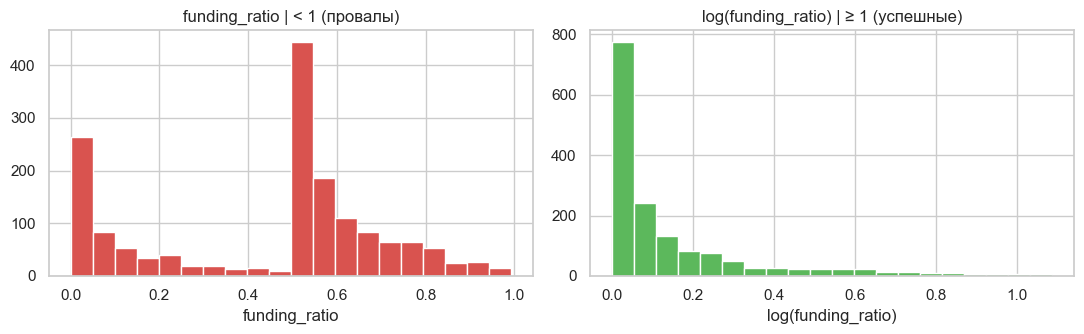

In [34]:
df_fit["funding_ratio"] = df_fit["funding_ratio"].fillna(0).clip(lower=0)
df_fit["success_binary"] = (df_fit["funding_ratio"] >= 1).astype(int)

n_total = len(df_fit)
n_succ = int(df_fit["success_binary"].sum())
n_fail = n_total - n_succ
print(f"всего: {n_total}")
print(f"  funding_ratio < 1 : {n_fail} ({n_fail/n_total*100:.1f}%)")
print(f"  funding_ratio ≥ 1 : {n_succ} ({n_succ/n_total*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(df_fit.loc[df_fit["success_binary"] == 0, "funding_ratio"],
             bins=20, color="#d9534f", edgecolor="white")
axes[0].set_title("funding_ratio | < 1 (провалы)")
axes[0].set_xlabel("funding_ratio")

succ_vals = df_fit.loc[df_fit["success_binary"] == 1, "funding_ratio"]
axes[1].hist(np.log(succ_vals.clip(lower=1e-6)),
             bins=20, color="#5cb85c", edgecolor="white")
axes[1].set_title("log(funding_ratio) | ≥ 1 (успешные)")
axes[1].set_xlabel("log(funding_ratio)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/hurdle_distributions.png", dpi=120)
plt.show()


### 23.1 Часть 1 — селекция: `P(funding_ratio ≥ 1 | X)`

Логит на всех `n` наблюдениях. Набор признаков — `B_all` (контроли + категории + годы + текст).


In [35]:
def fit_hurdle_part1(df, feats, label="B_all"):
    X = df[feats].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
    X = X.loc[:, X.nunique() > 1]
    X = sm.add_constant(X, has_constant="add")
    y = df["success_binary"].astype(int)
    if X.shape[1] >= len(y):
        print(f"[part1/{label}] пропуск: предикторов ({X.shape[1]}) ≥ наблюдений ({len(y)})")
        return None
        
    try:
        m = sm.Logit(y, X).fit(disp=0, cov_type="HC1", maxiter=300)
    except Exception as e:
        print(f"[part1/{label}] ошибка: {e}")
        return None
    print(f"\n══ Hurdle · Part 1 (selection) · {label} ══")
    print(f"  n={int(m.nobs)}  pseudo R²={m.prsquared:.3f}  AIC={m.aic:.1f}")
    summ = pd.DataFrame({
        "coef": m.params, "se": m.bse,
        "z": m.tvalues, "p": m.pvalues,
        "OR": np.exp(m.params),
    }).round(4)
    print(summ.sort_values("p").to_string())
    return m


feats_all = [f for f in FEATURE_SETS["B_all"] if f in df_fit.columns]
hurdle_part1 = fit_hurdle_part1(df_fit, feats_all, label="B_all")



══ Hurdle · Part 1 (selection) · B_all ══
  n=3192  pseudo R²=0.168  AIC=3736.9
                                         coef       se        z       p            OR
const                                  7.1707   0.7802   9.1914  0.0000  1.300809e+03
cat_Образование и просвещение          1.1822   0.2675   4.4199  0.0000  3.261400e+00
cat_Музыка                             1.0788   0.1661   6.4967  0.0000  2.941100e+00
cat_Литература                         0.8575   0.1593   5.3829  0.0000  2.357100e+00
reward_count                           0.0380   0.0072   5.2494  0.0000  1.038700e+00
cat_Социальные                         1.1333   0.1711   6.6256  0.0000  3.106000e+00
log1p_commentsCount                    0.2441   0.0419   5.8259  0.0000  1.276500e+00
log1p_newsCount                        0.3270   0.0467   7.0007  0.0000  1.386800e+00
log_duration_days                     -0.6877   0.0718  -9.5812  0.0000  5.027000e-01
log_goal                              -0.4552   0.0453 -10.

### 23.2 Часть 2 — интенсивность среди успешных: `E[log(funding_ratio) | funding_ratio ≥ 1]`

OLS с HC1 на подвыборке `success_binary == 1`. Цель — `log(funding_ratio)`; 0 означает «ровно 100%», положительные значения — оверфандинг.


In [36]:
def fit_hurdle_part2(df, feats, label="B_all"):
    sub = df[df["success_binary"] == 1].copy()
    sub["log_fr"] = np.log(sub["funding_ratio"].clip(lower=1e-6))

    X = sub[feats].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
    X = X.loc[:, X.nunique() > 1]
    X = sm.add_constant(X, has_constant="add")
    y = sub["log_fr"].astype(float)

    if X.shape[1] >= len(y):
        print(f"[part2/{label}] пропуск: n_успешных ({len(y)}) слишком мало для {X.shape[1]} предикторов")
        return None
    try:
        m = sm.OLS(y, X).fit(cov_type="HC1")
    except Exception as e:
        print(f"[part2/{label}] ошибка: {e}")
        return None
    print(f"\n══ Hurdle · Part 2 (intensity | success) · {label} ══")
    print(f"  n={int(m.nobs)}  R²={m.rsquared:.3f}  adjR²={m.rsquared_adj:.3f}  AIC={m.aic:.1f}")
    summ = pd.DataFrame({
        "coef": m.params, "se": m.bse,
        "t": m.tvalues, "p": m.pvalues,
    }).round(4)
    print(summ.sort_values("p").to_string())
    return m


hurdle_part2 = fit_hurdle_part2(df_fit, feats_all, label="B_all")



══ Hurdle · Part 2 (intensity | success) · B_all ══
  n=1570  R²=0.116  adjR²=0.101  AIC=-610.2
                                        coef      se       t       p
const                                 0.4844  0.1074  4.5117  0.0000
log_goal                             -0.0325  0.0066 -4.8885  0.0000
log_duration_days                    -0.0338  0.0077 -4.4199  0.0000
log1p_commentsCount                   0.0281  0.0051  5.4673  0.0000
reward_count                          0.0040  0.0010  3.9575  0.0001
cat_Литература                        0.0847  0.0212  3.9918  0.0001
log_campaignsAmount                   0.0193  0.0057  3.3784  0.0007
cat_Образование и просвещение         0.0966  0.0329  2.9338  0.0033
cat_Музыка                            0.0617  0.0223  2.7623  0.0057
cat_Творческие (кино, театр, дизайн)  0.0535  0.0234  2.2856  0.0223
log1p_we_vs_i                         0.0117  0.0052  2.2466  0.0247
social_score                         -0.5255  0.2813 -1.8679  0.0618
has_gr

### 23.3 Среди неуспешных: что связано с приближением к 1?

OLS на подвыборке `funding_ratio < 1` с целевой переменной `funding_ratio` (≈ «насколько далеко не дотянули»). Положительный коэффициент → признак помогает приблизиться к 100% даже при провале.


In [37]:
def fit_failed_approach(df, feats, label="B_all"):
    sub = df[df["success_binary"] == 0].copy()
    if len(sub) < 10:
        print(f"[failed/{label}] пропуск: слишком мало неуспешных ({len(sub)})")
        return None

    X = sub[feats].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
    X = X.loc[:, X.nunique() > 1]
    X = sm.add_constant(X, has_constant="add")
    y = sub["funding_ratio"].astype(float)

    if X.shape[1] >= len(y):
        print(f"[failed/{label}] пропуск: предикторов ({X.shape[1]}) ≥ наблюдений ({len(y)})")
        return None
    try:
        m = sm.OLS(y, X).fit(cov_type="HC1")
    except Exception as e:
        print(f"[failed/{label}] ошибка: {e}")
        return None
    print(f"\n══ Среди неуспешных · приближение к 1 · {label} ══")
    print(f"  n={int(m.nobs)}  R²={m.rsquared:.3f}  adjR²={m.rsquared_adj:.3f}")
    summ = pd.DataFrame({
        "coef": m.params, "se": m.bse,
        "t": m.tvalues, "p": m.pvalues,
    }).round(4)
    print(summ.sort_values("p").head(20).to_string())
    return m


failed_model = fit_failed_approach(df_fit, feats_all, label="B_all")



══ Среди неуспешных · приближение к 1 · B_all ══
  n=1622  R²=0.582  adjR²=0.575
                                        coef      se        t       p
const                                 0.6063  0.0891   6.8084  0.0000
cat_Технологии                        0.3650  0.0363  10.0441  0.0000
cat_Творческие (кино, театр, дизайн)  0.3480  0.0178  19.5203  0.0000
cat_Образование и просвещение         0.3157  0.0312  10.1318  0.0000
cat_Музыка                            0.3412  0.0188  18.1283  0.0000
cat_Литература                        0.3390  0.0178  19.0086  0.0000
cat_Досуг и события                   0.3829  0.0193  19.8823  0.0000
cat_Бизнес                            0.3552  0.0413   8.5941  0.0000
cat_Социальные                        0.3716  0.0172  21.5942  0.0000
log_campaignsAmount                   0.0316  0.0063   5.0463  0.0000
log1p_commentsCount                   0.0225  0.0049   4.6081  0.0000
log1p_newsCount                       0.0383  0.0051   7.5653  0.0000
log_goal

### 23.4 Среди успешных: что связано с оверфандингом?

OLS на подвыборке `funding_ratio ≥ 1` с `log(funding_ratio)` в качестве цели. В отличие от 24.2, здесь нас интересует именно знак и значимость коэффициентов — признаки «overfunding drivers».


In [38]:
def fit_overfunding(df, feats, label="B_all"):
    sub = df[df["success_binary"] == 1].copy()
    if len(sub) < 10:
        print(f"[over/{label}] пропуск: мало успешных ({len(sub)})")
        return None
    sub["log_fr"] = np.log(sub["funding_ratio"].clip(lower=1e-6))

    X = sub[feats].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
    X = X.loc[:, X.nunique() > 1]
    X = sm.add_constant(X, has_constant="add")
    y = sub["log_fr"].astype(float)

    if X.shape[1] >= len(y):
        print(f"[over/{label}] пропуск: предикторов ({X.shape[1]}) ≥ наблюдений ({len(y)})")
        return None
    try:
        m = sm.OLS(y, X).fit(cov_type="HC1")
    except Exception as e:
        print(f"[over/{label}] ошибка: {e}")
        return None
    print(f"\n══ Среди успешных · overfunding · {label} ══")
    print(f"  n={int(m.nobs)}  R²={m.rsquared:.3f}  adjR²={m.rsquared_adj:.3f}")
    top = pd.DataFrame({
        "coef": m.params, "se": m.bse,
        "t": m.tvalues, "p": m.pvalues,
    }).round(4).sort_values("p")
    print(top.head(20).to_string())
    return m

overfund_model = fit_overfunding(df_fit, feats_all, label="B_all")



══ Среди успешных · overfunding · B_all ══
  n=1570  R²=0.116  adjR²=0.101
                                        coef      se       t       p
const                                 0.4844  0.1074  4.5117  0.0000
log_goal                             -0.0325  0.0066 -4.8885  0.0000
log_duration_days                    -0.0338  0.0077 -4.4199  0.0000
log1p_commentsCount                   0.0281  0.0051  5.4673  0.0000
reward_count                          0.0040  0.0010  3.9575  0.0001
cat_Литература                        0.0847  0.0212  3.9918  0.0001
log_campaignsAmount                   0.0193  0.0057  3.3784  0.0007
cat_Образование и просвещение         0.0966  0.0329  2.9338  0.0033
cat_Музыка                            0.0617  0.0223  2.7623  0.0057
cat_Творческие (кино, театр, дизайн)  0.0535  0.0234  2.2856  0.0223
log1p_we_vs_i                         0.0117  0.0052  2.2466  0.0247
social_score                         -0.5255  0.2813 -1.8679  0.0618
has_gratitude              

Коэффициенты: Part 1 (selection, log-odds) vs Part 2 (intensity, log_fr):
                                      part1_coef  part1_p  part2_coef  part2_p
log_goal                                  -0.455    0.000      -0.032    0.000
log_duration_days                         -0.688    0.000      -0.034    0.000
log1p_newsCount                            0.327    0.000       0.002    0.689
log1p_commentsCount                        0.244    0.000       0.028    0.000
log_campaignsAmount                        0.425    0.000       0.019    0.001
has_video                                  0.165    0.059       0.000    0.984
reward_count                               0.038    0.000       0.004    0.000
cat_Бизнес                                 1.330    0.013       0.059    0.141
cat_Досуг и события                        0.645    0.001       0.046    0.083
cat_Литература                             0.857    0.000       0.085    0.000
cat_Музыка                                 1.079    0.000

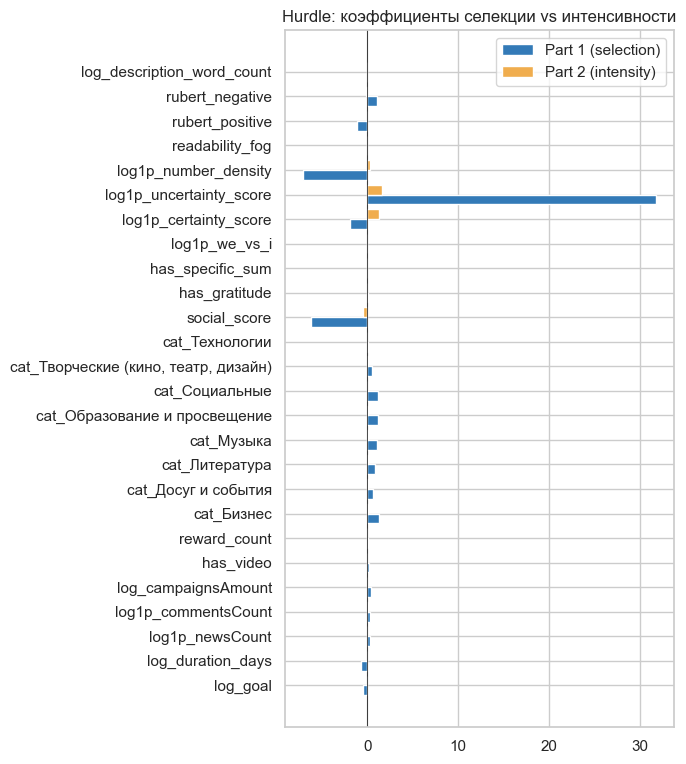

In [39]:
if hurdle_part1 is not None and hurdle_part2 is not None:
    common = [c for c in hurdle_part1.params.index
              if c in hurdle_part2.params.index and c != "const"]

    tbl = pd.DataFrame({
        "part1_coef":  hurdle_part1.params.loc[common],
        "part1_p":     hurdle_part1.pvalues.loc[common],
        "part2_coef":  hurdle_part2.params.loc[common],
        "part2_p":     hurdle_part2.pvalues.loc[common],
    }).round(3)
    print("Коэффициенты: Part 1 (selection, log-odds) vs Part 2 (intensity, log_fr):")
    print(tbl.to_string())

    plt.figure(figsize=(7, max(4, 0.3 * len(common))))
    idx = np.arange(len(common))
    plt.barh(idx - 0.2, tbl["part1_coef"], height=0.4,
             color="#337ab7", label="Part 1 (selection)")
    plt.barh(idx + 0.2, tbl["part2_coef"], height=0.4,
             color="#f0ad4e", label="Part 2 (intensity)")
    plt.yticks(idx, common)
    plt.axvline(0, color="black", lw=0.5)
    plt.legend()
    plt.title("Hurdle: коэффициенты селекции vs интенсивности")
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/hurdle_coef_comparison.png", dpi=120)
    plt.show()


## 24. Проверка устойчивости результатов

Три теста:
1. **По подвыборкам категорий** — логит и RF отдельно для каждой крупной категории; сравниваем коэффициенты и качество.
2. **Сырые признаки vs преобразованные** — те же модели без log-трансформаций; оцениваем, насколько результаты зависят от выбора шкалы.
3. **Альтернативные преобразования** — вместо log пробуем √ (sqrt) и винсоризацию (1–99 перцентиль); сравниваем псевдо-R², AIC и ROC-AUC.

### 24.1  Анализ по подвыборкам категорий

Для каждой категории с N ≥ 50 строим логит и RandomForest на наборе `CONTROLS + TEXT` (без категориальных дамми — внутри подвыборки они вырождены). Сравниваем псевдо-R², AIC и ROC-AUC, а также ключевые коэффициенты через тепловую карту.

In [103]:
# ── параметры ──────────────────────────────────────────────────────────────
_MIN_N_SUB   = 0   # минимальная подвыборка
_MIN_POS_SUB = 5    # минимум позитивных примеров

_cat_counts  = df_fit["category_grouped"].value_counts()
_ROBUST_CATS = _cat_counts[_cat_counts >= _MIN_N_SUB].index.tolist()

print(f"Категорий с N≥{_MIN_N_SUB}: {len(_ROBUST_CATS)}")
print(f"{'Категория':<42} {'N':>5}  {'Успешных':>9}  {'%':>5}")
print("─" * 65)
for cat in _ROBUST_CATS:
    n    = int(_cat_counts[cat])
    nsuc = int(df_fit[df_fit["category_grouped"] == cat][TARGET_COL].sum())
    print(f"{cat:<42} {n:>5}  {nsuc:>9}  {100*nsuc/n:>4.0f}%")

# признаки: контроли + текст, без категориальных дамми
_sub_feats = [f for f in CONTROLS + TEXT if f in df_fit.columns]

_sub_logit = {}
_sub_rf    = {}
_sub_summary = []

for cat in _ROBUST_CATS:
    sub   = df_fit[df_fit["category_grouped"] == cat].copy()
    y_sub = sub[TARGET_COL].astype(int)

    if y_sub.nunique() < 2 or int(y_sub.sum()) < _MIN_POS_SUB:
        print(f"[{cat}] недостаточно позитивных примеров — пропуск")
        continue

    X_sub = (sub[_sub_feats]
             .apply(pd.to_numeric, errors="coerce")
             .fillna(0).astype(float))
    X_sub = X_sub.loc[:, X_sub.nunique() > 1]

    # Logit ───────────────────────────────────────────────────────────────
    Xc = sm.add_constant(X_sub, has_constant="add")
    try:
        m = sm.Logit(y_sub, Xc).fit(disp=0, maxiter=300, cov_type="HC1")
        _sub_logit[cat] = m
    except Exception as e:
        print(f"  Logit [{cat}]: {e}")
        m = None

    # RandomForest via CV ─────────────────────────────────────────────────
    rf        = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE,
                                       class_weight="balanced", n_jobs=-1)
    spl_sub, spl_name = cv_splitter(y_sub)
    met_sub   = eval_model(rf, X_sub, y_sub, spl_sub)

    _sub_summary.append({
        "Категория":    cat,
        "N":            len(sub),
        "N_успешных":   int(y_sub.sum()),
        "% успешных":   round(100 * y_sub.mean(), 1),
        "pseudo_R2":    round(m.prsquared, 3) if m else float("nan"),
        "AIC":          round(m.aic,       1) if m else float("nan"),
        "RF_ROC_AUC":   round(met_sub.get("ROC_AUC", float("nan")), 3),
        "RF_PR_AUC":    round(met_sub.get("PR_AUC",  float("nan")), 3),
        "CV":           spl_name,
    })

print("\n── Сводка: логит и RF по категориям ──")
_sub_df = pd.DataFrame(_sub_summary)
print(_sub_df.to_string(index=False))


Категорий с N≥0: 9
Категория                                      N   Успешных      %
─────────────────────────────────────────────────────────────────
Благотворительность                          992        323    33%
Литература                                   565        316    56%
Музыка                                       563        354    63%
Творческие (кино, театр, дизайн)             453        232    51%
Социальные                                   288        165    57%
Досуг и события                              187         93    50%
Образование и просвещение                     90         59    66%
Технологии                                    29         12    41%
Бизнес                                        25         16    64%


NameError: name 'cv_splitter' is not defined

In [41]:
# ── коэффициенты Logit по категориям: таблица (все признаки) ────────────

# читаемые метки для всех возможных признаков
_all_feat_labels = {
    "log_goal":                    "log(цель)",
    "log_duration_days":           "log(длит.)",
    "log1p_newsCount":             "log1p(новости)",
    "log1p_commentsCount":         "log1p(комментарии)",
    "log_campaignsAmount":         "log(кампаний авт.)",
    "has_video":                   "Видео (бин.)",
    "reward_count":                "Вознаграждений",
    "social_score":                "Социальность",
    "has_gratitude":               "Благодарность (бин.)",
    "gratitude_has":               "Благодарность (бин.)",
    "has_specific_sum":            "Конкр. сумма (бин.)",
    "log1p_we_vs_i":               "log1p(мы/я)",
    "log1p_certainty_score":       "log1p(уверенность)",
    "log1p_uncertainty_score":     "log1p(неуверенность)",
    "log1p_number_density":        "log1p(плотн. чисел)",
    "readability_fog":             "Fog-индекс",
    "rubert_positive":             "RuBERT+",
    "rubert_negative":             "RuBERT-",
    "log_description_word_count":  "log(слов)",
}

def _sig(p):
    if pd.isna(p): return ""
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""

# собираем все признаки из всех подвыборочных моделей (кроме const)
_all_sub_feats_order = [f for f in _sub_feats if f != "const"]
_extra = [f for m in _sub_logit.values()
          for f in m.params.index if f != "const" and f not in _all_sub_feats_order]
for f in _extra:
    if f not in _all_sub_feats_order:
        _all_sub_feats_order.append(f)

_coef_rows2 = []
for cat, m in _sub_logit.items():
    for feat in _all_sub_feats_order:
        if feat in m.params.index:
            _coef_rows2.append({
                "cat":  cat,
                "feat": feat,
                "coef": m.params[feat],
                "pval": m.pvalues[feat],
                "se":   m.bse[feat],
            })

if not _coef_rows2:
    print("Нет данных.")
else:
    _cd   = pd.DataFrame(_coef_rows2)
    _pc   = _cd.pivot(index="feat", columns="cat", values="coef").reindex(index=_all_sub_feats_order)
    _pp   = _cd.pivot(index="feat", columns="cat", values="pval").reindex(index=_all_sub_feats_order)
    _ps   = _cd.pivot(index="feat", columns="cat", values="se").reindex(index=_all_sub_feats_order)

    # убираем строки, где все — NaN
    _pc = _pc.dropna(how="all")
    _pp = _pp.reindex(index=_pc.index)
    _ps = _ps.reindex(index=_pc.index)

    _disp    = pd.DataFrame(index=_pc.index, columns=_pc.columns, dtype=object)
    _disp_se = pd.DataFrame(index=_pc.index, columns=_pc.columns, dtype=object)
    for feat in _pc.index:
        for cat in _pc.columns:
            c = _pc.loc[feat, cat]
            p = _pp.loc[feat, cat]
            s = _ps.loc[feat, cat]
            if pd.isna(c):
                _disp.loc[feat, cat]    = "—"
                _disp_se.loc[feat, cat] = ""
            else:
                _disp.loc[feat, cat]    = f"{c:+.3f}{_sig(p)}"
                _disp_se.loc[feat, cat] = f"({s:.3f})"

    # читаемые метки строк
    _disp.index    = [_all_feat_labels.get(f, f) for f in _disp.index]
    _disp_se.index = _disp.index

    # чередуем коэф. и SE
    _interleaved = []
    for lbl in _disp.index:
        _interleaved.append(_disp.loc[lbl])
        _interleaved.append(_disp_se.loc[lbl])
    _tbl78 = pd.DataFrame(_interleaved)

    # pseudo-R² в конец
    _tbl78.loc["pseudo-R²"] = {
        cat: f"{_sub_logit[cat].prsquared:.3f}" if cat in _sub_logit else "—"
        for cat in _pc.columns
    }
    _tbl78.loc["AIC"] = {
        cat: f"{_sub_logit[cat].aic:.1f}" if cat in _sub_logit else "—"
        for cat in _pc.columns
    }

    print("Коэффициенты Logit по категориям — все признаки"
          " (SE в скобках; * p<0.1, ** p<0.05, *** p<0.01):\n")
    print(_tbl78.to_string())

    # отдельная таблица p-значений
    _wp = _pp.copy().round(3)
    _wp.index = [_all_feat_labels.get(f, f) for f in _wp.index]
    print("\np-значения:\n")
    print(_wp.to_string())


Коэффициенты Logit по категориям — все признаки (SE в скобках; * p<0.1, ** p<0.05, *** p<0.01):

cat                  Благотворительность Досуг и события Литература     Музыка Образование и просвещение Социальные Творческие (кино, театр, дизайн)
log(цель)                      -0.913***       -0.577***  -0.359***  -0.341***                    +0.064  -0.509***                         -0.271**
log(цель)                        (0.101)         (0.189)    (0.112)    (0.119)                   (0.329)    (0.148)                          (0.113)
log(длит.)                     -0.546***          -0.168  -0.668***  -1.103***                  -1.489**  -0.969***                        -0.718***
log(длит.)                       (0.131)         (0.287)    (0.192)    (0.206)                   (0.614)    (0.241)                          (0.180)
log1p(новости)                 +0.610***          -0.065  +0.477***     +0.103                    +0.369    +0.290*                           +0.122
log1p(нов

### 24.2  Сырые признаки vs преобразованные

Запускаем те же модели (логит + RandomForest) на признаках **без** log-трансформаций и сравниваем с базовой спецификацией. Если результаты устойчивы — выводы не зависят от выбора шкалы.

In [42]:
# ── сырые (нетрансформированные) признаки ────────────────────────────────
CONTROLS_RAW = [f for f in [
    "card.targetAmount.value",
    "campaign_duration_days",
    "counts.newsCount",
    "counts.commentsCount",
    "card.author.campaignsAmount",
    "video_count",
    "reward_count",
] if f in df_fit.columns]

TEXT_RAW = [f for f in [
    "social_score",
    "gratitude_score",
    "has_specific_sum",
    "we_vs_i",
    "certainty_score",
    "uncertainty_score",
    "number_density",
    "readability_fog",
    "rubert_positive",
    "rubert_negative",
    "description_word_count",
] if f in df_fit.columns]

_compare_sets = {
    "A_log (базовая)": [f for f in FEATURE_SETS["A_controls_and_categories"] if f in df_fit.columns],
    "A_raw":           [f for f in CONTROLS_RAW + CATEGORY_DUMMIES           if f in df_fit.columns],
    "B_log (базовая)": [f for f in FEATURE_SETS["B_all"]                      if f in df_fit.columns],
    "B_raw":           [f for f in CONTROLS_RAW + CATEGORY_DUMMIES + TEXT_RAW if f in df_fit.columns],
}

y_all = df_fit[TARGET_COL].astype(int)
spl_all, spl_all_name = cv_splitter(y_all)

_raw_rows = []
_raw_logit_models = {}  # сохраняем модели для таблицы коэф.

for name, feats in _compare_sets.items():
    feats = [f for f in feats if f in df_fit.columns]
    if not feats:
        print(f"[{name}] нет признаков — пропуск")
        continue

    X = (df_fit[feats]
         .apply(pd.to_numeric, errors="coerce")
         .fillna(0).astype(float))
    X = X.loc[:, X.nunique() > 1]
    Xc = sm.add_constant(X, has_constant="add")

    # Logit
    try:
        m = sm.Logit(y_all, Xc).fit(disp=0, maxiter=300, cov_type="HC1")
        ps_r2 = round(m.prsquared, 3)
        aic   = round(m.aic, 1)
        llf   = round(m.llf, 2)
        _raw_logit_models[name] = m
    except Exception as e:
        print(f"  Logit [{name}]: {e}")
        ps_r2, aic, llf = float("nan"), float("nan"), float("nan")

    # RandomForest
    rf  = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE,
                                 class_weight="balanced", n_jobs=-1)
    met = eval_model(rf, X, y_all, spl_all)

    _raw_rows.append({
        "набор":        name,
        "N_признаков":  len(feats),
        "pseudo_R2":    ps_r2,
        "AIC":          aic,
        "Log-L":        llf,
        "RF_ROC_AUC":   round(met.get("ROC_AUC", float("nan")), 3),
        "RF_PR_AUC":    round(met.get("PR_AUC",  float("nan")), 3),
        "RF_F1":        round(met.get("F1",       float("nan")), 3),
    })

print(f"CV: {spl_all_name}\n")
print("── Raw vs Log: сравнение метрик ──")
_raw_df = pd.DataFrame(_raw_rows)
print(_raw_df.to_string(index=False))


CV: Stratified 5-Fold

── Raw vs Log: сравнение метрик ──
          набор  N_признаков  pseudo_R2    AIC    Log-L  RF_ROC_AUC  RF_PR_AUC  RF_F1
A_log (базовая)           15      0.158 3756.6 -1862.31       0.723      0.695  0.646
          A_raw           15      0.129 3884.8 -1926.38       0.723      0.694  0.650
B_log (базовая)           26      0.168 3736.9 -1841.45       0.750      0.729  0.683
          B_raw           26      0.139 3863.4 -1904.68       0.743      0.717  0.677


In [43]:
# ── таблица коэффициентов: B_log vs B_raw — все признаки ────────────────

# соответствие признаков raw → log (и обратно)
_FEAT_PAIRS_RAW = [
    ("card.targetAmount.value",     "log_goal",                    "Целевая сумма"),
    ("campaign_duration_days",      "log_duration_days",           "Длит. кампании"),
    ("counts.newsCount",            "log1p_newsCount",             "Новости"),
    ("counts.commentsCount",        "log1p_commentsCount",         "Комментарии"),
    ("card.author.campaignsAmount", "log_campaignsAmount",         "Кампаний авт."),
    ("video_count",                 "has_video",                   "Видео"),
    ("reward_count",                "reward_count",                "Вознаграждений"),
    ("social_score",                "social_score",                "Социальность"),
    ("gratitude_score",             "has_gratitude",               "Благодарность"),
    ("has_specific_sum",            "has_specific_sum",            "Конкр. сумма (бин.)"),
    ("we_vs_i",                     "log1p_we_vs_i",               "Мы/я"),
    ("certainty_score",             "log1p_certainty_score",       "Уверенность"),
    ("uncertainty_score",           "log1p_uncertainty_score",     "Неуверенность"),
    ("number_density",              "log1p_number_density",        "Плотн. чисел"),
    ("readability_fog",             "readability_fog",             "Fog-индекс"),
    ("rubert_positive",             "rubert_positive",             "RuBERT+"),
    ("rubert_negative",             "rubert_negative",             "RuBERT-"),
    ("description_word_count",      "log_description_word_count",  "Слов в описании"),
]
# категориальные дамми — одинаковые в обеих моделях
_FEAT_PAIRS_RAW += [
    (c, c, c.replace("cat_", "Кат: "))
    for c in CATEGORY_DUMMIES
    if c in df_fit.columns
]

def _sig(p):
    if pd.isna(p): return ""
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""

def _fmt(m, feat):
    if m is None or feat not in m.params.index:
        return "—", ""
    return f"{m.params[feat]:+.3f}{_sig(m.pvalues[feat])}", f"({m.bse[feat]:.3f})"

for _set_suffix in ["A", "B"]:
    _log_key = f"{_set_suffix}_log (базовая)"
    _raw_key = f"{_set_suffix}_raw"
    _m_log = _raw_logit_models.get(_log_key)
    _m_raw = _raw_logit_models.get(_raw_key)

    if _m_log is None and _m_raw is None:
        continue

    print(f"\n{"-"*72}")
    print(f"Набор {_set_suffix}: log-трансформация vs сырые признаки"
          " (SE в скобках; * p<0.1, ** p<0.05, *** p<0.01)")
    print(f"{"-"*72}")

    rows = []
    for raw_feat, log_feat, label in _FEAT_PAIRS_RAW:
        c_log, se_log = _fmt(_m_log, log_feat)
        c_raw, se_raw = _fmt(_m_raw, raw_feat)
        if c_log == "—" and c_raw == "—":
            continue
        rows.append({
            "Признак":    label,
            "log-модель": c_log,
            "SE (log)":   se_log,
            "raw-модель": c_raw,
            "SE (raw)":   se_raw,
        })

    rows.append({
        "Признак":    "pseudo-R²",
        "log-модель": f"{_m_log.prsquared:.3f}" if _m_log else "—",
        "SE (log)":   "",
        "raw-модель": f"{_m_raw.prsquared:.3f}" if _m_raw else "—",
        "SE (raw)":   "",
    })
    rows.append({
        "Признак":    "AIC",
        "log-модель": f"{_m_log.aic:.1f}" if _m_log else "—",
        "SE (log)":   "",
        "raw-модель": f"{_m_raw.aic:.1f}" if _m_raw else "—",
        "SE (raw)":   "",
    })

    _tbl81 = pd.DataFrame(rows).set_index("Признак")
    print(_tbl81.to_string())



------------------------------------------------------------------------
Набор A: log-трансформация vs сырые признаки (SE в скобках; * p<0.1, ** p<0.05, *** p<0.01)
------------------------------------------------------------------------
                                      log-модель SE (log) raw-модель SE (raw)
Признак                                                                      
Целевая сумма                          -0.453***  (0.044)  -0.000***  (0.000)
Длит. кампании                         -0.680***  (0.070)  -0.009***  (0.001)
Новости                                +0.331***  (0.046)  +0.038***  (0.008)
Комментарии                            +0.258***  (0.042)   +0.013**  (0.006)
Кампаний авт.                          +0.440***  (0.050)  +0.043***  (0.010)
Видео                                    +0.147*  (0.086)     +0.012  (0.031)
Вознаграждений                         +0.037***  (0.007)  +0.037***  (0.007)
Кат: Бизнес                            +1.462***  (0.515)  

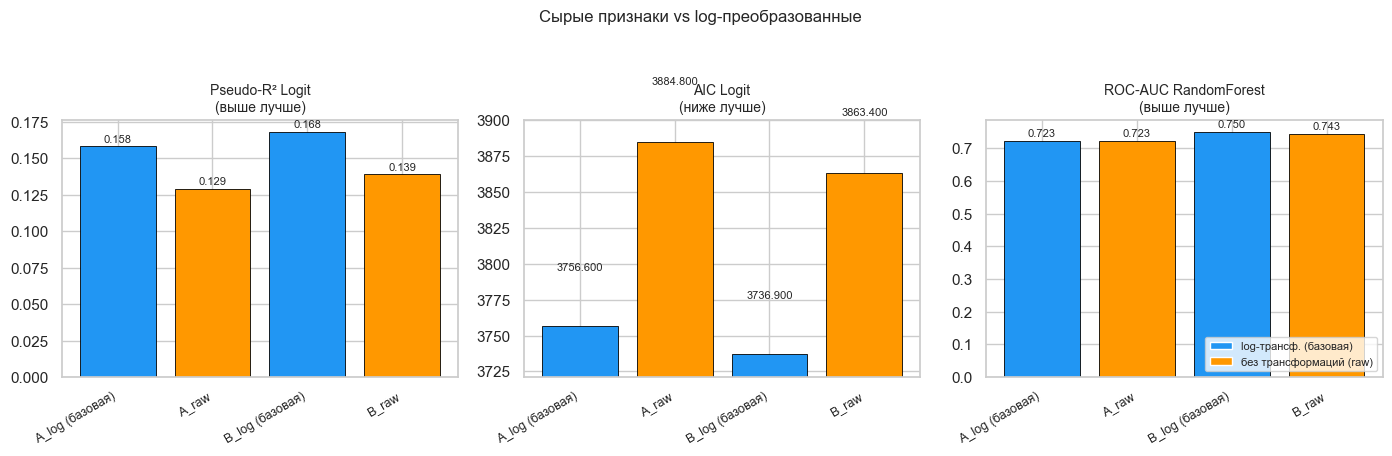

In [44]:
# ── Визуализация: bar-chart по ключевым метрикам ─────────────────────────
_metrics_raw = ["pseudo_R2", "AIC", "RF_ROC_AUC"]
_titles_raw  = [
    "Pseudo-R² Logit\n(выше лучше)",
    "AIC Logit\n(ниже лучше)",
    "ROC-AUC RandomForest\n(выше лучше)",
]
_colors_raw = [
    "#2196F3" if "log" in n.lower() else "#FF9800"
    for n in _raw_df["набор"]
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, metric, title in zip(axes, _metrics_raw, _titles_raw):
    vals = _raw_df[metric].values.astype(float)
    bars = ax.bar(_raw_df["набор"], vals, color=_colors_raw,
                  edgecolor="black", linewidth=0.6)
    ax.set_title(title, fontsize=10)
    ax.set_xticklabels(_raw_df["набор"], rotation=30, ha="right", fontsize=9)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() * 1.01,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=8)

    if metric == "AIC":
        # для AIC ниже = лучше, инвертируем ось
        finite = vals[~np.isnan(vals)]
        if len(finite):
            margin = (finite.max() - finite.min()) * 0.1 + 1
            ax.set_ylim(finite.min() - margin, finite.max() + margin)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2196F3", label="log-трансф. (базовая)"),
    Patch(facecolor="#FF9800", label="без трансформаций (raw)"),
]
axes[-1].legend(handles=legend_elements, loc="lower right", fontsize=8)

plt.suptitle("Сырые признаки vs log-преобразованные", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/robustness_raw_vs_log.png", dpi=120, bbox_inches="tight")
plt.show()


### 24.3  Альтернативные преобразования: √ (sqrt) и винсоризация

Вместо `log` пробуем:
- **sqrt** — √x, сглаживает выбросы мягче чем log; допускает ноль.
- **winsorize** — обрезаем [1%, 99%], оставляем сырую шкалу; убираем экстремальные наблюдения без изменения распределения внутри.

Если псевдо-R² и ROC-AUC стабильны — выводы не зависят от конкретного способа трансформации.

In [45]:
# ── sqrt-преобразования ───────────────────────────────────────────────────
_sqrt_map = {
    "card.targetAmount.value":    "sqrt_goal",
    "campaign_duration_days":     "sqrt_duration_days",
    "counts.newsCount":           "sqrt_newsCount",
    "counts.commentsCount":       "sqrt_commentsCount",
    "card.author.campaignsAmount":"sqrt_campaignsAmount",
    "video_count":                "sqrt_video_count",
    "description_word_count":     "sqrt_description_word_count",
    "we_vs_i":                    "sqrt_we_vs_i",
    "certainty_score":            "sqrt_certainty_score",
    "uncertainty_score":          "sqrt_uncertainty_score",
    "number_density":             "sqrt_number_density",
}
for src_col, tgt_col in _sqrt_map.items():
    if src_col in df_fit.columns:
        df_fit[tgt_col] = np.sqrt(df_fit[src_col].fillna(0).clip(lower=0))

# ── винсоризация (1–99 перцентиль) ───────────────────────────────────────
_win_map = {
    "card.targetAmount.value":    "win_goal",
    "campaign_duration_days":     "win_duration_days",
    "counts.newsCount":           "win_newsCount",
    "counts.commentsCount":       "win_commentsCount",
    "card.author.campaignsAmount":"win_campaignsAmount",
    "description_word_count":     "win_description_word_count",
    "we_vs_i":                    "win_we_vs_i",
    "certainty_score":            "win_certainty_score",
    "uncertainty_score":          "win_uncertainty_score",
    "number_density":             "win_number_density",
    "video_count":                "win_video_count",
}
for src_col, tgt_col in _win_map.items():
    if src_col in df_fit.columns:
        lo, hi = df_fit[src_col].quantile([0.01, 0.99])
        df_fit[tgt_col] = df_fit[src_col].fillna(df_fit[src_col].median()).clip(lo, hi)

# ── наборы признаков для каждого преобразования ──────────────────────────
_avail_now = set(df_fit.columns)

CONTROLS_SQRT = [f for f in [
    "sqrt_goal", "sqrt_duration_days", "sqrt_newsCount", "sqrt_commentsCount",
    "sqrt_campaignsAmount", "has_video", "reward_count",
] if f in _avail_now]

TEXT_SQRT = [f for f in [
    "social_score", "gratitude_has", "has_specific_sum",
    "sqrt_we_vs_i", "sqrt_certainty_score", "sqrt_uncertainty_score",
    "sqrt_number_density", "readability_fog",
    "rubert_positive", "rubert_negative", "sqrt_description_word_count",
] if f in _avail_now]

CONTROLS_WIN = [f for f in [
    "win_goal", "win_duration_days", "win_newsCount", "win_commentsCount",
    "win_campaignsAmount", "has_video", "reward_count",
] if f in _avail_now]

TEXT_WIN = [f for f in [
    "social_score", "gratitude_has", "has_specific_sum",
    "win_we_vs_i", "win_certainty_score", "win_uncertainty_score",
    "win_number_density", "readability_fog",
    "rubert_positive", "rubert_negative", "win_description_word_count",
] if f in _avail_now]

_alt_sets = {
    "B_log (базовая)": [f for f in FEATURE_SETS["B_all"]                                       if f in _avail_now],
    "B_sqrt":          [f for f in CONTROLS_SQRT + CATEGORY_DUMMIES + TEXT_SQRT                if f in _avail_now],
    "B_win":           [f for f in CONTROLS_WIN  + CATEGORY_DUMMIES + TEXT_WIN                 if f in _avail_now],
    "B_raw":           [f for f in CONTROLS_RAW  + CATEGORY_DUMMIES + TEXT_RAW                 if f in _avail_now],
}

print("Состав наборов:")
for name, feats in _alt_sets.items():
    print(f"  {name:<20}: {len(feats)} признаков")

# ── обучение и оценка ─────────────────────────────────────────────────────
_alt_rows = []

for name, feats in _alt_sets.items():
    feats = [f for f in feats if f in df_fit.columns]
    if not feats:
        print(f"[{name}] нет признаков — пропуск")
        continue

    X = (df_fit[feats]
         .apply(pd.to_numeric, errors="coerce")
         .fillna(0).astype(float))
    X = X.loc[:, X.nunique() > 1]
    Xc = sm.add_constant(X, has_constant="add")

    try:
        m   = sm.Logit(y_all, Xc).fit(disp=0, maxiter=300, cov_type="HC1")
        ps  = round(m.prsquared, 3)
        aic = round(m.aic, 1)
    except Exception as e:
        print(f"  Logit [{name}]: {e}")
        ps, aic = float("nan"), float("nan")

    rf  = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE,
                                 class_weight="balanced", n_jobs=-1)
    met = eval_model(rf, X, y_all, spl_all)

    _alt_rows.append({
        "набор":        name,
        "N_признаков":  len(feats),
        "pseudo_R2":    ps,
        "AIC":          aic,
        "RF_ROC_AUC":   round(met.get("ROC_AUC", float("nan")), 3),
        "RF_PR_AUC":    round(met.get("PR_AUC",  float("nan")), 3),
        "RF_F1":        round(met.get("F1",       float("nan")), 3),
    })

print("\n── Сравнение трансформаций ──")
_alt_df = pd.DataFrame(_alt_rows)
print(_alt_df.to_string(index=False))


Состав наборов:
  B_log (базовая)     : 26 признаков
  B_sqrt              : 26 признаков
  B_win               : 26 признаков
  B_raw               : 26 признаков

── Сравнение трансформаций ──
          набор  N_признаков  pseudo_R2    AIC  RF_ROC_AUC  RF_PR_AUC  RF_F1
B_log (базовая)           26      0.168 3736.9       0.750      0.729  0.683
         B_sqrt           26      0.164 3753.3       0.750      0.729  0.684
          B_win           26      0.153 3801.4       0.750      0.726  0.687
          B_raw           26      0.139 3863.4       0.743      0.717  0.677


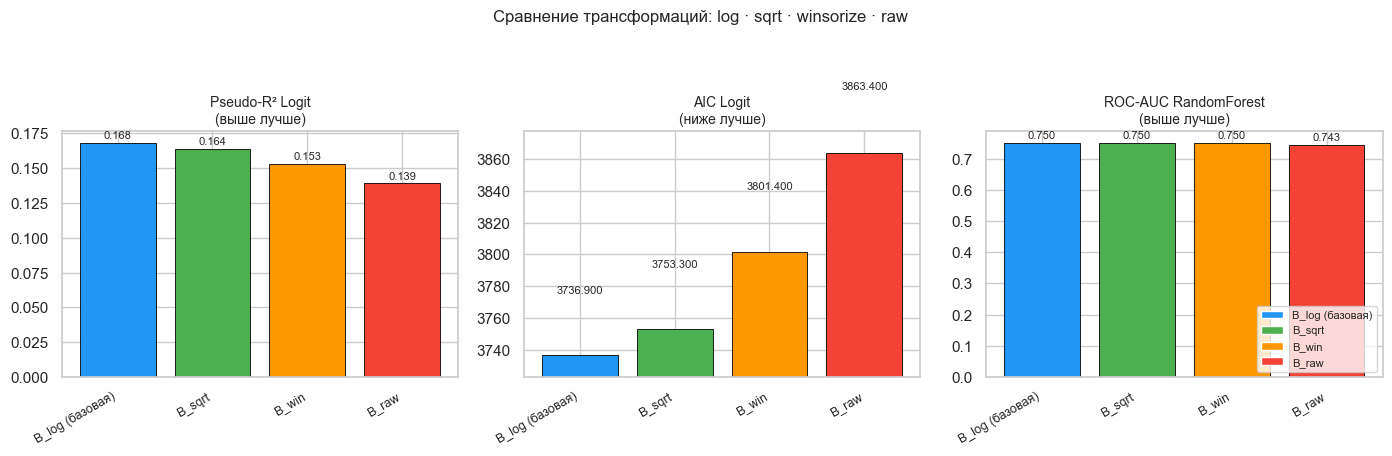

In [46]:
# ── визуализация: bar-chart log vs sqrt vs win vs raw ────────────────────
_palette_alt = {
    "B_log (базовая)": "#2196F3",
    "B_sqrt":          "#4CAF50",
    "B_win":           "#FF9800",
    "B_raw":           "#F44336",
}
_colors_alt = [_palette_alt.get(n, "#9E9E9E") for n in _alt_df["набор"]]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

_metrics_alt = ["pseudo_R2", "AIC", "RF_ROC_AUC"]
_titles_alt  = [
    "Pseudo-R² Logit\n(выше лучше)",
    "AIC Logit\n(ниже лучше)",
    "ROC-AUC RandomForest\n(выше лучше)",
]

for ax, metric, title in zip(axes, _metrics_alt, _titles_alt):
    vals = _alt_df[metric].values.astype(float)
    bars = ax.bar(_alt_df["набор"], vals, color=_colors_alt,
                  edgecolor="black", linewidth=0.6)
    ax.set_title(title, fontsize=10)
    ax.set_xticklabels(_alt_df["набор"], rotation=30, ha="right", fontsize=9)

    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() * 1.01,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=8)

    if metric == "AIC":
        finite = vals[~np.isnan(vals)]
        if len(finite):
            margin = (finite.max() - finite.min()) * 0.1 + 1
            ax.set_ylim(finite.min() - margin, finite.max() + margin)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=c, label=n)
    for n, c in _palette_alt.items()
]
axes[-1].legend(handles=legend_elements, loc="lower right", fontsize=8)

plt.suptitle("Сравнение трансформаций: log · sqrt · winsorize · raw", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/robustness_transforms_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


In [47]:
# ── Итоговая сводная таблица всех проверок устойчивости ─────────────────
print("=" * 70)
print("ИТОГОВАЯ СВОДКА: ПРОВЕРКА УСТОЙЧИВОСТИ")
print("=" * 70)

print("\n1. Качество по категориям (Logit + RF, B_all без дамми):")
print(_sub_df[["Категория", "N", "% успешных", "pseudo_R2", "AIC", "RF_ROC_AUC"]].to_string(index=False))

print("\n2. Сырые признаки vs log-преобразованные:")
print(_raw_df[["набор", "pseudo_R2", "AIC", "RF_ROC_AUC", "RF_PR_AUC"]].to_string(index=False))

print("\n3. Альтернативные преобразования (log / sqrt / win / raw):")
print(_alt_df[["набор", "pseudo_R2", "AIC", "RF_ROC_AUC", "RF_PR_AUC"]].to_string(index=False))

print("\nИнтерпретация:")
print("  • Если pseudo-R² и ROC-AUC близки между log/sqrt/win → результаты устойчивы к выбору трансформации.")
print("  • Если коэффициенты в подвыборках имеют одинаковые знаки → нет значимой гетерогенности по категориям.")
print("  • Рост AIC при переходе к raw → log-трансформация улучшает спецификацию.")


ИТОГОВАЯ СВОДКА: ПРОВЕРКА УСТОЙЧИВОСТИ

1. Качество по категориям (Logit + RF, B_all без дамми):
                       Категория   N  % успешных  pseudo_R2   AIC  RF_ROC_AUC
             Благотворительность 992        32.6      0.263 960.3       0.817
                      Литература 565        55.9      0.134 709.1       0.712
                          Музыка 563        62.9      0.156 665.0       0.685
Творческие (кино, театр, дизайн) 453        51.2      0.084 612.8       0.607
                      Социальные 288        57.3      0.170 364.2       0.646
                 Досуг и события 187        49.7      0.149 258.6       0.508
       Образование и просвещение  90        65.6      0.327 116.0       0.534
                      Технологии  29        41.4        NaN   NaN       0.402
                          Бизнес  25        64.0        NaN   NaN       0.302

2. Сырые признаки vs log-преобразованные:
          набор  pseudo_R2    AIC  RF_ROC_AUC  RF_PR_AUC
A_log (базовая)      0.

## 25. Описательные статистики по категориям «Технологии» и «Бизнес»

Эти категории слишком малы для подвыборочных регрессий (N=29 и N=25), поэтому в разделе 24.1 они были исключены. Здесь приводим их описательные статистики — числовые и текстовые признаки в сравнении с остальными категориями и полной выборкой.

In [102]:
# ── признаки для описательных статистик ─────────────────────────────────
_DESC_FEATS = {
    # контроли
    "card.targetAmount.value":        "Целевая сумма, руб.",
    "campaign_duration_days":         "Длит. кампании, дни",
    "counts.newsCount":               "Новостей",
    "counts.commentsCount":           "Комментариев",
    "card.author.campaignsAmount":    "Кампаний у автора",
    "video_count":                    "Видео",
    "image_count":                    "Изображений",
    "reward_count":                   "Вознаграждений",
    "description_word_count":         "Слов в описании",
    # текстовые
    "social_score":                   "Социальность",
    "gratitude_score":                "Благодарность",
    "we_vs_i":                        "Мы/я",
    "certainty_score":                "Уверенность",
    "uncertainty_score":              "Неуверенность",
    "number_density":                 "Плотн. чисел",
    "readability_fog":                "Fog-индекс",
    "rubert_positive":                "RuBERT+",
    "rubert_negative":                "RuBERT-",
    # таргет
    "is_successful":                  "Успешность (доля)",
    "funding_ratio":                  "Funding ratio",
}

_DESC_COLS = [f for f in _DESC_FEATS if f in df_fit.columns]

# ── группировка ───────────────────────────────────────────────────────────
_FOCUS_CATS = ["Бизнес", "Технологии"]
_other_mask = ~df_fit["category_grouped"].isin(_FOCUS_CATS)

_groups = {
    "Бизнес":           df_fit[df_fit["category_grouped"] == "Бизнес"],
    "Технологии":       df_fit[df_fit["category_grouped"] == "Технологии"],
    "Остальные":        df_fit[_other_mask],
    "Вся выборка":      df_fit,
}

# ── вспомогательная функция: mean (median) ────────────────────────────────
def _desc_col(series):
    """Возвращает строку 'mean\n(median)'."""
    s = series.dropna()
    if len(s) == 0:
        return "—"
    return f"{s.mean():.3f}\n({s.median():.3f})"

# ── строим таблицу ────────────────────────────────────────────────────────
_rows = []
for feat, label in _DESC_FEATS.items():
    if feat not in df_fit.columns:
        continue
    row = {"Признак": label}
    for grp_name, grp_df in _groups.items():
        row[grp_name] = _desc_col(grp_df[feat])
    _rows.append(row)

_desc_tbl = pd.DataFrame(_rows).set_index("Признак")

# ── N и % успешных отдельной шапкой ───────────────────────────────────────
_header_rows = []
for grp_name, grp_df in _groups.items():
    n    = len(grp_df)
    pct  = grp_df[TARGET_COL].mean() * 100 if TARGET_COL in grp_df.columns else float("nan")
    _header_rows.append({
        "Группа":       grp_name,
        "N":            n,
        "% успешных":   f"{pct:.1f}%",
    })
_header_df = pd.DataFrame(_header_rows).set_index("Группа")

print("Размер групп и доля успешных:\n")
print(_header_df.to_string())
print()
print("Описательные статистики: среднее (медиана)\n")
print(_desc_tbl.to_string())


Размер групп и доля успешных:

                N % успешных
Группа                      
Бизнес         25      64.0%
Технологии     29      41.4%
Остальные    3138      49.1%
Вся выборка  3192      49.2%

Описательные статистики: среднее (медиана)

                                       Бизнес               Технологии                 Остальные               Вся выборка
Признак                                                                                                                   
Целевая сумма, руб.  199225.480\n(100000.000)  137293.103\n(75000.000)  221380.946\n(130000.000)  220443.467\n(130000.000)
Длит. кампании, дни          65.880\n(55.000)         69.034\n(52.000)          78.296\n(65.000)          78.115\n(65.000)
Новостей                       3.360\n(2.000)           4.414\n(2.000)            5.626\n(3.000)            5.597\n(3.000)
Комментариев                   6.080\n(2.000)           4.759\n(2.000)            4.709\n(1.000)            4.720\n(1.000)
Кампаний у а

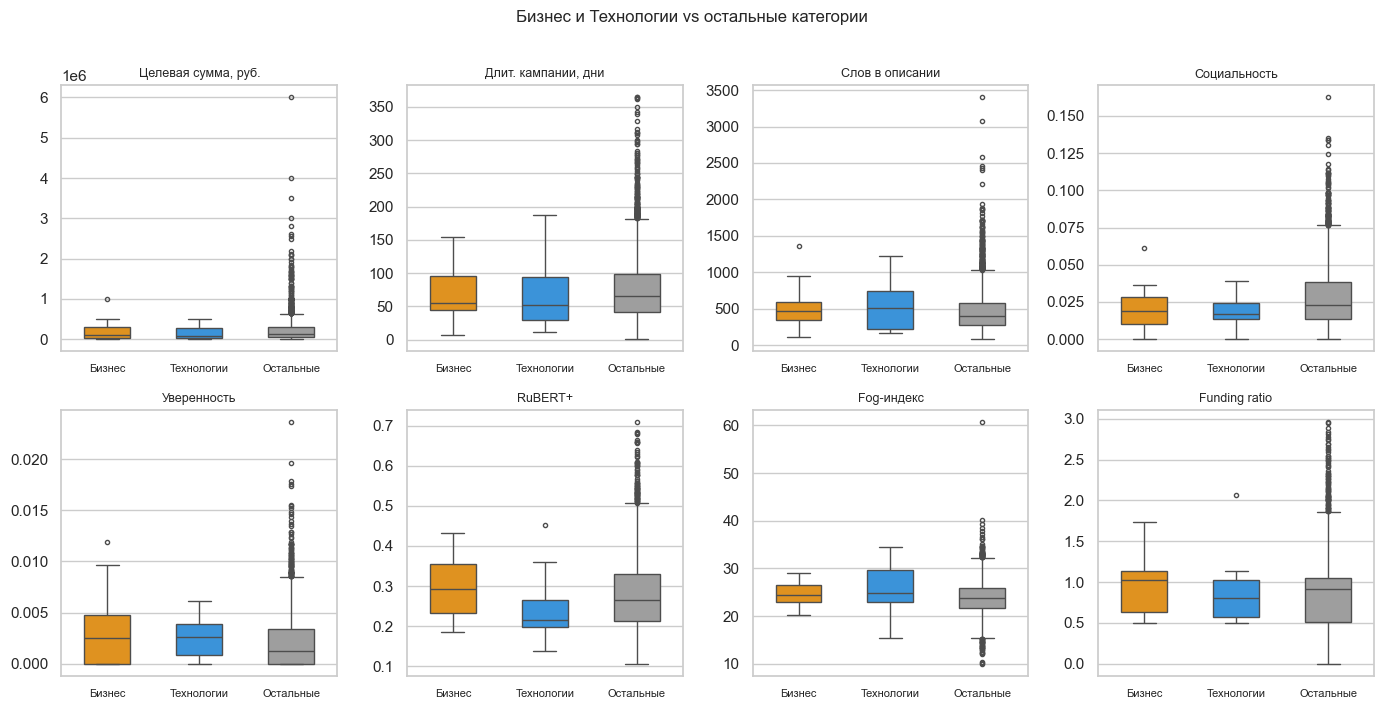

In [49]:
# ── бокс-плоты: Технологии и Бизнес vs остальные ────────────────────────
_plot_feats = [
    ("card.targetAmount.value",     "Целевая сумма, руб."),
    ("campaign_duration_days",      "Длит. кампании, дни"),
    ("description_word_count",      "Слов в описании"),
    ("social_score",                "Социальность"),
    ("certainty_score",             "Уверенность"),
    ("rubert_positive",             "RuBERT+"),
    ("readability_fog",             "Fog-индекс"),
    ("funding_ratio",               "Funding ratio"),
]
_plot_feats = [(f, lbl) for f, lbl in _plot_feats if f in df_fit.columns]

_df_plot = df_fit.copy()
_df_plot["_group"] = _df_plot["category_grouped"].apply(
    lambda x: x if x in _FOCUS_CATS else "Остальные"
)
_cat_order = ["Бизнес", "Технологии", "Остальные"]
_palette   = {"Бизнес": "#FF9800", "Технологии": "#2196F3", "Остальные": "#9E9E9E"}

ncols = 4
nrows = -(-len(_plot_feats) // ncols)  # ceil division
fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols * 3.5, nrows * 3.5),
                          squeeze=False)

for idx, (feat, label) in enumerate(_plot_feats):
    ax = axes[idx // ncols][idx % ncols]
    sns.boxplot(
        data=_df_plot, x="_group", y=feat, order=_cat_order,
        palette=_palette, width=0.5, fliersize=3, ax=ax,
    )
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", labelsize=8)

# скрываем лишние ячейки
for idx in range(len(_plot_feats), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

plt.suptitle(
    "Бизнес и Технологии vs остальные категории",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/desc_stats_biz_tech.png", dpi=120, bbox_inches="tight")
plt.show()


### 25.2  Таблицы описательных статистик по стилю ячейки 25

Те же поля (N, Среднее, Std, квартили, % нулей, Трансформация) что и в сводной таблице выше — отдельно для каждой из двух малых категорий.

In [50]:
# ── полный словарь признаков (расширен относительно ячейки 25) ──────────
_CAT_RAW_FEATURES = {
    "card.targetAmount.value":      "Целевая сумма (руб.)",
    "description_len_chars":        "Длина описания (символы)",
    "video_count":                  "Кол-во видео",
    "counts.commentsCount":         "Кол-во комментариев",
    "counts.newsCount":             "Кол-во новостей",
    "image_count":                  "Кол-во изображений",
    "campaign_duration_days":       "Длительность кампании (дни)",
    "description_word_count":       "Кол-во слов в описании",
    "reward_count":                 "Кол-во вознаграждений",
    "card.author.campaignsAmount":  "Кол-во кампаний автора",
    "we_ratio":                     "Доля мест. 'мы'",
    "i_ratio":                      "Доля мест. 'я'",
    "we_vs_i":                      "Отношение мы/я (сглаж.)",
    "social_score":                 "Социальность",
    "gratitude_score":              "Индекс благодарности",
    "certainty_score":              "Индекс уверенности",
    "uncertainty_score":            "Индекс неуверенности",
    "number_density":               "Плотность чисел",
    "money_mentions":               "Денежные упоминания",
    "has_specific_sum":             "Есть конкретная сумма",
    "readability_fog":              "Fog-индекс",
    "rubert_positive":              "RuBERT позитивный",
    "rubert_negative":              "RuBERT негативный",
}

_CAT_TRANSFORMS = {
    "Целевая сумма (руб.)":          "log",
    "Длина описания (символы)":      "log",
    "Кол-во видео":                  "has_video + log1p",
    "Кол-во комментариев":           "log1p",
    "Кол-во новостей":               "log1p",
    "Кол-во изображений":            "log1p",
    "Длительность кампании (дни)":   "log",
    "Кол-во слов в описании":        "log",
    "Кол-во вознаграждений":         "—",
    "Кол-во кампаний автора":        "log",
    "Доля мест. 'мы'":              "log1p",
    "Доля мест. 'я'":               "has_i + log1p",
    "Отношение мы/я (сглаж.)":       "log1p",
    "Социальность":                  "—",
    "Индекс благодарности":          "has_gratitude + log1p",
    "Индекс уверенности":            "log1p",
    "Индекс неуверенности":          "log1p",
    "Плотность чисел":               "log1p",
    "Денежные упоминания":           "—",
    "Есть конкретная сумма":         "бинарный",
    "Fog-индекс":                    "—",
    "RuBERT позитивный":             "—",
    "RuBERT негативный":             "—",
}

def _build_stats(subdf, label_map, transform_map):
    """Строит DataFrame со статистиками — аналог ячейки 25."""
    rows = []
    for col, label in label_map.items():
        if col not in subdf.columns:
            continue
        s    = subdf[col].fillna(0)
        q    = s.quantile([0.25, 0.5, 0.75])
        rows.append({
            "Признак":       label,
            "N":             int(s.notna().sum()),
            "Среднее":       s.mean(),
            "Std":           s.std(),
            "Min":           s.min(),
            "Q25":           q[0.25],
            "Медиана":       q[0.50],
            "Q75":           q[0.75],
            "Max":           s.max(),
            "% нулей":       (s == 0).mean() * 100,
            "Трансформация": transform_map.get(label, "—"),
        })
    out = pd.DataFrame(rows)
    fmt = ["Среднее", "Std", "Min", "Q25", "Медиана", "Q75", "Max"]
    out[fmt] = out[fmt].applymap(
        lambda x: f"{x:.4f}" if abs(x) < 1000 else f"{x:,.0f}"
    )
    out["% нулей"] = out["% нулей"].map(lambda x: f"{x:.1f}%")
    return out

def _style_table(df_stats, caption):
    def highlight_zeros(row):
        pct = float(row["% нулей"].replace("%", ""))
        color = "background-color: #fff3cd" if pct >= 25 else ""
        return [color] * len(row)

    return (
        df_stats.style
        .apply(highlight_zeros, axis=1)
        .set_caption(caption)
        .set_table_styles([
            {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]},
            {"selector": "th",      "props": [("text-align", "center"), ("font-size", "11px")]},
            {"selector": "td",      "props": [("text-align", "right"),  ("font-size", "11px")]},
        ])
    )

from IPython.display import display

for _cat in ["Технологии", "Бизнес"]:
    _sub = df_fit[df_fit["category_grouped"] == _cat].copy()
    _n   = len(_sub)
    _pct = _sub[TARGET_COL].mean() * 100 if TARGET_COL in _sub.columns else float("nan")
    _stats = _build_stats(_sub, _CAT_RAW_FEATURES, _CAT_TRANSFORMS)
    _caption = (f"Категория «{_cat}» — N={_n}, успешных {_pct:.0f}%. "
               "Описательная статистика признаков до преобразований")
    display(_style_table(_stats, _caption))
    print()


,Признак,N,Среднее,Std,Min,Q25,Медиана,Q75,Max,% нулей,Трансформация
0,Целевая сумма (руб.),29,"137,293","141,693","10,000","25,000","75,000","270,000","500,000",0.0%,log
1,Длина описания (символы),29,"3,800","2,122","1,310","1,621","3,611","5,318","9,274",0.0%,log
2,Кол-во видео,29,0.8966,1.2913,0.0000,0.0000,1.0000,1.0000,7.0000,34.5%,has_video + log1p
3,Кол-во комментариев,29,4.7586,6.6690,0.0000,0.0000,2.0000,6.0000,30.0000,37.9%,log1p
4,Кол-во новостей,29,4.4138,5.8829,0.0000,1.0000,2.0000,6.0000,27.0000,20.7%,log1p
5,Кол-во изображений,29,30.1379,16.3242,11.0000,16.0000,25.0000,37.0000,72.0000,0.0%,log1p
6,Длительность кампании (дни),29,69.0345,48.3059,12.0000,30.0000,52.0000,94.0000,188.0000,0.0%,log
7,Кол-во слов в описании,29,519.9310,287.9272,166.0000,220.0000,510.0000,748.0000,"1,221",0.0%,log
8,Кол-во вознаграждений,29,8.0345,5.2132,3.0000,3.0000,6.0000,12.0000,19.0000,0.0%,—
9,Кол-во кампаний автора,29,1.4828,0.8290,1.0000,1.0000,1.0000,2.0000,4.0000,0.0%,log


,Признак,N,Среднее,Std,Min,Q25,Медиана,Q75,Max,% нулей,Трансформация
0,Целевая сумма (руб.),25,"199,225","230,730","10,000","30,000","100,000","300,000","1,000,000",0.0%,log
1,Длина описания (символы),25,"3,724","2,021",722.0000,"2,311","3,508","4,014","10,819",0.0%,log
2,Кол-во видео,25,0.6400,0.8602,0.0000,0.0000,1.0000,1.0000,4.0000,48.0%,has_video + log1p
3,Кол-во комментариев,25,6.0800,13.6746,0.0000,0.0000,2.0000,7.0000,68.0000,40.0%,log1p
4,Кол-во новостей,25,3.3600,2.9280,1.0000,1.0000,2.0000,5.0000,10.0000,0.0%,log1p
5,Кол-во изображений,25,32.0400,14.0608,16.0000,20.0000,31.0000,38.0000,68.0000,0.0%,log1p
6,Длительность кампании (дни),25,65.8800,37.0577,7.0000,45.0000,55.0000,95.0000,155.0000,0.0%,log
7,Кол-во слов в описании,25,519.5200,264.8127,108.0000,348.0000,469.0000,596.0000,"1,355",0.0%,log
8,Кол-во вознаграждений,25,8.9600,5.4197,3.0000,5.0000,7.0000,11.0000,23.0000,0.0%,—
9,Кол-во кампаний автора,25,1.8400,1.6248,1.0000,1.0000,1.0000,2.0000,7.0000,0.0%,log


### 25.3  Диагностика: почему логит не строится для «Технологии» и «Бизнес»

Проверяем четыре возможные причины:
1. **Малая выборка** — число наблюдений относительно числа признаков.
2. **Нулевая / вырожденная дисперсия** — признак константен в подвыборке.
3. **Мультиколлинеарность** — высокий VIF (> 10).
4. **Полное разделение (perfect separation)** — признак идеально предсказывает таргет.

In [51]:
_DIAG_FEATS = [f for f in CONTROLS + TEXT if f in df_fit.columns]

for _cat in ['Технологии', 'Бизнес']:
    sub   = df_fit[df_fit['category_grouped'] == _cat].copy()
    y_sub = sub[TARGET_COL].astype(int)
    n, p  = len(sub), len(_DIAG_FEATS)

    print('=' * 65)
    print(f'Категория: {_cat}')
    print('=' * 65)

    # ── 1. Размер выборки ──────────────────────────────────────────
    n_pos = int(y_sub.sum())
    n_neg = n - n_pos
    print(f'\n1. Размер выборки')
    print(f'   N={n}  (успешных={n_pos}, неуспешных={n_neg})')
    print(f'   Признаков в модели: {p}')
    print(f'   Наблюдений на признак: {n/p:.1f}  '
          f'(рекомендуется ≥ 10)')
    if n / p < 10:
        print(f'   ⚠  Недостаточно наблюдений на признак')
    if min(n_pos, n_neg) < 10:
        print(f'   ⚠  Меньший класс: {min(n_pos,n_neg)} наблюдений (рекомендуется ≥ 10)')

    # ── 2. Нулевая / вырожденная дисперсия ────────────────────────
    X_raw = (sub[_DIAG_FEATS]
             .apply(pd.to_numeric, errors='coerce')
             .fillna(0).astype(float))
    zero_var  = X_raw.columns[X_raw.nunique() <= 1].tolist()
    low_var   = X_raw.columns[
        (X_raw.std() > 0) & (X_raw.std() < 1e-6)
    ].tolist()
    print(f'\n2. Нулевая / вырожденная дисперсия')
    if zero_var:
        print(f'   Константные признаки (выброшены из модели): {zero_var}')
    else:
        print('   ✓ Нет константных признаков')
    if low_var:
        print(f'   Почти-нулевая дисперсия: {low_var}')

    X_ok = X_raw.loc[:, X_raw.nunique() > 1]

    # ── 3. Мультиколлинеарность (VIF) ─────────────────────────────
    print(f'\n3. Мультиколлинеарность (VIF)')
    if X_ok.shape[1] < 2:
        print('   Недостаточно признаков для VIF.')
    else:
        try:
            Xc_vif = sm.add_constant(X_ok, has_constant='add')
            _vif_vals = [
                variance_inflation_factor(Xc_vif.values, i)
                for i in range(Xc_vif.shape[1])
            ]
            _vif_df = (
                pd.DataFrame({'feature': Xc_vif.columns, 'VIF': _vif_vals})
                .query("feature != 'const'")
                .sort_values('VIF', ascending=False)
                .reset_index(drop=True)
            )
            high_vif = _vif_df[_vif_df['VIF'] > 10]
            if high_vif.empty:
                print('   ✓ Нет признаков с VIF > 10')
            else:
                print(f'   ⚠  Признаки с VIF > 10:')
                print(_vif_df[_vif_df['VIF'] > 10].to_string(index=False))
            print('   Топ-5 по VIF:')
            print(_vif_df.head(5).to_string(index=False))
        except Exception as e:
            print(f'   Ошибка VIF: {e}')

    # ── 4. Полное разделение (perfect separation) ──────────────────
    print(f'\n4. Полное / квазиполное разделение')
    _sep_rows = []
    for col in X_ok.columns:
        col_vals = X_ok[col]
        # Для бинарных / низкокардинальных: проверяем каждое значение
        for val in col_vals.unique():
            mask = col_vals == val
            if mask.sum() < 2:
                continue
            y_sub_masked = y_sub[mask]
            if y_sub_masked.nunique() == 1:  # все одного класса
                _sep_rows.append({
                    'Признак': col,
                    'Значение': val,
                    'N': int(mask.sum()),
                    'Класс': int(y_sub_masked.iloc[0]),
                    'Тип': 'полное',
                })
        # Для непрерывных: проверяем перекрытие диапазонов классов
        if col_vals.nunique() > 5:
            r0 = col_vals[y_sub == 0]
            r1 = col_vals[y_sub == 1]
            if len(r0) and len(r1):
                overlap = not (r0.max() < r1.min() or r1.max() < r0.min())
                if not overlap:
                    _sep_rows.append({
                        'Признак': col,
                        'Значение': 'диапазон',
                        'N': n,
                        'Класс': -1,
                        'Тип': 'полное (диапазон)',
                    })
    if _sep_rows:
        print(f'   ⚠  Обнаружено разделение:')
        print(pd.DataFrame(_sep_rows).to_string(index=False))
    else:
        print('   ✓ Явного полного разделения не обнаружено')

    # ── 5. Попытка запустить логит: что происходит ─────────────────
    print(f'\n5. Попытка логита (предупреждения statsmodels)')
    import warnings as _w
    Xc_fit = sm.add_constant(X_ok, has_constant='add')
    with _w.catch_warnings(record=True) as caught:
        _w.simplefilter('always')
        try:
            _m = sm.Logit(y_sub, Xc_fit).fit(disp=0, maxiter=300)
            print(f'   Модель сошлась. pseudo-R²={_m.prsquared:.3f}, '
                  f'AIC={_m.aic:.1f}')
            if _m.mle_retvals.get('warnflag', 0):
                print(f'   ⚠  warnflag={_m.mle_retvals["warnflag"]}')
        except Exception as e:
            print(f'   ✗ Ошибка: {e}')
    for w in caught:
        print(f'   ⚠  {w.category.__name__}: {str(w.message)[:120]}')

    print()


Категория: Технологии

1. Размер выборки
   N=29  (успешных=12, неуспешных=17)
   Признаков в модели: 18
   Наблюдений на признак: 1.6  (рекомендуется ≥ 10)
   ⚠  Недостаточно наблюдений на признак

2. Нулевая / вырожденная дисперсия
   ✓ Нет константных признаков

3. Мультиколлинеарность (VIF)
   ✓ Нет признаков с VIF > 10
   Топ-5 по VIF:
                   feature      VIF
       log_campaignsAmount 8.044694
                  log_goal 7.706742
log_description_word_count 7.405198
                 has_video 7.265213
           rubert_negative 6.930235

4. Полное / квазиполное разделение
   ⚠  Обнаружено разделение:
                   Признак  Значение  N  Класс    Тип
                  log_goal 11.156251  2      1 полное
                  log_goal 10.819778  2      0 полное
         log_duration_days  3.218876  2      1 полное
         log_duration_days  4.394449  2      0 полное
           log1p_newsCount  1.098612  4      0 полное
       log1p_commentsCount  1.945910  4      0 полно

## 26. Итоговая сравнительная таблица моделей (набор B_all)

Две сводных таблицы:
1. **Метрики** — все модели ноутбука на наборе **B_all** (контроли + категории + текстовые признаки)
2. **Коэффициенты** — Logit vs Probit, набор **B_all**: коэффициенты, стандартные ошибки, p-значения и уровни значимости

> **Примечание:** метрики Logit и Probit рассчитаны по **обучающей выборке** (fitted values); метрики ML-моделей — по **кросс-валидации**.

In [52]:
# ── 26.1 Сравнение метрик: все модели на наборе B_all ─────────────────────
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              f1_score, precision_score, recall_score)

_threshold = 0.5
_y = df_fit[TARGET_COL].astype(int)

# ── ML-модели (кросс-валидация) ──────────────────────────────────
_b_ml = (
    results_table[results_table["set"] == "B_all"]
    .copy()
    .sort_values("ROC_AUC", ascending=False)
    .reset_index(drop=True)
)
_b_ml = _b_ml[["model", "ROC_AUC", "PR_AUC", "F1", "Precision", "Recall"]].copy()
_b_ml.insert(1, "Тип валидации", "CV")

# ── Logit и Probit (обучающая выборка) ───────────────────────────
def _stat_metrics(model, name, y):
    proba = model.predict()
    pred  = (proba >= _threshold).astype(int)
    return {
        "model":          name,
        "Тип валидации":  "in-sample",
        "ROC_AUC":        round(roc_auc_score(y, proba), 4) if y.nunique() > 1 else float("nan"),
        "PR_AUC":         round(average_precision_score(y, proba), 4) if y.nunique() > 1 else float("nan"),
        "F1":             round(f1_score(y, pred, zero_division=0), 4),
        "Precision":      round(precision_score(y, pred, zero_division=0), 4),
        "Recall":         round(recall_score(y, pred, zero_division=0), 4),
    }

_stat_rows = []
for _mname, _res in [("Logit",  logit_results.get("B_all")),
                      ("Probit", probit_results.get("B_all"))]:
    if _res is not None:
        _stat_rows.append(_stat_metrics(_res, _mname, _y))

_b_stat = pd.DataFrame(_stat_rows)

# ── Объединяем ───────────────────────────────────────────────────
_all_metrics = pd.concat([_b_ml, _b_stat], ignore_index=True)
_all_metrics.columns = ["Модель", "Валидация", "ROC-AUC", "PR-AUC", "F1", "Precision", "Recall"]

print("=" * 72)
print("  МЕТРИКИ: все модели, набор признаков B_all")
print("=" * 72)
print(_all_metrics.to_string(index=False))
print()
print("* ML-метрики: Stratified K-Fold CV  |  Logit/Probit: fitted values (in-sample)")

try:
    _num_cols = ["ROC-AUC", "PR-AUC", "F1", "Precision", "Recall"]
    styled = (
        _all_metrics.style
        .highlight_max(subset=_num_cols, color="#d4efdf")
        .highlight_min(subset=_num_cols, color="#fce8e8")
        .format({c: "{:.4f}" for c in _num_cols})
        .set_caption("Сравнение метрик: набор B_all (контроли + категории + текст)")
    )
    display(styled)
except Exception:
    display(_all_metrics)


  МЕТРИКИ: все модели, набор признаков B_all
      Модель Валидация  ROC-AUC  PR-AUC     F1  Precision  Recall
   LogReg_L1        CV   0.7537  0.7216 0.6829     0.6677  0.6987
RandomForest        CV   0.7501  0.7289 0.6825     0.6625  0.7038
   GradBoost        CV   0.7412  0.7273 0.6707     0.6644  0.6771
     XGBoost        CV   0.7331  0.7172 0.6652     0.6641  0.6662
       Logit in-sample   0.7649  0.7380 0.6922     0.6828  0.7019
      Probit in-sample   0.7647  0.7382 0.6910     0.6822  0.7000

* ML-метрики: Stratified K-Fold CV  |  Logit/Probit: fitted values (in-sample)


,Модель,Валидация,ROC-AUC,PR-AUC,F1,Precision,Recall
0,LogReg_L1,CV,0.7537,0.7216,0.6829,0.6677,0.6987
1,RandomForest,CV,0.7501,0.7289,0.6825,0.6625,0.7038
2,GradBoost,CV,0.7412,0.7273,0.6707,0.6644,0.6771
3,XGBoost,CV,0.7331,0.7172,0.6652,0.6641,0.6662
4,Logit,in-sample,0.7649,0.7380,0.6922,0.6828,0.7019
5,Probit,in-sample,0.7647,0.7382,0.6910,0.6822,0.7000


In [54]:
# ── 26.2 Коэффициенты и статистическая значимость: Logit vs Probit (B_all) ──

def _sig(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    if p < 0.10:  return "†"
    return ""

def _coef_df(model, prefix):
    return pd.DataFrame({
        f"{prefix}_coef": model.params.round(4),
        f"{prefix}_se":   model.bse.round(4),
        f"{prefix}_p":    model.pvalues.round(4),
        f"{prefix}_sig":  model.pvalues.apply(_sig),
    })

_logit_b  = logit_results.get("B_all")
_probit_b = probit_results.get("B_all")

if _logit_b is None or _probit_b is None:
    print("Модели logit_results['B_all'] или probit_results['B_all'] не найдены. "
          "Запустите ячейки 15–16 перед этой.")
else:
    _tbl = _coef_df(_logit_b, "Logit").join(
           _coef_df(_probit_b, "Probit"), how="outer")
    _tbl.index.name = "Признак"
    _tbl.columns = [
        "Logit coef", "Logit SE", "Logit p", "Logit",
        "Probit coef", "Probit SE", "Probit p", "Probit",
    ]

    # ── Красивый вывод ───────────────────────────────────────────
    print("=" * 90)
    print("  КОЭФФИЦИЕНТЫ И СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ: Logit vs Probit (набор B_all)")
    print("=" * 90)
    _fmt_rows = []
    for feat, row in _tbl.iterrows():
        _fmt_rows.append({
            "Признак":      feat,
            "Logit coef":   f"{row['Logit coef']:>8.4f}",
            "Logit SE":     f"{row['Logit SE']:>7.4f}",
            "Logit p":      f"{row['Logit p']:>7.4f}",
            "Logit sig":    f"{row['Logit']:>3s}",
            "Probit coef":  f"{row['Probit coef']:>9.4f}",
            "Probit SE":    f"{row['Probit SE']:>7.4f}",
            "Probit p":     f"{row['Probit p']:>7.4f}",
            "Probit sig":   f"{row['Probit']:>3s}",
        })
    print(pd.DataFrame(_fmt_rows).to_string(index=False))
    print()
    print("Значимость: *** p<0.001  ** p<0.01  * p<0.05  † p<0.10")

    # ── Стилизованная таблица (Jupyter) ─────────────────────────
    _fmt_num = {c: "{:.4f}" for c in ["Logit coef", "Logit SE", "Logit p",
                                       "Probit coef", "Probit SE", "Probit p"]}

    def _sig_style(v):
        if v == "***": return "background-color:#d4efdf; font-weight:bold"
        if v in ("**", "*"): return "background-color:#eaf4fb; font-weight:bold"
        if v == "†": return "color:#888888"
        return ""

    try:
        _styled_tbl = (
            _tbl
            .reset_index()
            .rename(columns={"Logit": "Logit sig", "Probit": "Probit sig"})
        )
        styled2 = (
            _styled_tbl.style
            .map(_sig_style, subset=["Logit sig", "Probit sig"])
            .format(_fmt_num, na_rep="—")
            .set_caption("Коэффициенты и стат. значимость: Logit vs Probit (B_all)")
        )
        display(styled2)
    except Exception:
        display(_tbl.reset_index())


  КОЭФФИЦИЕНТЫ И СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ: Logit vs Probit (набор B_all)
                             Признак Logit coef Logit SE Logit p Logit sig Probit coef Probit SE Probit p Probit sig
                          cat_Бизнес     1.3302   0.5366  0.0132         *      0.7812    0.3035   0.0101          *
                 cat_Досуг и события     0.6451   0.2027  0.0015        **      0.3843    0.1214   0.0016         **
                      cat_Литература     0.8575   0.1593  0.0000       ***      0.5173    0.0957   0.0000        ***
                          cat_Музыка     1.0788   0.1661  0.0000       ***      0.6492    0.0994   0.0000        ***
       cat_Образование и просвещение     1.1822   0.2675  0.0000       ***      0.7088    0.1614   0.0000        ***
                      cat_Социальные     1.1333   0.1711  0.0000       ***      0.6801    0.1028   0.0000        ***
cat_Творческие (кино, театр, дизайн)     0.4943   0.1656  0.0028        **      0.2969    0.0990   0.0027  

,Признак,Logit coef,Logit SE,Logit p,Logit sig,Probit coef,Probit SE,Probit p,Probit sig
0,cat_Бизнес,1.3302,0.5366,0.0132,*,0.7812,0.3035,0.0101,*
1,cat_Досуг и события,0.6451,0.2027,0.0015,**,0.3843,0.1214,0.0016,**
2,cat_Литература,0.8575,0.1593,0.0000,***,0.5173,0.0957,0.0000,***
3,cat_Музыка,1.0788,0.1661,0.0000,***,0.6492,0.0994,0.0000,***
4,cat_Образование и просвещение,1.1822,0.2675,0.0000,***,0.7088,0.1614,0.0000,***
5,cat_Социальные,1.1333,0.1711,0.0000,***,0.6801,0.1028,0.0000,***
6,"cat_Творческие (кино, театр, дизайн)",0.4943,0.1656,0.0028,**,0.2969,0.0990,0.0027,**
7,cat_Технологии,0.1277,0.4282,0.7655,,0.0736,0.2576,0.7752,
8,const,7.1707,0.7802,0.0000,***,4.3072,0.4654,0.0000,***
9,has_gratitude,0.0459,0.0843,0.5857,,0.0285,0.0506,0.5736,


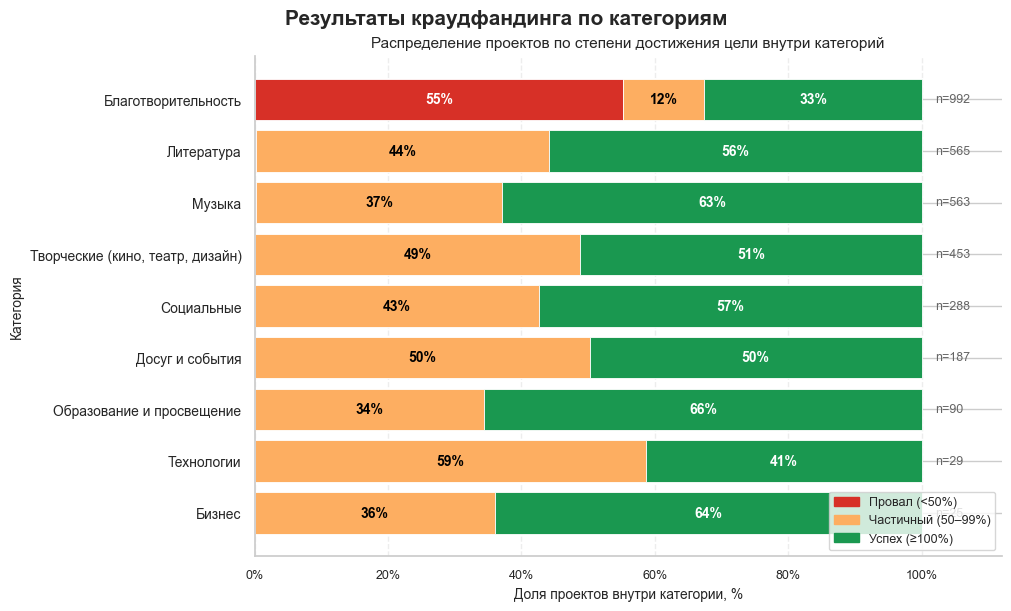

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 0. Восстановить категорию из дамми
#    Благотворительность = базовая категория
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

cat_cols = sorted([c for c in df_fit.columns if c.startswith("cat_")])

def assign_category(row):
    for col in cat_cols:
        if row[col] == 1:
            return col.replace("cat_", "")
    return "Благотворительность"

df_vis = df_fit.copy()
df_vis["category"] = df_vis.apply(assign_category, axis=1)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 1. Сводная таблица: абсолюты и доли
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

TARGET_COL = "funding_bucket"

ct = (
    pd.crosstab(df_vis["category"], df_vis[TARGET_COL])
    .reindex(columns=[0, 1, 2], fill_value=0)
)

ct["total"] = ct.sum(axis=1)

# Доли внутри каждой категории, в процентах
ct_share = ct[[0, 1, 2]].div(ct["total"], axis=0) * 100
ct_share["total"] = ct["total"]

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 2. Параметры
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

BUCKETS = [0, 1, 2]

COLORS = [
    "#d73027",  # провал
    "#fdae61",  # частичный
    "#1a9850"   # успех
]

TXT_COLORS = [
    "white",
    "black",
    "white"
]

LABELS_LEG = [
    "Провал (<50%)",
    "Частичный (50–99%)",
    "Успех (≥100%)"
]

# Сортировка по числу проектов
order_n = ct["total"].sort_values(ascending=True).index

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 3. Функция рисования stacked horizontal bar chart с долями
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def stacked_hbar_share(ax, share_data, count_data, order):
    left = np.zeros(len(order))

    for bkt, color, tcol in zip(BUCKETS, COLORS, TXT_COLORS):
        vals = share_data.loc[order, bkt].values

        ax.barh(
            np.arange(len(order)),
            vals,
            left=left,
            color=color,
            edgecolor="white",
            linewidth=0.6,
            zorder=2
        )

        # Подписи внутри сегментов: доли, а не абсолюты
        for j, (v, l) in enumerate(zip(vals, left)):
            if v >= 6:  # чтобы подписи не налезали на очень маленьких сегментах
                ax.text(
                    l + v / 2,
                    j,
                    f"{v:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color=tcol,
                    fontweight="bold",
                    zorder=3
                )

        left += vals

    # Подпись n= справа
    for j, cat in enumerate(order):
        ax.text(
            102,
            j,
            f'n={int(count_data.loc[cat, "total"])}',
            va="center",
            fontsize=9,
            color="#666666"
        )

    ax.set_yticks(np.arange(len(order)))
    ax.set_yticklabels(order, fontsize=10)

    ax.spines[["top", "right"]].set_visible(False)
    ax.xaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
    ax.set_axisbelow(True)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 4. Рисунок — один график
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

fig.suptitle(
    "Результаты краудфандинга по категориям",
    fontsize=15,
    fontweight="bold"
)

stacked_hbar_share(ax, ct_share, ct, order_n)

ax.set_title(
    "Распределение проектов по степени достижения цели внутри категорий",
    fontsize=11
)

ax.set_xlabel("Доля проектов внутри категории, %", fontsize=10)
ax.set_ylabel("Категория", fontsize=10)

ax.set_xlim(0, 112)

# Подписи оси X в процентах
ax.set_xticks(np.arange(0, 101, 20))
ax.set_xticklabels([f"{x}%" for x in np.arange(0, 101, 20)], fontsize=9)

# Легенда
patches = [
    mpatches.Patch(color=c, label=l)
    for c, l in zip(COLORS, LABELS_LEG)
]

ax.legend(
    handles=patches,
    loc="lower right",
    frameon=True,
    fontsize=9
)

plt.savefig(
    "funding_by_category.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

Процент успеха по категориям:
Образование и просвещение: 65.6%
Бизнес: 64.0%
Музыка: 62.9%
Социальные: 57.3%
Литература: 55.9%
Творческие (кино, театр, дизайн): 51.2%
Досуг и события: 49.7%
Технологии: 41.4%
Благотворительность: 32.6%


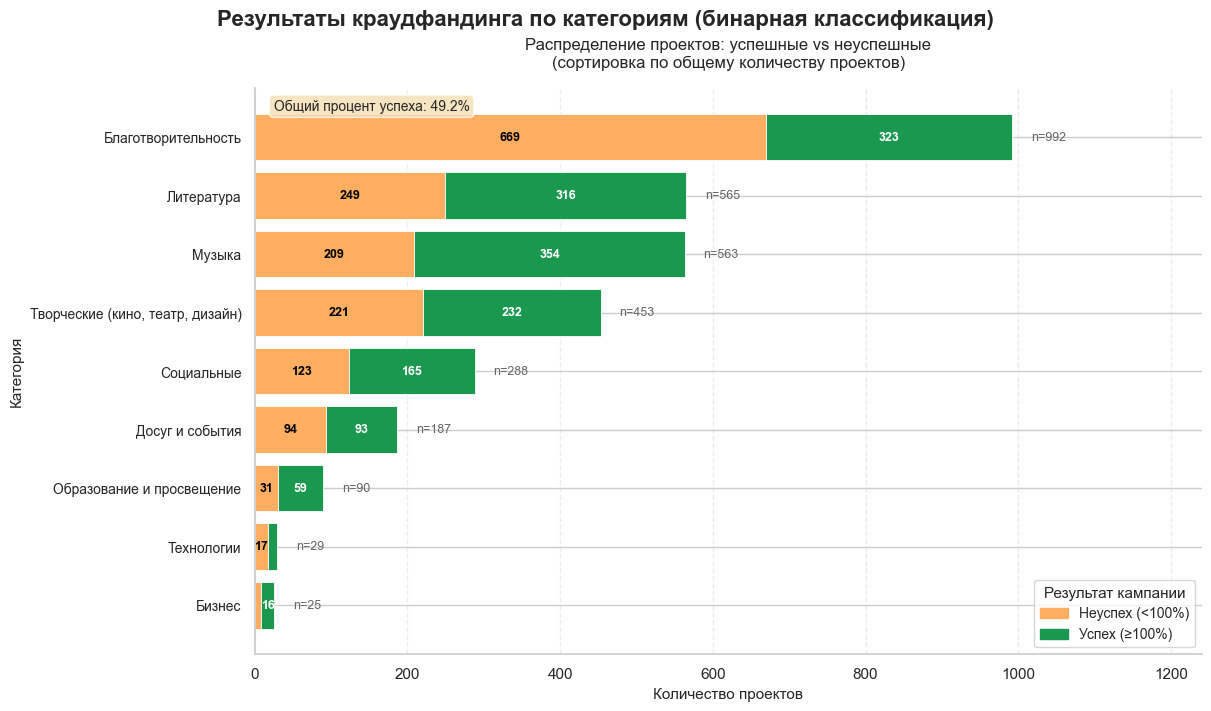


Детальная статистика по категориям:
                                  Всего проектов  Успешных  Неуспешных  % успеха
category                                                                        
Образование и просвещение                     90        59          31      65.6
Бизнес                                        25        16           9      64.0
Музыка                                       563       354         209      62.9
Социальные                                   288       165         123      57.3
Литература                                   565       316         249      55.9
Творческие (кино, театр, дизайн)             453       232         221      51.2
Досуг и события                              187        93          94      49.7
Технологии                                    29        12          17      41.4
Благотворительность                          992       323         669      32.6


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 0. Восстановить категорию из дамми
#    Благотворительность = базовая категория
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

cat_cols = sorted([c for c in df_fit.columns if c.startswith("cat_")])

def assign_category(row):
    for col in cat_cols:
        if row[col] == 1:
            return col.replace("cat_", "")
    return "Благотворительность"

df_vis = df_fit.copy()
df_vis["category"] = df_vis.apply(assign_category, axis=1)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 1. Создать бинарную целевую переменную (до 1 и больше 1)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Используем исходные данные о сборах
df_vis["funding_ratio"] = (
    df_vis["card.collectedAmount.value"] / df_vis["card.targetAmount.value"]
)

# Создаем бинарную переменную: 0 = до 1 (неуспех), 1 = больше 1 (успех)
df_vis["success_binary"] = np.where(df_vis["funding_ratio"] >= 1, 1, 0)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 2. Сводная таблица для двух классов
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

TARGET_COL = "success_binary"

ct = (
    pd.crosstab(df_vis["category"], df_vis[TARGET_COL])
    .reindex(columns=[0, 1], fill_value=0)
)

ct["total"] = ct.sum(axis=1)

# Переименовываем колонки для ясности
ct = ct.rename(columns={0: "Неуспех (<100%)", 1: "Успех (≥100%)"})

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 3. Параметры для двух классов
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

BUCKETS = ["Неуспех (<100%)", "Успех (≥100%)"]

COLORS = [
    "#fdae61",  # оранжевый - неуспех
    "#1a9850"   # зеленый - успех
]

TXT_COLORS = [
    "black",    # текст на оранжевом
    "white"     # текст на зеленом
]

LABELS_LEG = [
    "Неуспех (<100%)",
    "Успех (≥100%)"
]

# Сортировка по числу проектов (по возрастанию)
order_n = ct["total"].sort_values(ascending=True).index

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 4. Функция рисования stacked horizontal bar chart
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def stacked_hbar_binary(ax, data, order):
    left = np.zeros(len(order))

    for i, (bkt, color, tcol) in enumerate(zip(BUCKETS, COLORS, TXT_COLORS)):
        vals = data.loc[order, bkt].values

        ax.barh(
            np.arange(len(order)),
            vals,
            left=left,
            color=color,
            edgecolor="white",
            linewidth=0.6,
            zorder=2
        )

        # Подписи внутри сегментов (только если достаточно места)
        for j, (v, l) in enumerate(zip(vals, left)):
            if v > 15:  # Порог для отображения текста
                ax.text(
                    l + v / 2,
                    j,
                    f"{v:.0f}",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color=tcol,
                    fontweight="bold",
                    zorder=3
                )

        left += vals

    # Подпись n= справа
    x_offset = data["total"].max() * 0.025

    for j, cat in enumerate(order):
        x_end = data.loc[cat, "total"]

        ax.text(
            x_end + x_offset,
            j,
            f'n={int(data.loc[cat, "total"])}',
            va="center",
            fontsize=9,
            color="#666666"
        )

    ax.set_yticks(np.arange(len(order)))
    ax.set_yticklabels(order, fontsize=10)

    ax.spines[["top", "right"]].set_visible(False)
    ax.xaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
    ax.set_axisbelow(True)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 5. Дополнительная статистика для аннотаций
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Расчет процента успеха по категориям
ct_pct = ct[BUCKETS].div(ct["total"], axis=0) * 100
success_rates = ct_pct["Успех (≥100%)"].sort_values(ascending=False)

print("Процент успеха по категориям:")
for category, rate in success_rates.items():
    print(f"{category}: {rate:.1f}%")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 6. Рисунок — график для двух классов
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

fig.suptitle(
    "Результаты краудфандинга по категориям (бинарная классификация)",
    fontsize=16,
    fontweight="bold"
)

stacked_hbar_binary(ax, ct, order_n)

ax.set_title(
    "Распределение проектов: успешные vs неуспешные\n(сортировка по общему количеству проектов)",
    fontsize=12,
    pad=15
)

ax.set_xlabel("Количество проектов", fontsize=11)
ax.set_ylabel("Категория", fontsize=11)

ax.set_xlim(0, ct["total"].max() * 1.25)

# Легенда
patches = [
    mpatches.Patch(color=c, label=l)
    for c, l in zip(COLORS, LABELS_LEG)
]

ax.legend(
    handles=patches,
    loc="lower right",
    frameon=True,
    fontsize=10,
    title="Результат кампании",
    title_fontsize=11
)

# Добавляем аннотацию с общей статистикой
total_success_rate = (ct["Успех (≥100%)"].sum() / ct["total"].sum() * 100)
ax.text(
    0.02, 0.98,
    f"Общий процент успеха: {total_success_rate:.1f}%",
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
)

plt.savefig(
    "funding_by_category_binary.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 7. Дополнительно: таблица с процентами успеха
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n" + "="*60)
print("Детальная статистика по категориям:")
print("="*60)

stats_table = pd.DataFrame({
    'Всего проектов': ct['total'],
    'Успешных': ct['Успех (≥100%)'],
    'Неуспешных': ct['Неуспех (<100%)'],
    '% успеха': (ct['Успех (≥100%)'] / ct['total'] * 100).round(1)
}).sort_values('% успеха', ascending=False)

print(stats_table)


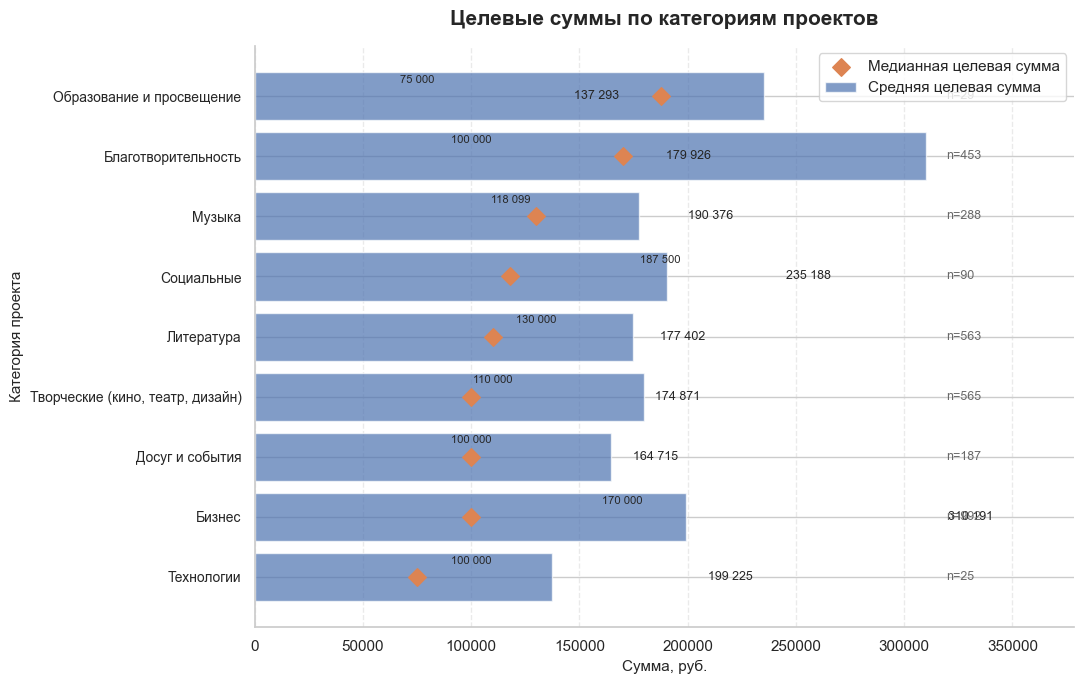

,Категория,Средняя целевая сумма,Медианная целевая сумма,Количество проектов
8,Технологии,137293.103448,75000.0,29
0,Бизнес,199225.480000,100000.0,25
2,Досуг и события,164715.877005,100000.0,187
7,"Творческие (кино, театр, дизайн)",179926.869757,100000.0,453
3,Литература,174871.024779,110000.0,565
6,Социальные,190376.489583,118099.0,288
4,Музыка,177402.300178,130000.0,563
1,Благотворительность,310191.143145,170000.0,992
5,Образование и просвещение,235188.900000,187500.0,90


In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 0. Восстановить категорию из дамми
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

cat_cols = sorted([c for c in df_fit.columns if c.startswith("cat_")])

def assign_category(row):
    for col in cat_cols:
        if row[col] == 1:
            return col.replace("cat_", "")
    return "Благотворительность"

df_goal_plot = df_fit.copy()
df_goal_plot["category"] = df_goal_plot.apply(assign_category, axis=1)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 1. Проверка переменной
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

GOAL_COL = "card.targetAmount.value"

if GOAL_COL not in df_goal_plot.columns:
    raise ValueError(f"{GOAL_COL} не найдена")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 2. Агрегация
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

goal_stats = (
    df_goal_plot
    .groupby("category")
    .agg(
        mean_goal=(GOAL_COL, "mean"),
        median_goal=(GOAL_COL, "median"),
        n_projects=(GOAL_COL, "count")
    )
    .reset_index()
)

goal_stats = goal_stats.sort_values(
    "median_goal",
    ascending=True
)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 3. График
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

fig, ax = plt.subplots(figsize=(11, 7))

y = np.arange(len(goal_stats))

# Средние
ax.barh(
    y,
    goal_stats["mean_goal"],
    alpha=0.7,
    label="Средняя целевая сумма"
)

# Медианы
ax.scatter(
    goal_stats["median_goal"],
    y,
    s=80,
    marker="D",
    label="Медианная целевая сумма",
    zorder=3
)

# Подписи категорий
ax.set_yticks(y)
ax.set_yticklabels(goal_stats["category"], fontsize=10)

# Подписи значений
for i, row in goal_stats.iterrows():

    ax.text(
        row["mean_goal"] + 10000,
        i,
        f'{int(row["mean_goal"]):,}'.replace(",", " "),
        va="center",
        fontsize=9
    )

    ax.text(
        row["median_goal"],
        i + 0.22,
        f'{int(row["median_goal"]):,}'.replace(",", " "),
        ha="center",
        fontsize=8
    )

# Оформление
ax.set_title(
    "Целевые суммы по категориям проектов",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Сумма, руб.", fontsize=11)
ax.set_ylabel("Категория проекта", fontsize=11)

ax.xaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Легенда
ax.legend(frameon=True)

# n справа
xmax = goal_stats["mean_goal"].max()

for i, row in goal_stats.iterrows():
    ax.text(
        xmax * 1.03,
        i,
        f'n={row["n_projects"]}',
        va="center",
        fontsize=9,
        color="dimgray"
    )

ax.set_xlim(0, xmax * 1.22)

plt.tight_layout()

plt.savefig(
    "goal_amounts_by_category.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 4. Таблица
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

goal_stats_table = goal_stats.rename(columns={
    "category": "Категория",
    "mean_goal": "Средняя целевая сумма",
    "median_goal": "Медианная целевая сумма",
    "n_projects": "Количество проектов"
})

display(goal_stats_table)

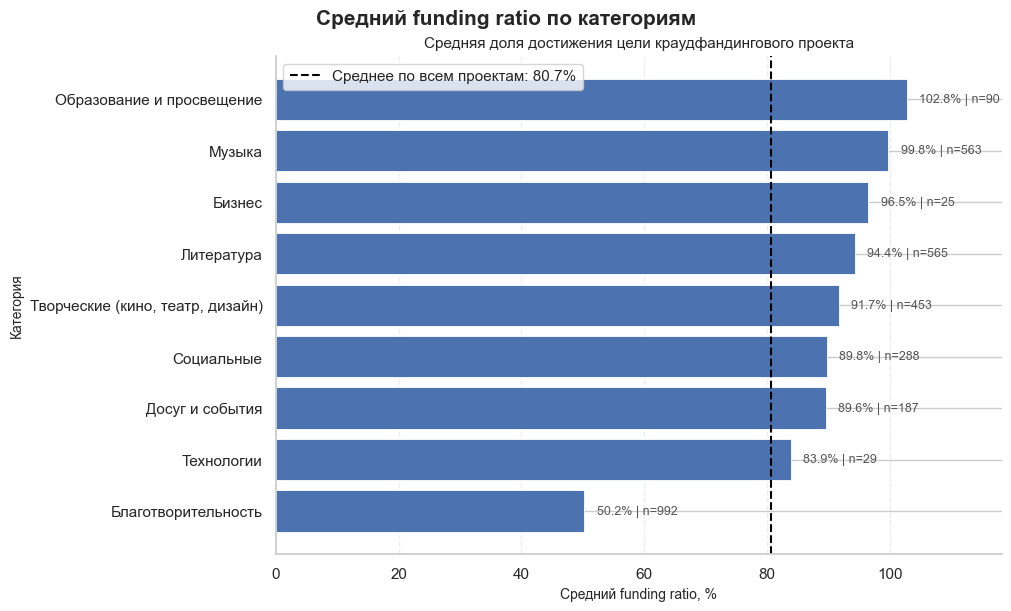

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 0. Восстановить категорию из дамми
#    Благотворительность = базовая категория
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

cat_cols = sorted([c for c in df_fit.columns if c.startswith("cat_")])

def assign_category(row):
    for col in cat_cols:
        if row[col] == 1:
            return col.replace("cat_", "")
    return "Благотворительность"

df_vis = df_fit.copy()
df_vis["category"] = df_vis.apply(assign_category, axis=1)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 1. Средний funding_ratio по категориям
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

summary = (
    df_vis
    .groupby("category", as_index=False)
    .agg(
        mean_funding_ratio=("funding_ratio", "mean"),
        n_projects=("funding_ratio", "count")
    )
)

# Сортировка по среднему funding_ratio
summary = summary.sort_values("mean_funding_ratio", ascending=True)

# Для отображения в процентах, если funding_ratio хранится как 0.75 = 75%
summary["mean_funding_ratio_pct"] = summary["mean_funding_ratio"] * 100

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 2. График
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

bars = ax.barh(
    summary["category"],
    summary["mean_funding_ratio_pct"],
    edgecolor="white",
    linewidth=0.6
)

# Подписи значений и количества проектов
for bar, mean_val, n in zip(
    bars,
    summary["mean_funding_ratio_pct"],
    summary["n_projects"]
):
    ax.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height() / 2,
        f"{mean_val:.1f}% | n={n}",
        va="center",
        fontsize=9,
        color="#555555"
    )

fig.suptitle(
    "Средний funding ratio по категориям",
    fontsize=15,
    fontweight="bold"
)

ax.set_title(
    "Средняя доля достижения цели краудфандингового проекта",
    fontsize=11
)

overall_mean = df_fit["funding_ratio"].mean() * 100

ax.axvline(
    overall_mean,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Среднее по всем проектам: {overall_mean:.1f}%"
)

ax.legend()

ax.set_xlabel("Средний funding ratio, %", fontsize=10)
ax.set_ylabel("Категория", fontsize=10)

ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.grid(True, linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

# Чтобы подписи справа не обрезались
ax.set_xlim(0, summary["mean_funding_ratio_pct"].max() * 1.15)

plt.savefig(
    "mean_funding_ratio_by_category.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()